# Import Packages and Load Variables

In [183]:
import uproot
print("uproot version: ", uproot.__version__)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import pickle
from collections import Counter
from particle import Particle

import awkward as ak

f = uproot.open('/Users/katherinepulido/Desktop/SURPRISE_Test_Samples_v10_04_07_05_Run4b_hyper_unified_reco2_BNB_nu_NC_pi0_overlay_may8_reco2_hist_62280465_snapshot.root')
fdirt = uproot.open('/Users/katherinepulido/Downloads/SURPRISE_Test_Samples_v10_04_07_05_Run4b_hyper_unified_reco2_BNB_dirt_may8_reco2_hist_62280564_snapshot.root')
fnu = uproot.open('/Users/katherinepulido/Downloads/SURPRISE_Test_Samples_v10_04_07_05_Run4b_super_unified_reco2_BNB_nu_overlay_reco2_hist.root')

uproot version:  5.6.2


## Load Variables

In [184]:

T_bdt_vars = ['cosmict_flag']           # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
    
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    "nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(f["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(f["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(f["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(f["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(f["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(f["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))
vars.update(f["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))

file_POT = np.sum(f["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])
for col in vars:
    vars[col] = vars[col].tolist()
wc_df = pd.DataFrame(vars)

In [185]:
T_bdt_vars = []              # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',    
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    "nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

# CRT and light variables

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))

vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(fdirt["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
file_POT = np.sum(fdirt["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])

for col in vars:
    vars[col] = vars[col].tolist()
dirt_df = pd.DataFrame(vars)


In [186]:
T_bdt_vars = []              # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    #"nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

# CRT and light variables

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(fnu["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(fnu["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(fnu["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(fnu["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))

#vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(fnu["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(fnu["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))
vars.update(fnu["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))
#vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
file_POT = np.sum(fnu["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])

for col in vars:
    vars[col] = vars[col].tolist()
nu_df = pd.DataFrame(vars)


## Post processing all files

In [187]:
# lee's code unedited

import sys
import uproot
import numpy as np
from tqdm import tqdm
import pickle
import argparse
import pandas as pd

#from helpers.plotting_3d import generate_box_edge_points, plot_event
#from helpers.spacepoint_sampling import fps_clustering_downsample, get_min_dists, energy_weighted_density_sampling


def get_vtx_and_true_gamma_info(f, num_events):
    # loads non-spacepoint information from the root file, including RSE, true nu vtx, reco nu vtx, and true gamma info

    print("getting true gamma information")

    rse = f["wcpselection"]["T_eval"].arrays(["run", "subrun", "event"], library="np", entry_start=0, entry_stop=num_events)
    true_nu_vtx = f["wcpselection"]["T_eval"].arrays(["truth_vtxX", "truth_vtxY", "truth_vtxZ"], library="np", entry_start=0, entry_stop=num_events)
    true_nu_vtx = np.stack([true_nu_vtx["truth_vtxX"], true_nu_vtx["truth_vtxY"], true_nu_vtx["truth_vtxZ"]], axis=-1)
    reco_nu_vtx = f["wcpselection"]["T_PFeval"].arrays(["reco_nuvtxX", "reco_nuvtxY", "reco_nuvtxZ"], library="np", entry_start=0, entry_stop=num_events)
    reco_nu_vtx = np.stack([reco_nu_vtx["reco_nuvtxX"], reco_nu_vtx["reco_nuvtxY"], reco_nu_vtx["reco_nuvtxZ"]], axis=-1)

    true_gamma_info_df = pd.DataFrame({
        "run": rse["run"],
        "subrun": rse["subrun"],
        "event": rse["event"],
        "true_nu_vtx_x": true_nu_vtx[:, 0],
        "true_nu_vtx_y": true_nu_vtx[:, 1],
        "true_nu_vtx_z": true_nu_vtx[:, 2],
        "reco_nu_vtx_x": reco_nu_vtx[:, 0],
        "reco_nu_vtx_y": reco_nu_vtx[:, 1],
        "reco_nu_vtx_z": reco_nu_vtx[:, 2],
    })

    # these variables will be used to define signal vs background
    # only includes gammas from a pi0 (primary or non-primary)
    true_num_gamma = []
    true_gamma_energies = []
    true_gamma_pairconversion_xs = []
    true_gamma_pairconversion_ys = []
    true_gamma_pairconversion_zs = []
    
    true_gamma_pairconversion_pxs = []
    true_gamma_pairconversion_pys = []
    true_gamma_pairconversion_pzs = []
    true_gamma_pairconversion_engys = []
    
    true_num_gamma_pairconvert = []
    true_num_gamma_pairconvert_in_FV = []
    true_num_gamma_pairconvert_in_FV_20_MeV = []
    true_momentum_of_original = []
    pi0_inside = np.full(num_events, True, dtype=bool)

    wc_geant_dic = f["wcpselection"]["T_PFeval"].arrays(["truth_id", "truth_mother", "truth_pdg", "truth_startMomentum", "truth_startXYZT", "truth_endXYZT"], library="np")

    for event_i in tqdm(range(num_events)):
        
        num_particles = len(wc_geant_dic["truth_id"][event_i])
                
        curr_true_num_gamma = 0
        curr_true_gamma_energies = []
        curr_true_gamma_pairconversion_xs = []
        curr_true_gamma_pairconversion_ys = []
        curr_true_gamma_pairconversion_zs = []
        
        curr_true_gamma_pairconversion_pxs = []
        curr_true_gamma_pairconversion_pys = []
        curr_true_gamma_pairconversion_pzs = []
        curr_true_gamma_pairconversion_engys = []
        
        curr_original_momentum = []
        curr_true_num_gamma_pairconvert = 0
        curr_true_num_gamma_pairconvert_in_FV = 0
        curr_true_num_gamma_pairconvert_in_FV_20_MeV = 0

        pi0_ids = []
        for i in range(num_particles):
            if wc_geant_dic["truth_pdg"][event_i][i] == 111:
                pi0_ids.append(wc_geant_dic["truth_id"][event_i][i])
                pi0x, pi0y, pi0z, _ = wc_geant_dic["truth_startXYZT"][event_i][i]
                if not (-1.0 <= pi0x <= 254.3 and -115.0 <= pi0y <= 117.0 and 0.6 <= pi0z <= 1036.4):
                    pi0_inside[event_i] = False
                

        primary_or_pi0_gamma_ids = []
        for i in range(num_particles):
            if wc_geant_dic["truth_mother"][event_i][i] in pi0_ids or wc_geant_dic["truth_mother"][event_i][i] == 0: # this is a daughter of a pi0 or a primary gamma (most likely from an eta or Delta radiative)
                if wc_geant_dic["truth_pdg"][event_i][i] == 22: # this is a gamma from a pi0
                    curr_true_num_gamma += 1
                    curr_true_gamma_energies.append(wc_geant_dic["truth_startMomentum"][event_i][i][3])
                    curr_original_momentum.append([wc_geant_dic["truth_startMomentum"][event_i][i][0], wc_geant_dic["truth_startMomentum"][event_i][i][1], wc_geant_dic["truth_startMomentum"][event_i][i][2]])
                    primary_or_pi0_gamma_ids.append(wc_geant_dic["truth_id"][event_i][i])


        # looking for the first point where the photon transfers more than half its energy to daughter charged particles
        # should be 100% for pair production, but compton scatters can also effectively cause the start of a shower
        # daughter particles could disappear from the geant tree even if it pair converts, that type of photon won't be included here

        # looking for pair conversion points, allowing for the possibility of Compton scattering
        for i in range(num_particles):
            if wc_geant_dic["truth_id"][event_i][i] in primary_or_pi0_gamma_ids: # pi0/primary -> gamma

                original_gamma_energy = wc_geant_dic["truth_startMomentum"][event_i][i][3]
                px = wc_geant_dic["truth_startMomentum"][event_i][i][0]
                py = wc_geant_dic["truth_startMomentum"][event_i][i][1]
                pz = wc_geant_dic["truth_startMomentum"][event_i][i][2]
                cumulative_deposited_energy = 0
                curr_id = wc_geant_dic["truth_id"][event_i][i]
                # loop until we deposit enough charged energy, or run out of daughters
                loop_counter = 0
                while True:
                    loop_counter += 1
                    if loop_counter > 100:
                        print(f"infinite loop detected in event {event_i}")
                        break

                    
                    descendants_ids = []
                    descendants_indices = []
                    descendants_pdgs = []
                    for j in range(num_particles):
                        if wc_geant_dic["truth_mother"][event_i][j] == curr_id: # pi0/primary -> gamma -> this particle
                            descendants_ids.append(wc_geant_dic["truth_id"][event_i][j])
                            descendants_indices.append(j)
                            descendants_pdgs.append(wc_geant_dic["truth_pdg"][event_i][j])

                    for descendant_i in range(len(descendants_indices)):
                        if abs(descendants_pdgs[descendant_i]) == 11: # electron/positron daughter
                            cumulative_deposited_energy += wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[descendant_i]][3]

                    if cumulative_deposited_energy > original_gamma_energy / 2: # it has deposited enough energy to effectively count as a pair conversion
                        break

                    if 22 in descendants_pdgs: # found a compton scatter, hasn't deposited enough energy yet, loop to consider that next photon
                        curr_id = descendants_ids[descendants_pdgs.index(22)]
                        #print("doing a compton scatter")
                    else: # no compton scatter, we're done, it's either a pair conversion or photoelectric absorption or a Geant tree deletion
                        break

                if cumulative_deposited_energy < original_gamma_energy / 2: # weird event, didn't deposit enough energy to count as a pair conversion
                    #print(f"weird event, no daughter photon, but also deposited less than half the energy: {cumulative_deposited_energy} / {original_gamma_energy}, {count}")
                    pass
                else:
                    curr_true_gamma_pairconversion_xs.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][0])
                    curr_true_gamma_pairconversion_ys.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][1])
                    curr_true_gamma_pairconversion_zs.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][2])
                    
                    curr_true_gamma_pairconversion_pxs.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][0])
                    curr_true_gamma_pairconversion_pys.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][1])
                    curr_true_gamma_pairconversion_pzs.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][2])
                    curr_true_gamma_pairconversion_engys.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][3])
                    
                    
                    
                    curr_true_num_gamma_pairconvert += 1

                    if -1 < curr_true_gamma_pairconversion_xs[-1] <= 254.3 and -115.0 < curr_true_gamma_pairconversion_ys[-1] <= 117.0 and 0.6 < curr_true_gamma_pairconversion_zs[-1] <= 1036.4:
                        curr_true_num_gamma_pairconvert_in_FV += 1

                        if original_gamma_energy > 0.02:
                            curr_true_num_gamma_pairconvert_in_FV_20_MeV += 1


        true_num_gamma.append(curr_true_num_gamma)
        true_gamma_energies.append(curr_true_gamma_energies)
        true_gamma_pairconversion_xs.append(curr_true_gamma_pairconversion_xs)
        true_gamma_pairconversion_ys.append(curr_true_gamma_pairconversion_ys)
        true_gamma_pairconversion_zs.append(curr_true_gamma_pairconversion_zs)
        
        true_gamma_pairconversion_pxs.append(curr_true_gamma_pairconversion_pxs)
        true_gamma_pairconversion_pys.append(curr_true_gamma_pairconversion_pys)
        true_gamma_pairconversion_pzs.append(curr_true_gamma_pairconversion_pzs)
        true_gamma_pairconversion_engys.append(curr_true_gamma_pairconversion_engys)
        
        
        true_num_gamma_pairconvert.append(curr_true_num_gamma_pairconvert)
        true_num_gamma_pairconvert_in_FV.append(curr_true_num_gamma_pairconvert_in_FV)
        true_num_gamma_pairconvert_in_FV_20_MeV.append(curr_true_num_gamma_pairconvert_in_FV_20_MeV)
        
        true_momentum_of_original.append(curr_original_momentum)

    true_gamma_info_df["true_num_gamma"] = true_num_gamma
    true_gamma_info_df["true_gamma_energies"] = true_gamma_energies
    true_gamma_info_df["true_gamma_pairconversion_xs"] = true_gamma_pairconversion_xs
    true_gamma_info_df["true_gamma_pairconversion_ys"] = true_gamma_pairconversion_ys
    true_gamma_info_df["true_gamma_pairconversion_zs"] = true_gamma_pairconversion_zs
    
    true_gamma_info_df["true_gamma_pairconversion_pxs"] = true_gamma_pairconversion_pxs
    true_gamma_info_df["true_gamma_pairconversion_pys"] = true_gamma_pairconversion_pys
    true_gamma_info_df["true_gamma_pairconversion_pzs"] = true_gamma_pairconversion_pzs
    true_gamma_info_df["true_gamma_pairconversion_engys"] = true_gamma_pairconversion_engys
    
    true_gamma_info_df["true_num_gamma_pairconvert"] = true_num_gamma_pairconvert
    true_gamma_info_df["true_num_gamma_pairconvert_in_FV"] = true_num_gamma_pairconvert_in_FV
    true_gamma_info_df["true_num_gamma_pairconvert_in_FV_20_MeV"] = true_num_gamma_pairconvert_in_FV_20_MeV
    
    true_gamma_info_df['pi0_inside'] = pi0_inside
    
    true_gamma_info_df["true_momentum_of_original"] = true_momentum_of_original

    # returning the vertex information separately, since that will be used for downsampling
    return true_nu_vtx, reco_nu_vtx, true_gamma_info_df


true_nu_vtx, reco_nu_vtx, true_gamma_info_df = get_vtx_and_true_gamma_info(f, wc_df.shape[0])
_, _, true_gamma_dirt_df = get_vtx_and_true_gamma_info(fdirt, dirt_df.shape[0])
_, _, true_gamma_nu_df = get_vtx_and_true_gamma_info(fnu, nu_df.shape[0])


#true_gamma_all_df = pd.concat([true_gamma_dirt_df, true_gamma_nu_df], axis=0, ignore_index=True)

getting true gamma information


100%|██████████| 43212/43212 [00:02<00:00, 20831.74it/s]


getting true gamma information


100%|██████████| 45159/45159 [00:00<00:00, 54052.00it/s] 


getting true gamma information


100%|██████████| 99680/99680 [00:02<00:00, 45634.44it/s]


In [188]:

def do_meas_minus_pred(all_df):
    
    meas_pmt_array = all_df['flash_measPe'].to_numpy()
    pred_pmt_array = all_df["flash_predPe"].to_numpy()
    
   # pmt_amp = all_df['PMT_Amp'].to_numpy()
    # old definition
    
    meas_pmt = all_df['flash_pe_flash_matching_v'].to_numpy()
    pred_pmt = all_df['slice_pe_flash_matching_v'].to_numpy()

    measured_total_wc = np.zeros(all_df.shape[0])
    pred_total_wc = np.zeros(all_df.shape[0])

    measured_total_pandora = np.zeros(all_df.shape[0])
    pred_total_pandora = np.zeros(all_df.shape[0])

    #pmtamp_total = np.zeros(all_df.shape[0])
    
    threshold_total_wc = np.zeros(all_df.shape[0])
    threshold_total_pred_wc = np.zeros(all_df.shape[0])
    
    threshold_total_pandora = np.zeros(all_df.shape[0])
    threshold_total_pred_pandora = np.zeros(all_df.shape[0])
    
    for event_i in range(all_df.shape[0]):
        measured_total_wc[event_i] = np.sum(meas_pmt_array[event_i])
        pred_total_wc[event_i] = np.sum(pred_pmt_array[event_i])
        
        # sum just values above 2.5
        threshold_total_wc[event_i] = np.sum(meas_pmt_array[event_i][meas_pmt_array[event_i] > 2.5])
        threshold_total_pred_wc[event_i] = np.sum(pred_pmt_array[event_i][pred_pmt_array[event_i] > 2.5])
        
        #pmtamp_total[event_i] = np.sum(pmt_amp[event_i])
    
        measured_total_pandora[event_i] = np.sum(meas_pmt[event_i])
        pred_total_pandora[event_i] = np.sum(pred_pmt[event_i])  
        
        threshold_total_pandora[event_i] = np.sum(meas_pmt[event_i][meas_pmt[event_i] > 2.5])
        threshold_total_pred_pandora[event_i] = np.sum(pred_pmt[event_i][pred_pmt[event_i] > 2.5])
        
        
        #measured_total[event_i] = meas_pmt[event_i]
        #pred_total[event_i] = pred_pmt[event_i]
        
    all_df['meas_total_wc'] = measured_total_wc
    all_df['pred_total_wc'] = pred_total_wc
    
    all_df['meas_total_pandora'] = measured_total_pandora
    all_df['pred_total_pandora'] = pred_total_pandora
    
    all_df['threshold_total_pandora'] = threshold_total_pandora
    all_df['threshold_total_wc'] = threshold_total_wc

    all_df['threshold_total_pred_wc'] = threshold_total_pred_wc
    all_df['threshold_total_pred_pandora'] = threshold_total_pred_pandora
    
    
    #all_df['pmtamp_total'] = pmtamp_total

    meas_minus_pred_arr_wc = np.zeros(all_df.shape[0])
    meas_minus_pred_arr_pandora = np.zeros(all_df.shape[0])
    
    #meas_over_pred_arr = np.zeros(all_df.shape[0])

    mask = pred_total_wc != 0
    meas_minus_pred_arr_wc[mask] = (measured_total_wc[mask] - pred_total_wc[mask]) / pred_total_wc[mask]
    
    mask = pred_total_pandora != 0
    meas_minus_pred_arr_pandora[mask] = (measured_total_pandora[mask] - pred_total_pandora[mask]) / pred_total_pandora[mask]

    #meas_over_pred_arr[mask] = measured_total[mask] / pred_total[mask]

    all_df['meas_minus_pred_wc'] = meas_minus_pred_arr_wc
    all_df['meas_minus_pred_pandora'] = meas_minus_pred_arr_pandora

    #all_df['meas_over_pred'] = meas_over_pred_arr
    
    return all_df

In [189]:
# flag raising

def raise_flags(true_gamma_df, info_df):
    
    info_df = do_meas_minus_pred(info_df)

    true_gamma_xs = true_gamma_df["true_gamma_pairconversion_xs"].to_numpy()
    true_gamma_ys = true_gamma_df["true_gamma_pairconversion_ys"].to_numpy()
    true_gamma_zs = true_gamma_df["true_gamma_pairconversion_zs"].to_numpy()

    true_gamma_pxs = true_gamma_df["true_gamma_pairconversion_pxs"].to_numpy()
    true_gamma_pys = true_gamma_df["true_gamma_pairconversion_pys"].to_numpy()
    true_gamma_pzs = true_gamma_df["true_gamma_pairconversion_pzs"].to_numpy()
    true_gamma_engys = true_gamma_df["true_gamma_pairconversion_engys"].to_numpy()

    true_gamma_energies = true_gamma_df["true_gamma_energies"].to_numpy()

    true_nu_xs = true_gamma_df['true_nu_vtx_x'].to_numpy()
    true_nu_ys = true_gamma_df['true_nu_vtx_y'].to_numpy()
    true_nu_zs = true_gamma_df['true_nu_vtx_z'].to_numpy()

    inside = 0
    outside = 0
    both = 0

    signal_flag = np.full(info_df.shape[0], False, dtype=bool)
    background_flag = np.full(info_df.shape[0], False, dtype=bool)
    pi0_flag = np.full(info_df.shape[0], False, dtype=bool)
    good_chg_reco = np.full(info_df.shape[0], False, dtype=bool)
    
    FC_missedshw = np.full(info_df.shape[0], False, dtype=bool)
    no_missed_shw_pi0 = np.full(info_df.shape[0], False, dtype=bool)
    
    one_outside_tpc = np.full(info_df.shape[0], False, dtype=bool)
    one_inside_tpc = np.full(info_df.shape[0], False, dtype=bool)
    
    missed_shw_close_to_pmt = np.full(info_df.shape[0], False, dtype=bool) 

    outside_tpc_shw_vtxX = np.ones(info_df.shape[0])
    outside_tpc_shw_vtxY = np.ones(info_df.shape[0])
    outside_tpc_shw_vtxZ = np.ones(info_df.shape[0])
    
    truth_pi0 = info_df["truth_NprimPio"].to_numpy()

    outside_tpc_shw_px = np.zeros(info_df.shape[0])
    outside_tpc_shw_py = np.zeros(info_df.shape[0])
    outside_tpc_shw_pz = np.zeros(info_df.shape[0])
    outside_tpc_shw_e = np.zeros(info_df.shape[0])

    truth_particle_vtx_e = info_df["truth_endXYZT"].to_numpy()
    truth_momentum = info_df["truth_startMomentum"].to_numpy()

    truth_ids = info_df["truth_id"].to_numpy()
    truth_pdgs = info_df["truth_pdg"].to_numpy()
    truth_mother = info_df["truth_mother"].to_numpy()

    enu = info_df["kine_reco_Enu"].to_numpy()
    e_inside = info_df['truth_energyInside'].to_numpy()
    
    is_FC = info_df["match_isFC"].to_numpy()


    for i in tqdm(range(info_df.shape[0])):
        
        if truth_pi0[i] > 0:
            pi0_flag[i] = True
        #elif info_df.all == wc_df.all:
            #print(f'truth_NprimPio = {truth_pi0[i]}, {i} = i')
            
        if .8 * e_inside[i] < enu[i] < 1.2 * e_inside[i]:
            good_chg_reco[i] = True
        
        index_distance_list_truth_s = []
        
        one_outside_tpc[i] = False
        one_inside_tpc[i] = False
        
        one_high_energy = False
        one_low_energy = False
        
        well_contained = False
        
        if enu[i] < 0:
            continue
        
        nu_x, nu_y, nu_z = true_nu_xs[i], true_nu_ys[i], true_nu_zs[i]
        
        if (29.0 <= nu_x <= 224.3 and -85 <= nu_y <= 87.0 and 30.6 <= nu_z <= 1006.4):
            well_contained = True
        
        if len(true_gamma_xs[i]) > 0 and len(true_gamma_ys[i]) > 0 and len(true_gamma_zs[i]) > 0:
            for particle in range(len(true_gamma_xs[i])):
                x, y, z = true_gamma_xs[i][particle], true_gamma_ys[i][particle], true_gamma_zs[i][particle]
                px, py, pz, engy = true_gamma_pxs[i][particle], true_gamma_pys[i][particle], true_gamma_pzs[i][particle], true_gamma_engys[i][particle]
                if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
                    one_outside_tpc[i] = True
                    outside_tpc_shw_vtxX[i] = x
                    outside_tpc_shw_vtxY[i] = y 
                    outside_tpc_shw_vtxZ[i] = z
                    outside_tpc_shw_px[i] = px
                    outside_tpc_shw_py[i] = py
                    outside_tpc_shw_pz[i] = pz
                    outside_tpc_shw_e[i] = engy
                    if -11.0 <= x <= 1.0:
                        missed_shw_close_to_pmt[i] = True
                        
                else:
                    one_inside_tpc[i] = True
                energy = true_gamma_energies[i][particle]
                if energy > .02:
                    one_high_energy = True
                if energy < .02: 
                    one_low_energy = True
        
        if one_outside_tpc[i]:
            outside += 1
        if one_inside_tpc[i]:
            inside += 1
        if one_outside_tpc[i] and one_inside_tpc[i]:
            both += 1
            background_flag[i] = True
            if is_FC[i]:
                FC_missedshw[i] = True
        
        #if one_high_energy and one_low_energy and not one_outside_tpc:
        if not one_outside_tpc[i] and pi0_flag[i]:
            no_missed_shw_pi0[i] = True
            if well_contained:
                signal_flag[i] = True
            


        #distance_particle_truth_end.append(index_distance_list_truth_e)

    print(f'signal percentage: {100 * np.sum(signal_flag)/info_df.shape[0]}')
    print(f'background percentage: {100 * np.sum(background_flag)/info_df.shape[0]}')


    print(np.sum(background_flag), np.sum(signal_flag))

    #info_df['signal_v1'] = signal_flag # signal_v1 should still be old definition of signal (one above 20mev, one below)
    #info_df['background_v1'] = background_flag

    info_df['signal_v2'] = signal_flag # v2 has at least 30cm of boundary and no lost shower
    info_df['background_v2'] = background_flag

    info_df['missed_photon_vtxX'] = outside_tpc_shw_vtxX
    info_df['missed_photon_vtxY'] = outside_tpc_shw_vtxY
    info_df['missed_photon_vtxZ'] = outside_tpc_shw_vtxZ
    
    info_df['missed_shw_close_to_pmt'] = missed_shw_close_to_pmt
    
    info_df['missed_photon_px'] = outside_tpc_shw_px
    info_df['missed_photon_py'] = outside_tpc_shw_py
    info_df['missed_photon_pz'] = outside_tpc_shw_pz
    info_df['missed_photon_e'] = outside_tpc_shw_e
    
    info_df['pi0_flag'] = pi0_flag
    info_df['good_chg_reco'] = good_chg_reco
    info_df['FC_missedshw'] = FC_missedshw
    info_df['no_missed_shw_pi0'] = no_missed_shw_pi0
    
    info_df['one_outside_tpc'] = one_outside_tpc
    info_df['one_inside_tpc'] = one_inside_tpc

    signal_df = info_df[info_df["signal_v2"] == True]
    background_df = info_df[info_df["background_v2"] == True]
    
    pi0_events_df = info_df[info_df['pi0_flag'] == True]

    missed_shw_events = background_df.index

    signal_and_bkgrnd_df = info_df.query("background_v2 == True or signal_v2 == True")
    
    return info_df, signal_df, background_df, missed_shw_events, signal_and_bkgrnd_df, pi0_events_df
    
pi0_df, pi0_signal, pi0_background, pi0_missed_shw, pi0_signal_and_backgound, pi0_pi0_df = raise_flags(true_gamma_info_df, wc_df)
dirt_df, dirt_signal, dirt_background, dirt_missed_shw, dirt_signal_and_background, dirt_pi0_df = raise_flags(true_gamma_dirt_df, dirt_df)
nu_df, nu_signal, nu_background, nu_missed_shw, nu_signal_and_background, nu_pi0_df = raise_flags(true_gamma_nu_df, nu_df)

print(f'dirt pi0 events: {dirt_pi0_df.shape}, pi0 overlay: {pi0_pi0_df.shape}, nu overlay: {nu_pi0_df.shape}')

print(f'dirt signal events: {dirt_signal.shape}, pi0 overlay: {pi0_signal.shape}, nu overlay: {nu_signal.shape}')

print(pi0_df.query("good_chg_reco == True").shape)



100%|██████████| 43212/43212 [00:00<00:00, 631458.11it/s]


signal percentage: 41.64352494677404
background percentage: 6.058502267888549
2618 17995


100%|██████████| 45159/45159 [00:00<00:00, 2515245.66it/s]


signal percentage: 0.0
background percentage: 0.022143980158993777
10 0


100%|██████████| 99680/99680 [00:00<00:00, 1535666.30it/s]


signal percentage: 2.8230337078651684
background percentage: 1.0202648475120386
1017 2814
dirt pi0 events: (0, 130), pi0 overlay: (42722, 131), nu overlay: (14013, 110)
dirt signal events: (0, 130), pi0 overlay: (17995, 131), nu overlay: (2814, 110)
(19007, 131)


## Misc Initializations

In [190]:
# dictionaries of pmt locations 

reco_position_dic = {
    0: [-11.6415, 55.313, 951.861],
    1: [-11.8345, 55.822, 911.065],
    2: [-11.4175, 27.607, 989.712],
    3: [-12.1765, -0.722, 865.599],
    4: [-11.4545, -28.625, 990.356],
    5: [-11.7755, -56.514, 951.865],
    6: [-12.0585, -56.309, 911.939],
    7: [-12.5405, 55.625, 751.884],
    8: [-12.6615, 55.8, 711.073],
    9: [-12.3045, -0.502, 796.208],
    10: [-12.6245, -0.051, 664.203],
    11: [-12.6045, -56.284, 751.905],
    12: [-12.6125, -56.408, 711.274],
    13: [-12.8735, 55.822, 540.929],
    14: [-12.9835, 55.771, 500.134],
    15: [-12.6515, -0.549, 585.284],
    16: [-12.6185, -0.875, 453.096],
    17: [-12.6205, -56.205, 540.616],
    18: [-12.5945, -56.323, 500.221],
    19: [-13.1865, 54.693, 328.212],
    20: [-13.4175, 54.646, 287.976],
    21: [-13.0855, -0.706, 373.839],
    22: [-13.1505, -0.829, 242.014],
    23: [-12.6485, -57.022, 328.341],
    24: [-13.0075, -56.261, 287.639],
    25: [-13.3965, 55.249, 128.354],
    26: [-13.5415, 55.249, 87.7605],
    27: [-13.4345, 27.431, 51.1015],
    28: [-13.4415, -0.303, 173.743],
    29: [-13.1525, -28.576, 50.4745],
    30: [-13.2784, -56.203, 128.18],
    31: [-13.2375, -56.615, 87.8695],
}

true_position_dic = {
    0: [-11.4545, -28.625, 990.356],
    1: [-11.4175, 27.607, 989.712],
    2: [-11.7755, -56.514, 951.865],
    3: [-11.6415, 55.313, 951.861],
    4: [-12.0585, -56.309, 911.939],
    5: [-11.8345, 55.822, 911.065],
    6: [-12.1765, -0.722, 865.599],
    7: [-12.3045, -0.502, 796.208],
    8: [-12.6045, -56.284, 751.905],
    9: [-12.5405, 55.625, 751.884],
    10: [-12.6125, -56.408, 711.274],
    11: [-12.6615, 55.8, 711.073],
    12: [-12.6245, -0.051, 664.203],
    13: [-12.6515, -0.549, 585.284],
    14: [-12.8735, 55.822, 540.929],
    15: [-12.6205, -56.205, 540.616],
    16: [-12.5945, -56.323, 500.221],
    17: [-12.9835, 55.771, 500.134],
    18: [-12.6185, -0.875, 453.096],
    19: [-13.0855, -0.706, 373.839],
    20: [-12.6485, -57.022, 328.341],
    21: [-13.1865, 54.693, 328.212],
    22: [-13.4175, 54.646, 287.976],
    23: [-13.0075, -56.261, 287.639],
    24: [-13.1505, -0.829, 242.014],
    25: [-13.4415, -0.303, 173.743],
    26: [-13.3965, 55.249, 128.354],
    27: [-13.2784, -56.203, 128.18],
    28: [-13.2375, -56.615, 87.8695],
    29: [-13.5415, 55.249, 87.7605],
    30: [-13.4345, 27.431, 51.1015],
    31: [-13.1525, -28.576, 50.4745],
}

## Unify dfs

In [191]:
all_df = pd.concat([pi0_df, dirt_df, nu_df], axis=0, ignore_index=True)
all_pi0_df = pd.concat([pi0_pi0_df, dirt_pi0_df, nu_pi0_df], axis=0, ignore_index=True)

true_gamma_df = pd.concat([true_gamma_info_df, true_gamma_dirt_df, true_gamma_nu_df], axis=0, ignore_index=True)

signal_df = pd.concat([pi0_signal, nu_signal], axis=0, ignore_index=True)
background_df = pd.concat([pi0_background, nu_background], axis=0, ignore_index=True)

# Define interesting PMT vars

list of bdt variables:

- [x] Nanosecond timing standard deviation (0, 1, 2, ..., 5 outliers discarded, and only +/- 5 nanoseconds from median)
- [x] Nanosecond timing latest minus earliest (0, 1, 2, ..., 5 outliers discarded, and only +/- 5 nanoseconds from median)
- [x] Nanosecond timing dipole (0, 1, 2, ..., 5 outliers discarded, and only +/- 5 nanoseconds from median)
- [x] Pandora and Wire-Cell total (meas-pred)/pred
- [x] Pandora and Wire-Cell total meas-pred
- [x] "net difference" (bottom panel), largest positive, largest negative (0, 1, 2, 3, 4 outliers discarded)
- [x] "net difference" num positive, num negative (0, 1, 2, 3, 4, 5 outliers discarded)
- [x] "net difference" sum positive, sum negative (0, 1, 2, 3, 4 outliers discarded)
- [x] "net difference" dipole
- [ ] Pandora meas mean x - pred mean x, same for y and (x, y) distance


In [192]:
# define distance between missed shower and inside shower

missed_shower_df = all_df.query('one_outside_tpc and one_inside_tpc')

# full bool list of missed shower events
missed_shw_distance = np.zeros(all_df.shape[0])  # initialize with zeros
for event in missed_shower_df.index:
    missed_shw_vtxX = missed_shower_df.loc[event, 'missed_photon_vtxX']
    missed_shw_vtxY = missed_shower_df.loc[event, 'missed_photon_vtxY']
    missed_shw_vtxZ = missed_shower_df.loc[event, 'missed_photon_vtxZ']
    
    # Get associated true gamma vertices for this event
    inside_shw_vtxX = true_gamma_df.loc[event, "true_gamma_pairconversion_xs"]
    inside_shw_vtxY = true_gamma_df.loc[event, "true_gamma_pairconversion_ys"]
    inside_shw_vtxZ = true_gamma_df.loc[event, "true_gamma_pairconversion_zs"]
    
    if len(inside_shw_vtxX) == 0:
        continue  # skip if no gammas

    distances = np.sqrt((missed_shw_vtxX - np.array(inside_shw_vtxX))**2 +
                        (missed_shw_vtxY - np.array(inside_shw_vtxY))**2 +
                        (missed_shw_vtxZ - np.array(inside_shw_vtxZ))**2)
    
    missed_shw_distance[event] = np.max(distances)

all_df['missed_shw_distance'] = missed_shw_distance

In [193]:
# ns timing bdt variables

pmt_time = all_df['PMT_Time'].to_numpy()
wc_ID_pmt_array = all_df['PMT_ID'].to_numpy()

pmts_within_ns = []
pmts_within_ns_std_dev = []
pmt_latest_minus_earliest = []

for event_times, event_pmts in zip(pmt_time, wc_ID_pmt_array):
    median = np.median(event_times)
    pmts_near_median_of_event = []
    pmt_times_near_median_of_event = []


    for pmt, pmt_id in zip(event_times, event_pmts):
        if abs(pmt - median) < 5:  # within +/-5 ns
            pmts_near_median_of_event.append(pmt_id)
            pmt_times_near_median_of_event.append(pmt - median)
            
    pmts_within_ns.append(pmts_near_median_of_event)
    if len(pmt_times_near_median_of_event) > 1:
        pmt_latest_minus_earliest.append(np.max(pmt_times_near_median_of_event) - np.min(pmt_times_near_median_of_event))
        pmts_within_ns_std_dev.append(np.std(pmt_times_near_median_of_event))
    else:
        pmt_latest_minus_earliest.append(np.nan)
        pmts_within_ns_std_dev.append(np.nan)
        


all_df['pmts_within_ns'] = pmts_within_ns

all_df['pmts_within_ns_std_dev'] = pmts_within_ns_std_dev
all_df['pmt_latest_minus_earliest'] = pmt_latest_minus_earliest



/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [194]:
# compute dipole -- one over distance to reco vertex times PE ?

pmt_time = all_df['PMT_Time'].to_numpy()
wc_ID_pmt_array = all_df['PMT_ID'].to_numpy()
wc_meas_pe_event = all_df['PMT_Amp'].to_numpy()

reco_vtxY = all_df['reco_nuvtxY'].to_numpy()
reco_vtxZ = all_df['reco_nuvtxZ'].to_numpy()
reco_vtxX = all_df['reco_nuvtxX'].to_numpy()

pmt_pe_vector_length = []
pmt_ns_vector_length = []

pmt_pe_3dvector_length = []

total_measuredPE = []

for event_times, event_pmts, event_pe, y_vtx, z_vtx, x_vtx in zip(pmt_time, wc_ID_pmt_array, wc_meas_pe_event, reco_vtxY, reco_vtxZ, reco_vtxX):
    
    median = np.median(event_times)
    
    pmts_near_median_of_event = []
    pmt_times_near_median_of_event = []
    pmt_pe_near_median_of_event = []
    
    total_measuredPE.append(sum(event_pe))
    
    pmt_pe_mean = np.mean(event_pe)
    
    event_y_pe = 0
    event_z_pe = 0
    event_x_pe = 0
    
    event_y_ns = 0
    event_z_ns = 0
    
    for time, id, pe in zip(event_times, event_pmts, event_pe):
        if abs(time - median) < 5:  # within +/-5 ns
            pmts_near_median_of_event.append(id)
            pmt_times_near_median_of_event.append(time - median)
            pmt_pe_near_median_of_event.append(pe)
                
        if id in true_position_dic:
            pos = true_position_dic[id]
        
        event_y_pe += (pe - pmt_pe_mean) * (pos[1] - y_vtx)
        event_z_pe += (pe - pmt_pe_mean) * (pos[2] - z_vtx)
        event_x_pe += (pe - pmt_pe_mean) * (pos[0] - x_vtx)

    pmt_pe_vector_length.append(np.sqrt(event_y_pe**2 + event_z_pe**2))
    #print(f'x: {event_x_pe} y: {event_y_pe} z: {event_z_pe}')
    #print(f'2d: {np.sqrt(event_y_pe**2 + event_z_pe**2)}, 3d: {np.sqrt(event_y_pe**2 + event_z_pe**2 + event_x_pe**2)}')
    pmt_pe_3dvector_length.append(np.sqrt(event_y_pe**2 + event_z_pe**2 + event_x_pe**2))
    
    for time, id, pe, in zip(pmt_times_near_median_of_event, pmts_near_median_of_event, pmt_pe_near_median_of_event):
        
        if id in true_position_dic:
            pos = true_position_dic[id]
        
        event_y_ns += (time - np.mean(pmt_times_near_median_of_event)) * (pos[1] - y_vtx)
        event_z_ns += (time - np.mean(pmt_times_near_median_of_event)) * (pos[2] - z_vtx)
        
    pmt_ns_vector_length.append(np.sqrt(event_y_ns**2 + event_z_ns**2))

all_df['wc_pmt_pe_vector_length'] = pmt_pe_vector_length
all_df['pmt_ns_vector_length'] = pmt_ns_vector_length
all_df['pmt_pe_3dvector_length'] = pmt_pe_3dvector_length

all_df['total_measuredPE'] = total_measuredPE

/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [195]:
# net difference variables (bottom panel of event displays)

reco_vtxY = all_df['reco_nuvtxY'].to_numpy()
reco_vtxZ = all_df['reco_nuvtxZ'].to_numpy()
reco_vtxX = all_df['reco_nuvtxX'].to_numpy()

meas_pmt_array = all_df['flash_pe_flash_matching_v'].to_numpy()
pred_pmt_array = all_df['slice_pe_flash_matching_v'].to_numpy()

net_difference_largest_pos = []
net_difference_largest_neg = []
net_difference_num_pos = []
net_difference_num_neg = []
net_difference_pos_sum = []
net_difference_neg_sum = []
net_diff_vector_length = []


for event_meas, event_pred, y_vtx, z_vtx, x_vtx in zip(meas_pmt_array, pred_pmt_array, reco_vtxY, reco_vtxZ, reco_vtxX):
    
    if len(event_meas) != 32 or len(event_pred) != 32:
        net_diff_vector_length.append(np.nan)
        net_difference_largest_pos.append(np.nan)
        net_difference_largest_neg.append(np.nan)
        net_difference_num_pos.append(np.nan)
        net_difference_num_neg.append(np.nan)
        net_difference_pos_sum.append(np.nan)
        net_difference_neg_sum.append(np.nan)
        continue
        continue
        
    net_difference_event = np.zeros(32)
    
    for pmt_id in range(32):
        net_difference_event[pmt_id] = event_meas[pmt_id] / np.sum(event_meas) - event_pred[pmt_id] / np.sum(event_pred) # (normalized)

    # exclude outliers
    num_outliers_excluded = 4
        
    sorted_ids_by_diff = np.argsort(np.abs(net_difference_event))
    # keep only the indices excluding the largest outliers
    no_outliers_ids = sorted_ids_by_diff[:-num_outliers_excluded]
    net_difference_no_outliers = net_difference_event[no_outliers_ids]
    net_diff_mean = np.mean(net_difference_no_outliers)
    net_difference_largest_pos.append(max(net_difference_no_outliers))
    net_difference_largest_neg.append(min(net_difference_no_outliers))
    net_difference_num_pos.append(np.sum(net_difference_no_outliers > 0))
    net_difference_num_neg.append(np.sum(net_difference_no_outliers < 0))
    net_difference_pos_sum.append(np.sum(net_difference_no_outliers[net_difference_no_outliers > 0]))
    net_difference_neg_sum.append(np.sum(net_difference_no_outliers[net_difference_no_outliers < 0]))
    
    event_y_net_diff = 0.0
    event_z_net_diff = 0.0
    
    for id, net_diff in zip(no_outliers_ids, net_difference_no_outliers):   
        if id in true_position_dic:
            pos = true_position_dic[id]
        
        event_y_net_diff += (net_diff - net_diff_mean) * (pos[1] - y_vtx)
        event_z_net_diff += (net_diff - net_diff_mean) * (pos[2] - z_vtx)

    net_diff_vector_length.append(np.sqrt(event_y_net_diff**2 + event_z_net_diff**2))

all_df['net_diff_vector_length'] = net_diff_vector_length
all_df['net_difference_largest_pos'] = net_difference_largest_pos
all_df['net_difference_largest_neg'] = net_difference_largest_neg
all_df['net_difference_num_pos'] = net_difference_num_pos
all_df['net_difference_num_neg'] = net_difference_num_neg
all_df['net_difference_pos_sum'] = net_difference_pos_sum
all_df['net_difference_neg_sum'] = net_difference_neg_sum

/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_99550/3678246411.py:35: RuntimeWarning: invalid value encountered in scalar divide
  net_difference_event[pmt_id] = event_meas[pmt_id] / np.sum(event_meas) - event_pred[pmt_id] / np.sum(event_pred) # (normalized)


# Event Displays

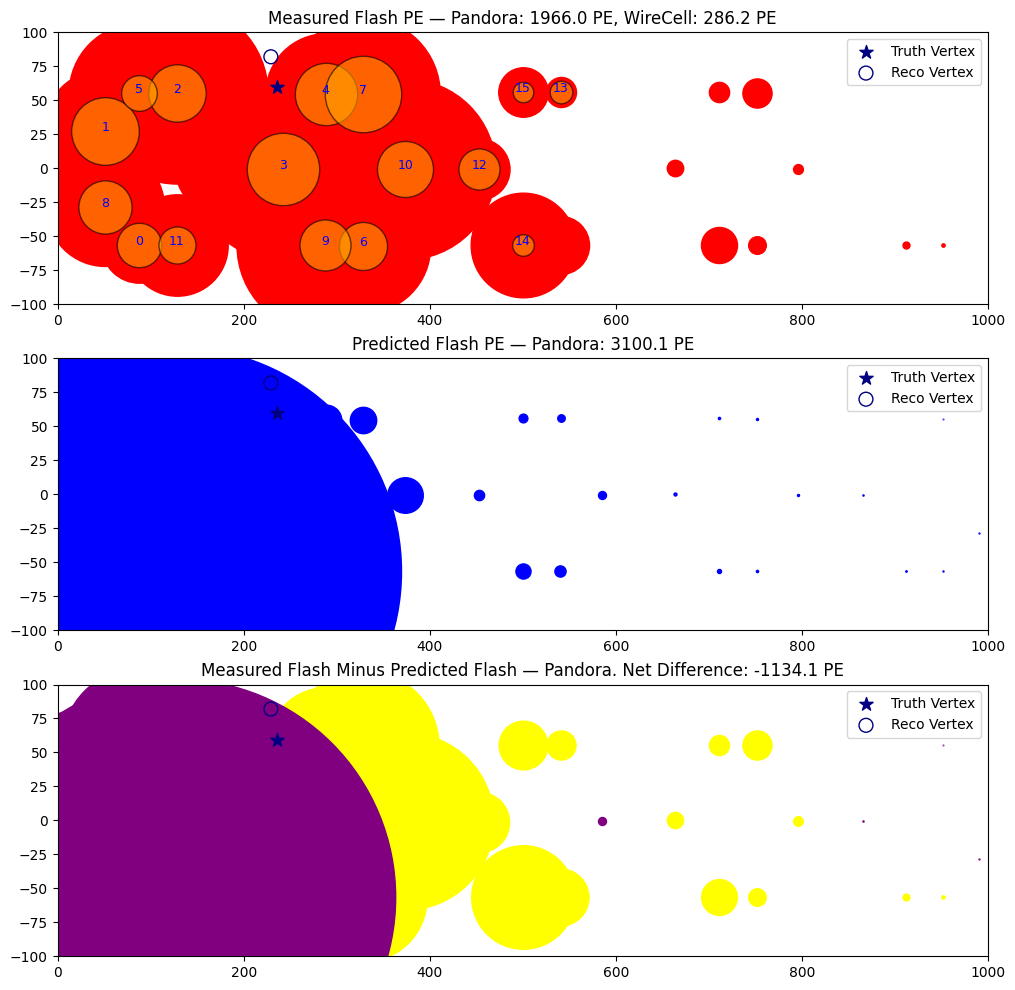

In [196]:
# mark's visualization (more basic version of event displays)

event_id = 12345

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

wc_meas_pmt_array = f["wcpselection"]["T_PFeval"]["PMT_Amp"].arrays(library="np")["PMT_Amp"]
wc_ID_pmt_array = f["wcpselection"]["T_PFeval"]["PMT_ID"].arrays(library="np")["PMT_ID"]
wc_pmt_sat = f["wcpselection"]["T_PFeval"]['PMT_Sat'].arrays(library="np")["PMT_Sat"]
pmt_time = f["wcpselection"]["T_PFeval"]['PMT_Time'].arrays(library="np")["PMT_Time"]

#print(pmt_time[event_id])

meas_pmt_array = f["nuselection"]["NeutrinoSelectionFilter"]["flash_pe_flash_matching_v"].arrays(library="np")["flash_pe_flash_matching_v"]
pred_pmt_array = f["nuselection"]["NeutrinoSelectionFilter"]["slice_pe_flash_matching_v"].arrays(library="np")["slice_pe_flash_matching_v"]

size_scale = 75

pandora_meas_total = 0.0
pandora_pred_total = 0.0
wirecell_meas_total = 0.0
wirecell_pred_total = 0.0
p_minus_m_total = 0.0

truth_vtxY = all_df.loc[event_id, "truth_vtxY"]
truth_vtxZ = all_df.loc[event_id, "truth_vtxZ"]
reco_vtxY = all_df.loc[event_id, "reco_nuvtxY"]
reco_vtxZ = all_df.loc[event_id, "reco_nuvtxZ"]

#pandora
for pmt_id in range(32):
    reco_pmt_position = reco_position_dic[pmt_id]
    meas_flash_pe = meas_pmt_array[event_id][pmt_id]
    pred_flash_pe = pred_pmt_array[event_id][pmt_id]
    pandora_meas_total += meas_flash_pe
    pandora_pred_total += pred_flash_pe
    axs[0].scatter(reco_pmt_position[2], reco_pmt_position[1], color="red", s=meas_flash_pe * size_scale)
    axs[1].scatter(reco_pmt_position[2], reco_pmt_position[1], color="blue", s=pred_flash_pe * size_scale)
    # per pmt meas-predicted
    meas_minus_pred_pe = meas_pmt_array[event_id][pmt_id] - pred_pmt_array[event_id][pmt_id]
    p_minus_m_total += meas_minus_pred_pe
    diff = meas_minus_pred_pe
    color = "yellow" if diff > 0 else "purple"
    axs[2].scatter(reco_pmt_position[2], reco_pmt_position[1], color=color, s=abs(diff) * size_scale)



#wirecell
wc_meas_pe_event = wc_meas_pmt_array[event_id]
wc_id_event = wc_ID_pmt_array[event_id]
wc_pmt_sat_event = wc_pmt_sat[event_id]
wc_pmt_time_event = pmt_time[event_id]



pmt_info = list(zip(wc_pmt_time_event, wc_id_event, wc_meas_pe_event, wc_pmt_sat_event))
pmt_info_sorted = sorted(pmt_info)

for order, (wc_time, wc_id, wc_pe, wc_sat) in enumerate(pmt_info_sorted):
    if wc_id in reco_position_dic:
        pos = reco_position_dic[wc_id]
        wirecell_meas_total += wc_pe
        axs[0].scatter(pos[2], pos[1], color="orange", s=wc_pe * size_scale, alpha=0.6, edgecolor='k')
        #print(wc_pe, wc_sat)
        axs[0].text(pos[2], pos[1], str(order), fontsize=9, ha='center', color='blue')
    #if wc_sat==1:
       #axs[0].text(pos[2], pos[1], 'X', fontsize=12, ha='center', va='center', color='black', fontweight='bold')
        
for ax in axs:
    ax.scatter(truth_vtxZ, truth_vtxY, color='navy', marker='*', s=100, label='Truth Vertex')
    ax.scatter(reco_vtxZ, reco_vtxY, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex')

    ax.set_xlim(0, 1000)
    ax.set_ylim(-100, 100)
    ax.legend(loc='upper right')

axs[0].set_title(f"Measured Flash PE — Pandora: {pandora_meas_total:.1f} PE, WireCell: {wirecell_meas_total:.1f} PE")
axs[1].set_title(f"Predicted Flash PE — Pandora: {pandora_pred_total:.1f} PE")
axs[2].set_title(f"Measured Flash Minus Predicted Flash — Pandora. Net Difference: {p_minus_m_total:.1f} PE")

plt.show()


        
    


In [197]:
# best event display

rechargeblob_y = all_df['Trecchargeblob_spacepoints_y']
rechargeblob_z = all_df['Trecchargeblob_spacepoints_z']
rechargeblob_x = all_df['Trecchargeblob_spacepoints_x']

wc_meas_pmt_array = all_df['PMT_Amp']
wc_ID_pmt_array = all_df['PMT_ID']
wc_pmt_sat = all_df['PMT_Sat']
pmt_time = all_df['PMT_Time']
wirecell_pred_total = all_df['pred_total_wc']

meas_pmt_array = all_df['flash_pe_flash_matching_v']
pred_pmt_array = all_df['slice_pe_flash_matching_v']

def make_event_display(event_id, save_dir):
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))

    size_scale = 75

    pandora_meas_total = 0.0
    pandora_pred_total = 0.0
    wirecell_meas_total = 0.0
    p_minus_m_total = 0.0

    truth_vtxY = all_df.loc[event_id, "truth_vtxY"]
    truth_vtxZ = all_df.loc[event_id, "truth_vtxZ"]
    reco_vtxY = all_df.loc[event_id, "reco_nuvtxY"]
    reco_vtxZ = all_df.loc[event_id, "reco_nuvtxZ"]
    truth_vtxX = all_df.loc[event_id, "truth_vtxX"]
    reco_vtxX = all_df.loc[event_id, "reco_nuvtxX"]

    #pandora

    if len(meas_pmt_array[event_id]) == 0 or len(pred_pmt_array[event_id]) == 0:
        print(f"Skipping event {event_id} due to empty flash_pe arrays.")
        return  # skip or log instead of crashing

    for pmt_id in range(32):
        true_pmt_position = true_position_dic[pmt_id] ### UNCLEAR IF RECO OR TRUE POSITION IS ACCURATE
        meas_flash_pe = meas_pmt_array[event_id][pmt_id]
        pred_flash_pe = pred_pmt_array[event_id][pmt_id]

        pandora_meas_total += meas_flash_pe
        pandora_pred_total += pred_flash_pe
        axs[0].scatter(true_pmt_position[2], true_pmt_position[1], color="red", alpha=0.8, s=meas_flash_pe * size_scale) # plots pandora measured
        axs[1].scatter(true_pmt_position[2], true_pmt_position[1], color="blue", alpha=0.8, s=pred_flash_pe * size_scale) # plots pandora predicted
        # per pmt meas-predicted
        meas_minus_pred_pe = meas_pmt_array[event_id][pmt_id] / np.sum(meas_pmt_array[event_id]) - pred_pmt_array[event_id][pmt_id] / np.sum(pred_pmt_array[event_id]) # (normalized)
        p_minus_m_total += meas_pmt_array[event_id][pmt_id] - pred_pmt_array[event_id][pmt_id] 
        diff = meas_minus_pred_pe * 1000 # scale for visibility
        color = "gold" if diff > 0 else "indigo"
        axs[2].scatter(true_pmt_position[2], true_pmt_position[1], color=color, alpha=0.8, s=abs(diff) * size_scale) # plots measured minus predicted bubbles

    #wirecell
    wc_meas_pe_event = np.atleast_1d(wc_meas_pmt_array[event_id])
    wc_id_event = np.atleast_1d(wc_ID_pmt_array[event_id])
    wc_pmt_sat_event = np.atleast_1d(wc_pmt_sat[event_id])
    wc_pmt_time_event = np.atleast_1d(pmt_time[event_id])

    pmt_info = list(zip(wc_pmt_time_event, wc_id_event, wc_meas_pe_event, wc_pmt_sat_event))
    print(pmt_info)
    pmt_info_sorted = sorted(pmt_info)

    mean_time = np.median(wc_pmt_time_event)

    for wc_time, wc_id, wc_pe, wc_sat in pmt_info_sorted:
        if wc_id in true_position_dic:
            pos = true_position_dic[wc_id]
            wirecell_meas_total += wc_pe
            axs[0].scatter(pos[2], pos[1], color="orange", s=wc_pe * size_scale, alpha=0.6, edgecolor='k') # plots wirecell per pmt measured
            
            # time offset from mean (ns), rounded
            time_offset = round(wc_time - mean_time)
            label = f"{int(time_offset)}"
            axs[0].text(pos[2], pos[1], label, fontsize=7, ha='center', color='blue') # plots ns timing
    
    angle_deg = 10  # narrow angle of the triangle
    angle_rad = np.radians(angle_deg)
    
    true_gamma_xs = true_gamma_df["true_gamma_pairconversion_xs"].to_numpy()[event_id]
    true_gamma_ys = true_gamma_df["true_gamma_pairconversion_ys"].to_numpy()[event_id]
    true_gamma_zs = true_gamma_df["true_gamma_pairconversion_zs"].to_numpy()[event_id]

    true_gamma_pxs = true_gamma_df["true_gamma_pairconversion_pxs"].to_numpy()[event_id]
    true_gamma_pys = true_gamma_df["true_gamma_pairconversion_pys"].to_numpy()[event_id]
    true_gamma_pzs = true_gamma_df["true_gamma_pairconversion_pzs"].to_numpy()[event_id]

    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, y])  # Z is horizontal, Y is vertical

        direction = np.array([pz, py])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[:2]:
        ax.scatter(truth_vtxZ, truth_vtxY, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxY, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6, 1036.4)
        ax.set_ylim(-115.0, 117.0)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_y[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
    # add xz view
    
    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, x])  # Z is horizontal, Y is vertical

        direction = np.array([pz, px])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[3:]:
        ax.scatter(truth_vtxZ, truth_vtxX, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxX, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6-60, 1036.4+60)
        ax.set_ylim(-1-60, 254.3+60)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_x[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
        # Define ZX bounds
        x_min, x_max = -1.0, 254.3
        z_min, z_max = 0.6, 1036.4
        
        ax.plot([z_min, z_min, z_max, z_max, z_min],
                [x_min, x_max, x_max, x_min, x_min], 'black', linestyle='--')
        



    axs[0].set_title(f"Measured Flash PE — Pandora: {pandora_meas_total:.1f} PE, WireCell: {wirecell_meas_total:.1f} PE")
    axs[1].set_title(f"Predicted Flash PE — Pandora: {pandora_pred_total:.1f} PE, WireCell: {wirecell_pred_total[event_id]:.1f}")
    axs[2].set_title(f"Measured Flash Minus Predicted Flash — Pandora. Net Difference: {p_minus_m_total:.1f} PE")
    axs[3].set_title(f"XZ View of Event with TPC Boundaries")
    fig.suptitle(f"Index: {event_id}, Type: {save_dir}")
    plt.tight_layout()
    plt.show() # uncomment here to make function print one event display
    #plt.savefig(f"{save_dir}/event_display_{event_id}.png", dpi=150) # remove this to show
    #plt.close() # remove this to show as well




[(np.float32(4089.2683), np.int32(8), np.float32(2.5590076), np.False_), (np.float32(4067.617), np.int32(10), np.float32(3.5174503), np.False_), (np.float32(4077.9788), np.int32(12), np.float32(3.7956326), np.False_), (np.float32(4065.975), np.int32(13), np.float32(9.727031), np.False_), (np.float32(4063.5999), np.int32(14), np.float32(20.632746), np.False_), (np.float32(4070.3188), np.int32(15), np.float32(15.347041), np.False_), (np.float32(4050.791), np.int32(16), np.float32(82.606735), np.False_), (np.float32(4047.3223), np.int32(18), np.float32(128.87177), np.True_), (np.float32(4060.1536), np.int32(19), np.float32(28.020672), np.False_), (np.float32(4062.1038), np.int32(20), np.float32(11.220774), np.False_), (np.float32(4053.1936), np.int32(21), np.float32(73.94156), np.False_), (np.float32(4065.5857), np.int32(22), np.float32(11.17997), np.False_), (np.float32(4052.8286), np.int32(23), np.float32(74.36641), np.False_), (np.float32(4062.9692), np.int32(24), np.float32(26.886261)

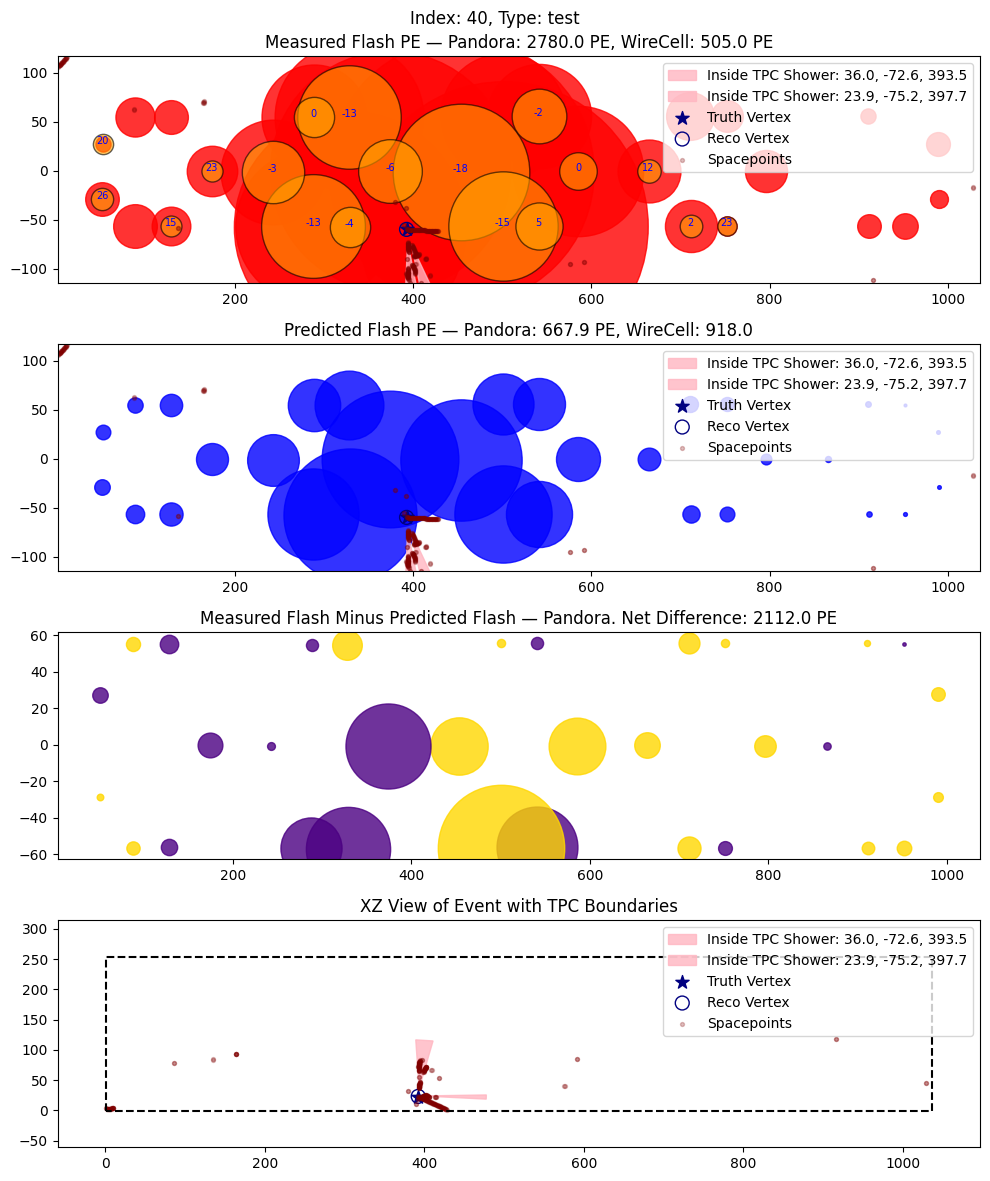

In [198]:
make_event_display(40, "test")

In [199]:
# trying to decide between reco and truth dic

# best event display

rechargeblob_y = all_df['Trecchargeblob_spacepoints_y']
rechargeblob_z = all_df['Trecchargeblob_spacepoints_z']
rechargeblob_x = all_df['Trecchargeblob_spacepoints_x']

wc_meas_pmt_array = all_df['PMT_Amp']
wc_ID_pmt_array = all_df['PMT_ID']
wc_pmt_sat = all_df['PMT_Sat']
pmt_time = all_df['PMT_Time']
wirecell_pred_total = all_df['pred_total_wc']

meas_pmt_array = all_df['flash_pe_flash_matching_v']
pred_pmt_array = all_df['slice_pe_flash_matching_v']

def look_at_dictionaries(event_id, save_dir):
    #import os
    #os.makedirs(save_dir, exist_ok=True)
    
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    size_scale = 75

    for pmt_id in range(32):
        
        reco_pmt_position = reco_position_dic[pmt_id]
        truth_pmt_position = true_position_dic[pmt_id]
        
        axs[0].scatter(reco_pmt_position[2], reco_pmt_position[1], color='white', marker='o', s=500, facecolors='none', edgecolors='navy', alpha=0.8)
        axs[1].text(truth_pmt_position[2], truth_pmt_position[1], f"{pmt_id}", fontsize=7, ha='center', color='blue')


        # Bottom plot: same reco position but labeled again with truth for comparison
        axs[1].scatter(truth_pmt_position[2], truth_pmt_position[1], color='white', marker='o', s=500, facecolors='none', edgecolors='navy', alpha=0.8)
        axs[0].text(reco_pmt_position[2], reco_pmt_position[1], f"{pmt_id}", fontsize=7, ha='center', color='blue')




    #for ax in axs:
       # ax.scatter(truth_vtxZ, truth_vtxX, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
       # ax.scatter(reco_vtxZ, reco_vtxX, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

       # ax.set_xlim(0.6-60, 1036.4+60)
       # ax.set_ylim(-1-60, 254.3+60)
       # ax.scatter(rechargeblob_z[event_id], rechargeblob_x[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
      #  ax.legend(loc='upper right', fontsize=10)
        
    axs[0].set_title(f"reco_position_dic")
    axs[1].set_title(f"true_position_dic")
   
    fig.suptitle(f"Index: {event_id}, Type: {save_dir}")
    #plt.tight_layout()
    plt.show() # uncomment here to make function print one event display
    #plt.savefig(f"{save_dir}/event_display_{event_id}.png", dpi=150) # remove this to show
    #plt.close() # remove this to show as well




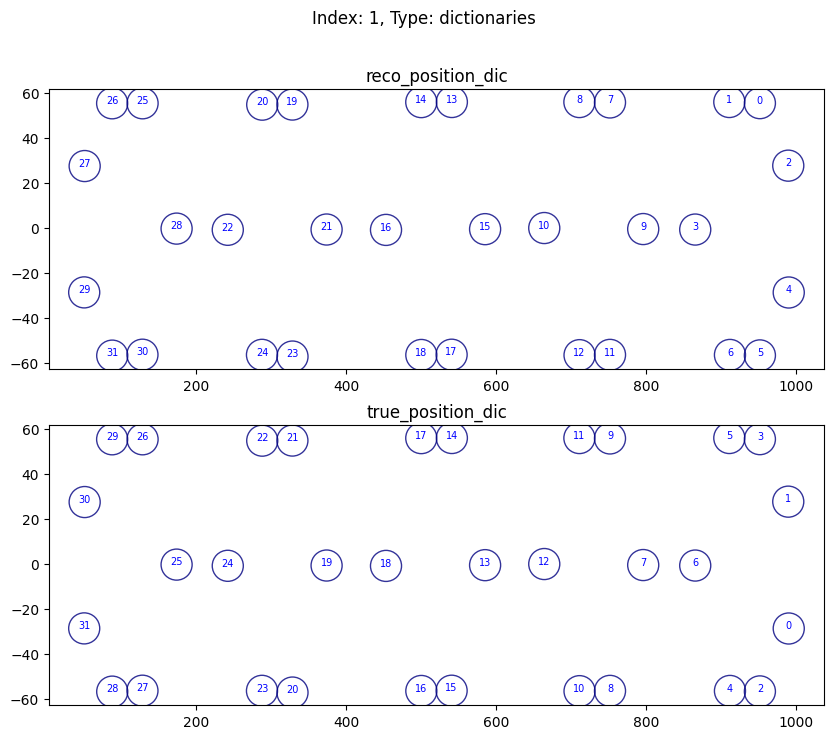

In [200]:
look_at_dictionaries(1, "dictionaries")

## Run event display code + generate folders

[(np.float32(4665.8545), np.int32(3), np.float32(2.6882913), np.False_), (np.float32(4630.852), np.int32(13), np.float32(20.03893), np.False_), (np.float32(4630.172), np.int32(14), np.float32(25.287014), np.False_), (np.float32(4629.155), np.int32(15), np.float32(6.808695), np.False_), (np.float32(4622.174), np.int32(16), np.float32(74.08904), np.False_), (np.float32(4627.116), np.int32(18), np.float32(16.070635), np.False_), (np.float32(4619.3174), np.int32(19), np.float32(84.143456), np.False_), (np.float32(4626.015), np.int32(20), np.float32(20.267342), np.False_), (np.float32(4615.666), np.int32(21), np.float32(203.01912), np.True_), (np.float32(4631.4497), np.int32(22), np.float32(15.113992), np.False_), (np.float32(4632.1533), np.int32(23), np.float32(14.372136), np.False_), (np.float32(4633.391), np.int32(24), np.float32(18.464796), np.False_), (np.float32(4691.732), np.int32(27), np.float32(4.0450983), np.False_)]


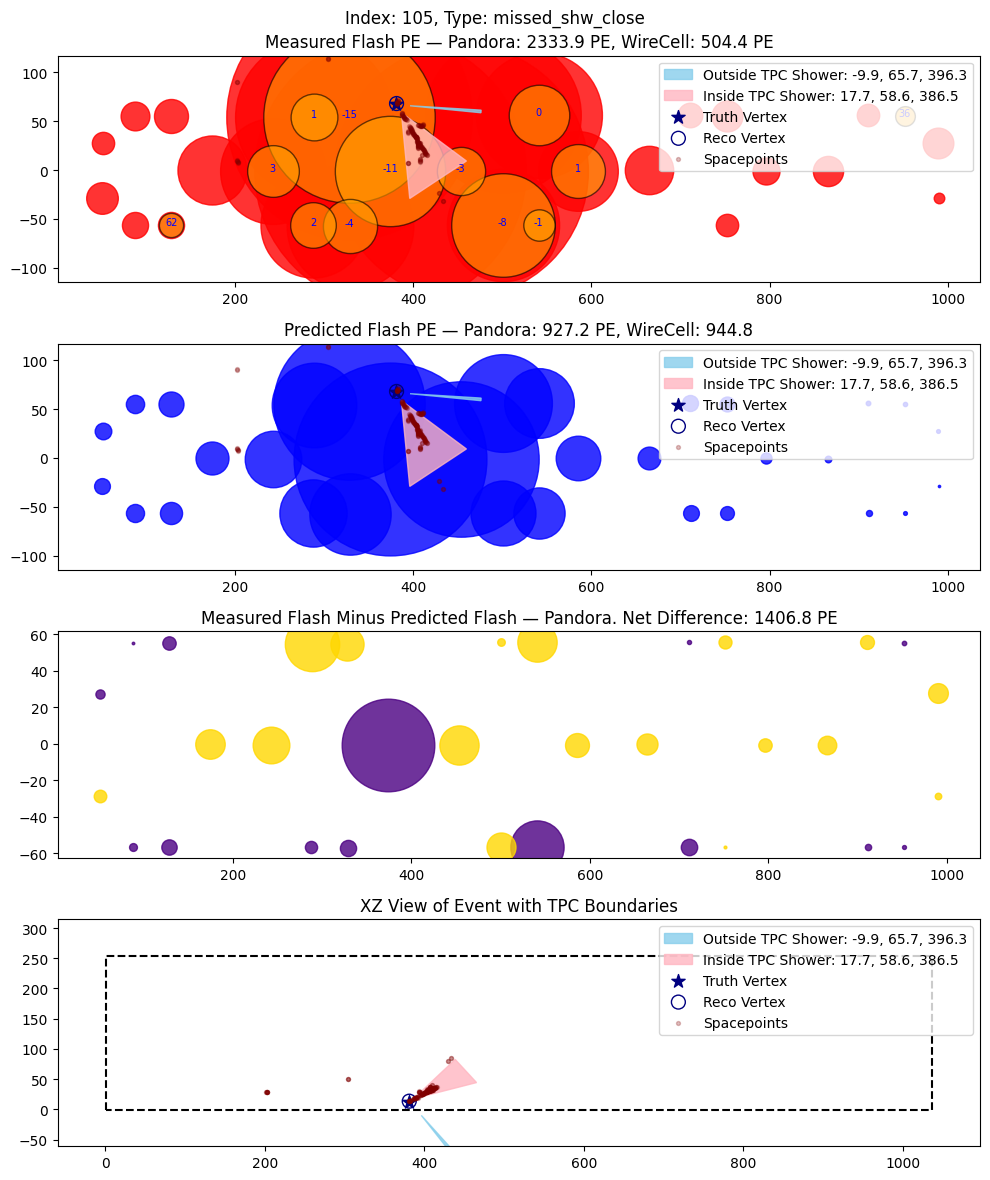

[(np.float32(3893.476), np.int32(19), np.float32(2.6583862), np.False_), (np.float32(3871.3816), np.int32(20), np.float32(6.1845407), np.False_), (np.float32(3861.4495), np.int32(22), np.float32(7.0563564), np.False_), (np.float32(3881.9568), np.int32(24), np.float32(3.6782708), np.False_), (np.float32(3854.783), np.int32(25), np.float32(32.58409), np.False_), (np.float32(3831.1648), np.int32(26), np.float32(562.98303), np.True_), (np.float32(3859.306), np.int32(27), np.float32(23.348848), np.False_), (np.float32(3850.843), np.int32(29), np.float32(40.043484), np.False_), (np.float32(3846.2544), np.int32(30), np.float32(76.884026), np.False_), (np.float32(3844.9683), np.int32(31), np.float32(70.54963), np.False_)]


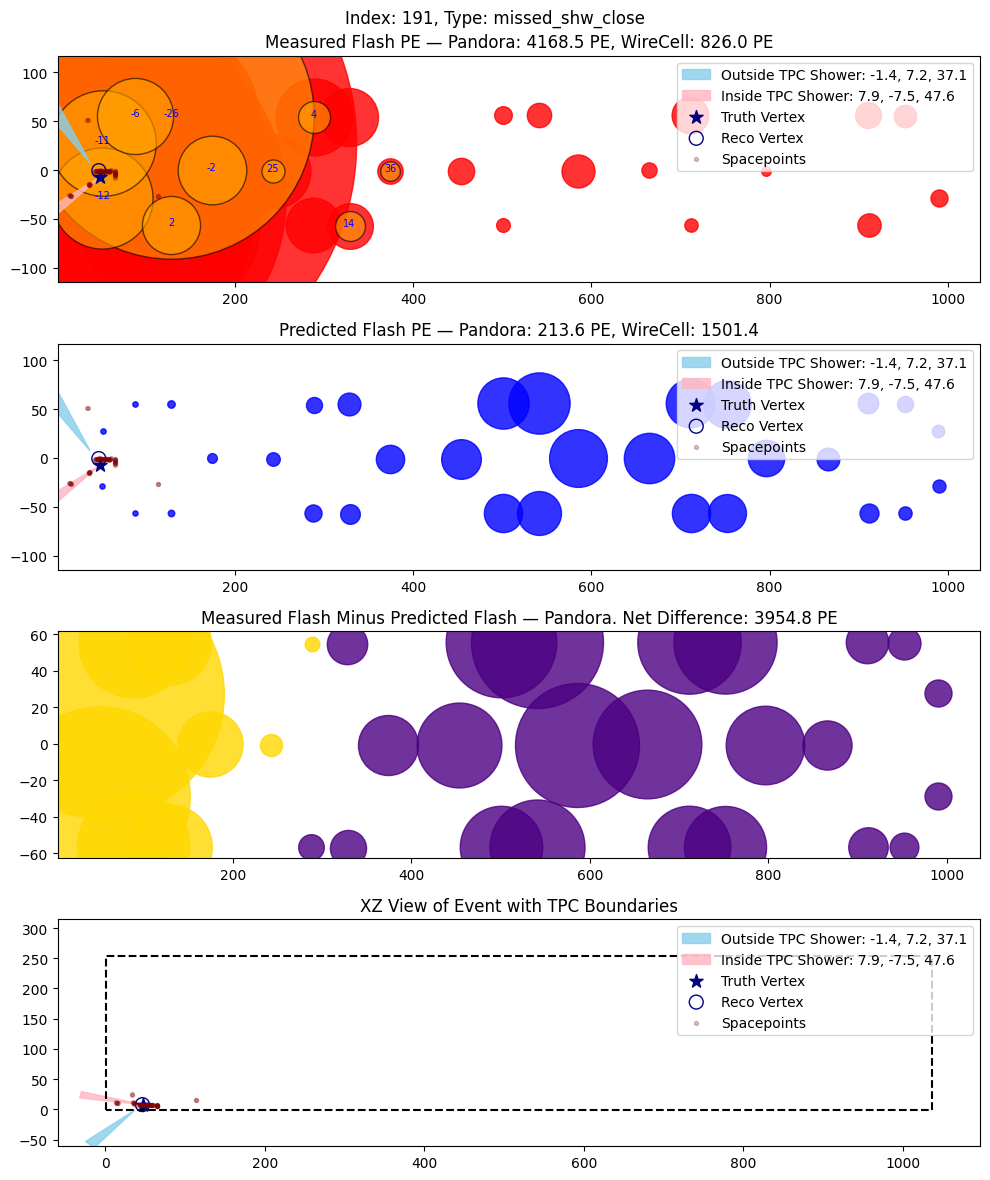

[(np.float32(4671.7437), np.int32(3), np.float32(4.3144083), np.False_), (np.float32(4644.6323), np.int32(7), np.float32(5.531843), np.False_), (np.float32(4640.961), np.int32(8), np.float32(9.837313), np.False_), (np.float32(4651.7104), np.int32(9), np.float32(6.643723), np.False_), (np.float32(4632.9116), np.int32(10), np.float32(25.695688), np.False_), (np.float32(4637.186), np.int32(11), np.float32(11.642723), np.False_), (np.float32(4635.693), np.int32(12), np.float32(24.525414), np.False_), (np.float32(4643.554), np.int32(13), np.float32(15.636794), np.False_), (np.float32(4643.9033), np.int32(14), np.float32(7.1769605), np.False_), (np.float32(4635.9375), np.int32(15), np.float32(23.637974), np.False_), (np.float32(4640.52), np.int32(16), np.float32(4.6130733), np.False_), (np.float32(4640.792), np.int32(18), np.float32(22.387768), np.False_)]


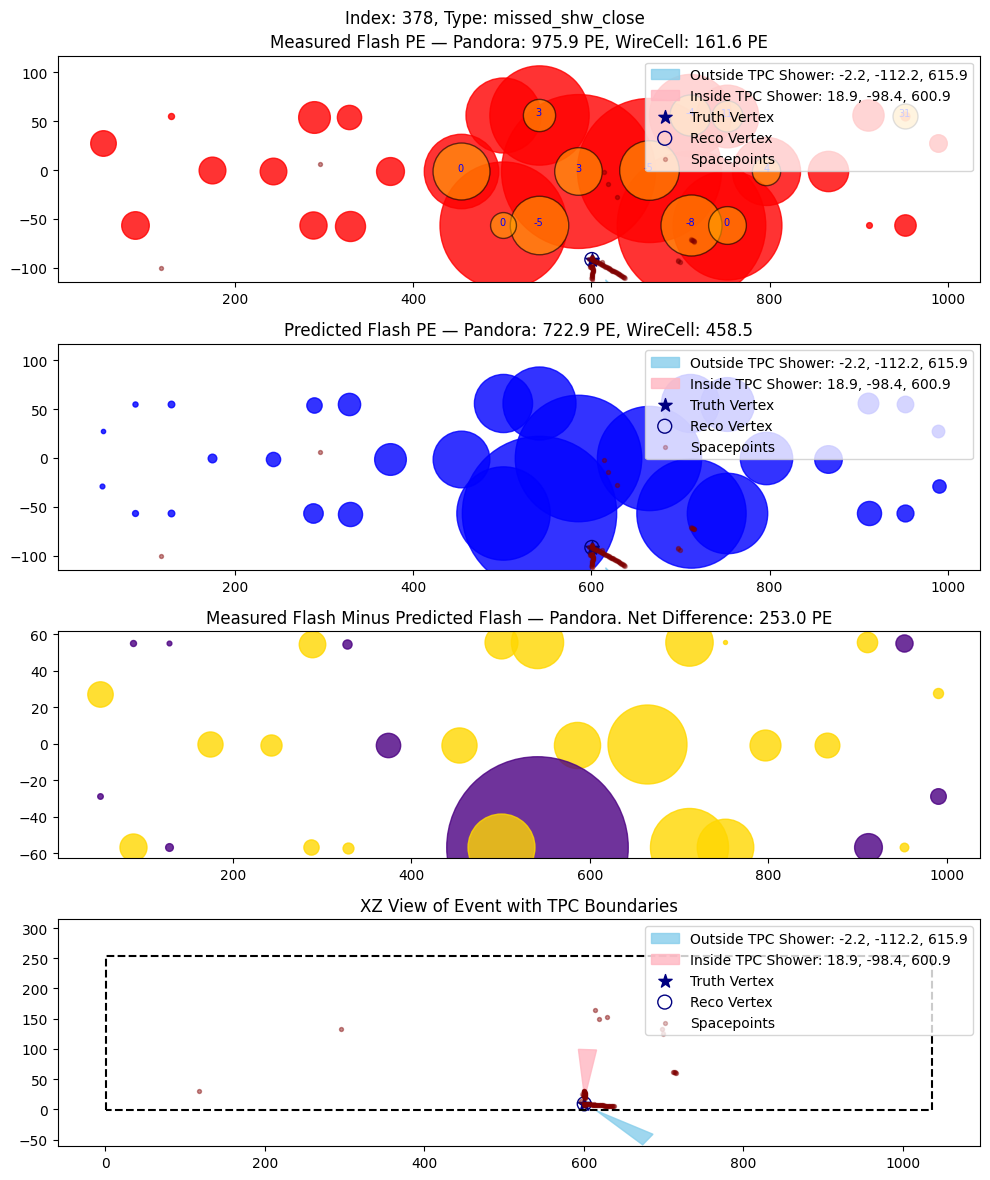

[(np.float32(4031.272), np.int32(13), np.float32(6.371809), np.False_), (np.float32(4025.4346), np.int32(14), np.float32(7.8811593), np.False_), (np.float32(4021.279), np.int32(16), np.float32(14.079306), np.False_), (np.float32(4012.8716), np.int32(18), np.float32(8.011676), np.False_), (np.float32(4016.0857), np.int32(19), np.float32(20.957085), np.False_), (np.float32(4019.917), np.int32(20), np.float32(18.16379), np.False_), (np.float32(4013.8662), np.int32(21), np.float32(24.05397), np.False_), (np.float32(4016.0508), np.int32(22), np.float32(27.54477), np.False_), (np.float32(3997.8137), np.int32(23), np.float32(147.8236), np.True_), (np.float32(4000.3604), np.int32(24), np.float32(136.31685), np.True_), (np.float32(4025.6995), np.int32(25), np.float32(3.2772987), np.False_), (np.float32(4035.9548), np.int32(26), np.float32(2.7697933), np.False_), (np.float32(4022.5288), np.int32(27), np.float32(7.7917967), np.False_), (np.float32(4021.042), np.int32(29), np.float32(4.1549625), n

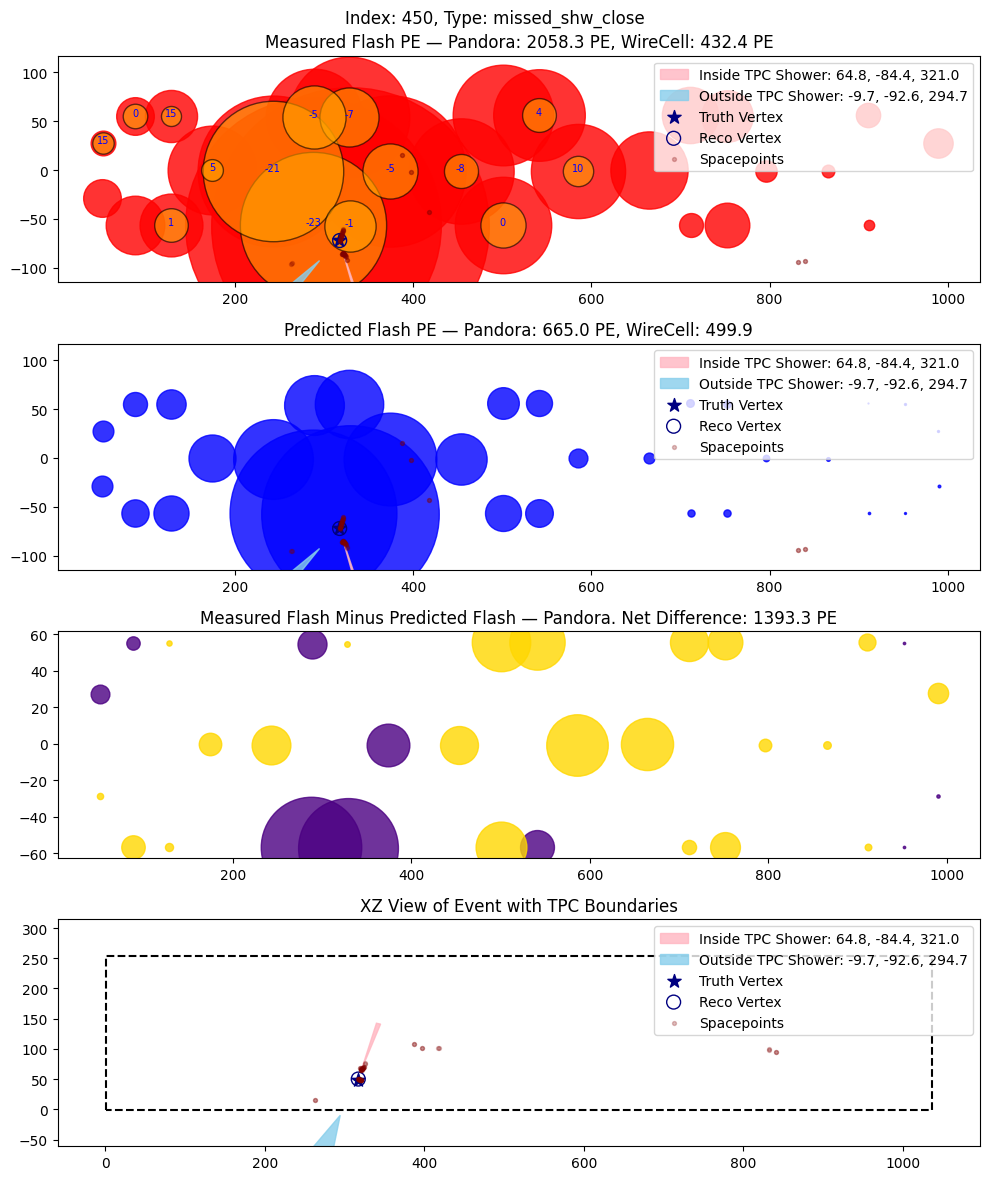

[(np.float32(3953.8735), np.int32(0), np.float32(25.839115), np.False_), (np.float32(3952.1912), np.int32(1), np.float32(17.317032), np.False_), (np.float32(3957.2405), np.int32(2), np.float32(31.559347), np.False_), (np.float32(3948.88), np.int32(3), np.float32(31.710592), np.False_), (np.float32(3944.203), np.int32(4), np.float32(75.307), np.False_), (np.float32(3934.8862), np.int32(5), np.float32(332.66635), np.True_), (np.float32(3931.9468), np.int32(6), np.float32(286.42584), np.True_), (np.float32(3960.8276), np.int32(7), np.float32(5.079292), np.False_), (np.float32(3959.2676), np.int32(9), np.float32(6.1867795), np.False_), (np.float32(3959.001), np.int32(11), np.float32(5.057396), np.False_), (np.float32(3958.6733), np.int32(12), np.float32(2.803392), np.False_)]


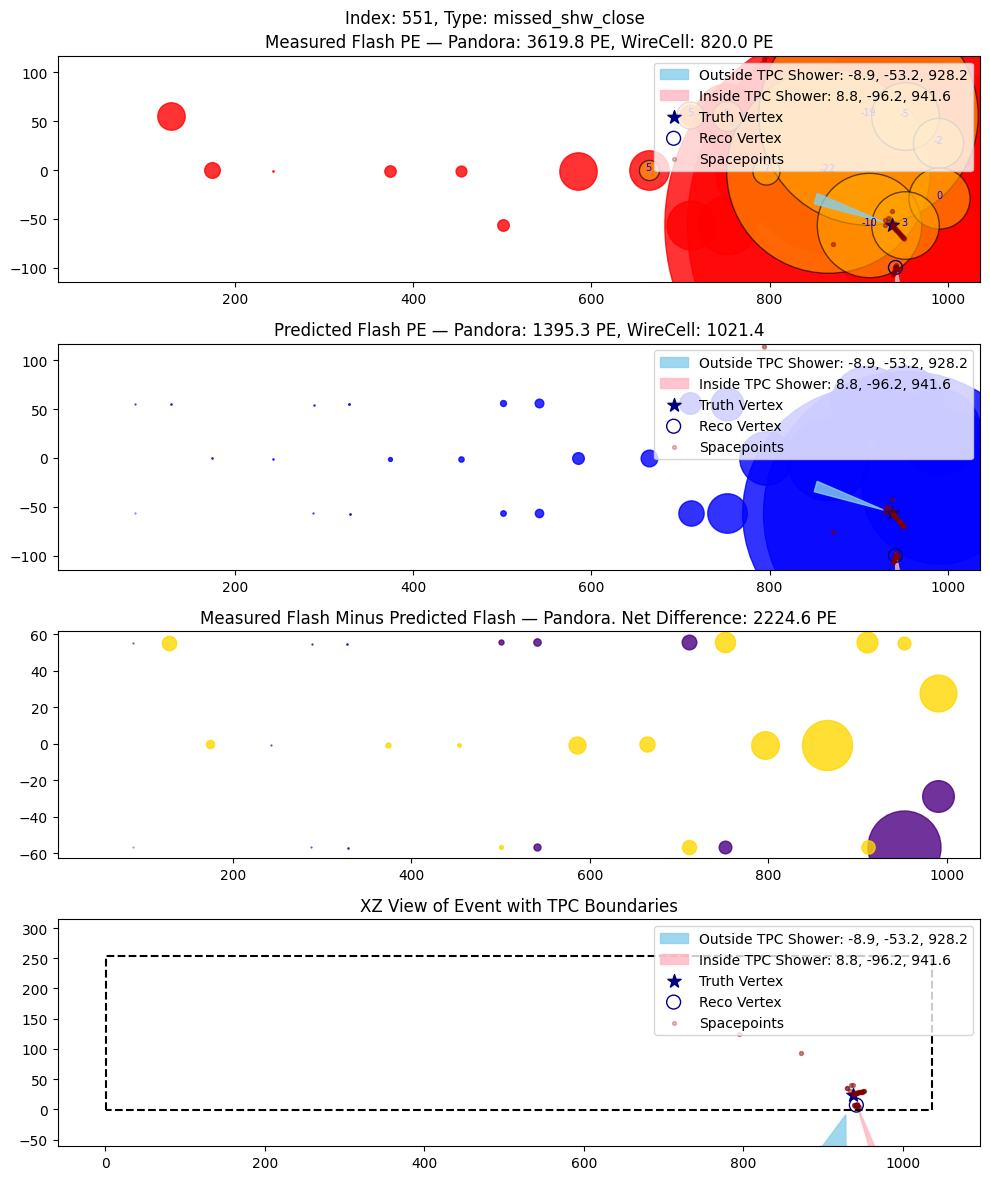

[(np.float32(3776.9224), np.int32(8), np.float32(3.0515804), np.False_), (np.float32(3624.7195), np.int32(10), np.float32(3.4744382), np.False_), (np.float32(3615.3555), np.int32(13), np.float32(20.837654), np.False_), (np.float32(3609.3562), np.int32(14), np.float32(43.691048), np.False_), (np.float32(3623.0554), np.int32(15), np.float32(7.38486), np.False_), (np.float32(3599.888), np.int32(16), np.float32(227.77621), np.True_), (np.float32(3609.4626), np.int32(18), np.float32(31.086561), np.False_), (np.float32(3609.0408), np.int32(19), np.float32(67.16458), np.False_), (np.float32(3615.5964), np.int32(20), np.float32(24.809347), np.False_), (np.float32(3594.3225), np.int32(21), np.float32(428.8722), np.True_), (np.float32(3618.0757), np.int32(22), np.float32(12.987274), np.False_), (np.float32(3612.4531), np.int32(23), np.float32(47.205208), np.False_), (np.float32(3616.3105), np.int32(24), np.float32(22.55954), np.False_), (np.float32(3634.492), np.int32(27), np.float32(2.698919), 

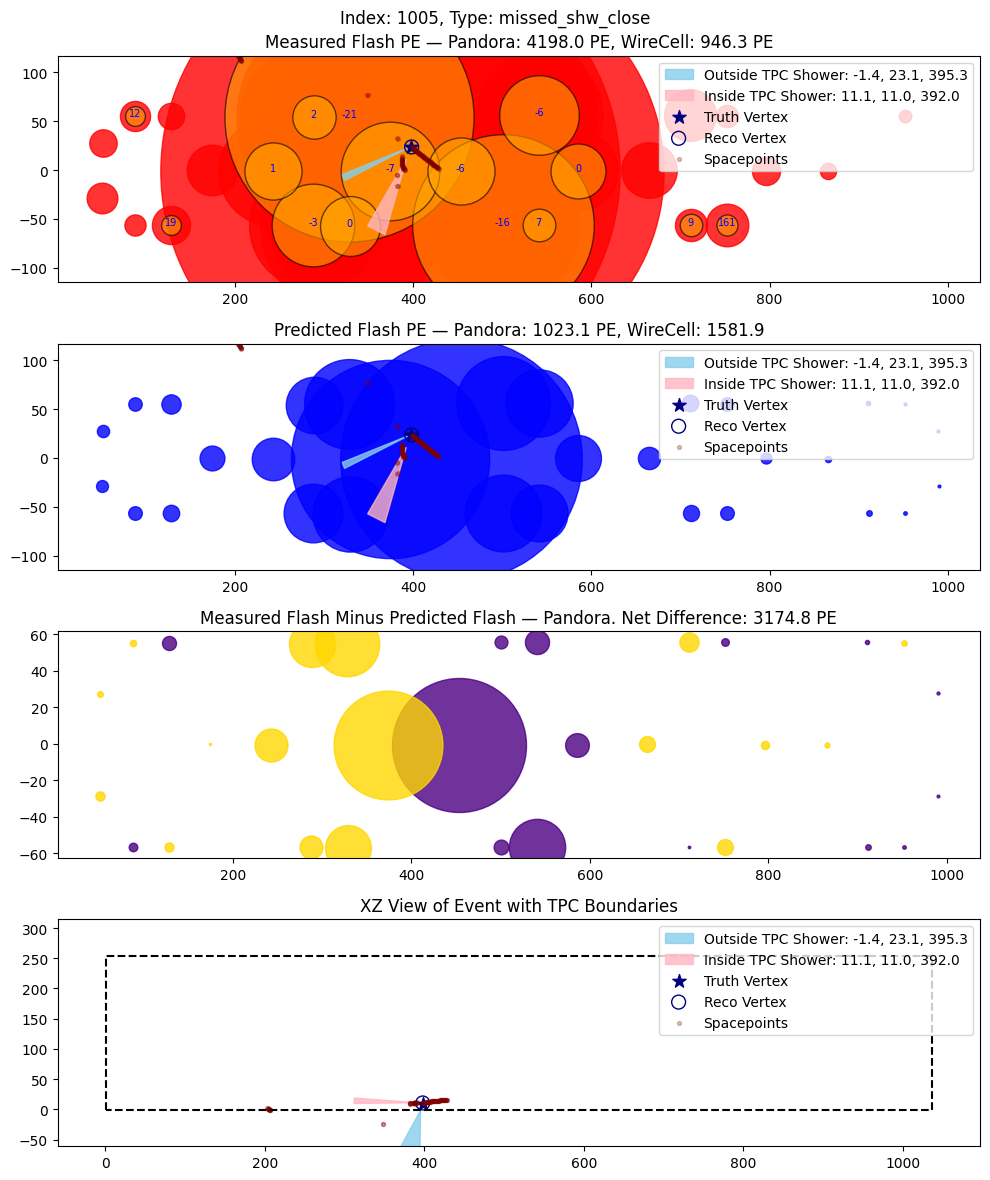

[(np.float32(3361.9548), np.int32(0), np.float32(11.813543), np.False_), (np.float32(3351.6006), np.int32(1), np.float32(11.727944), np.False_), (np.float32(3363.029), np.int32(2), np.float32(11.421349), np.False_), (np.float32(3350.7166), np.int32(3), np.float32(35.65854), np.False_), (np.float32(3354.6692), np.int32(4), np.float32(15.613062), np.False_), (np.float32(3348.721), np.int32(5), np.float32(46.503117), np.False_), (np.float32(3344.8013), np.int32(6), np.float32(118.78409), np.True_), (np.float32(3388.0137), np.int32(7), np.float32(3.2161644), np.False_), (np.float32(3359.0447), np.int32(8), np.float32(3.3284724), np.False_), (np.float32(3363.8325), np.int32(9), np.float32(12.018256), np.False_), (np.float32(3353.2737), np.int32(10), np.float32(6.295613), np.False_), (np.float32(3360.5566), np.int32(11), np.float32(11.566651), np.False_), (np.float32(3478.1758), np.int32(12), np.float32(3.835868), np.False_), (np.float32(3359.589), np.int32(13), np.float32(2.6660023), np.Fal

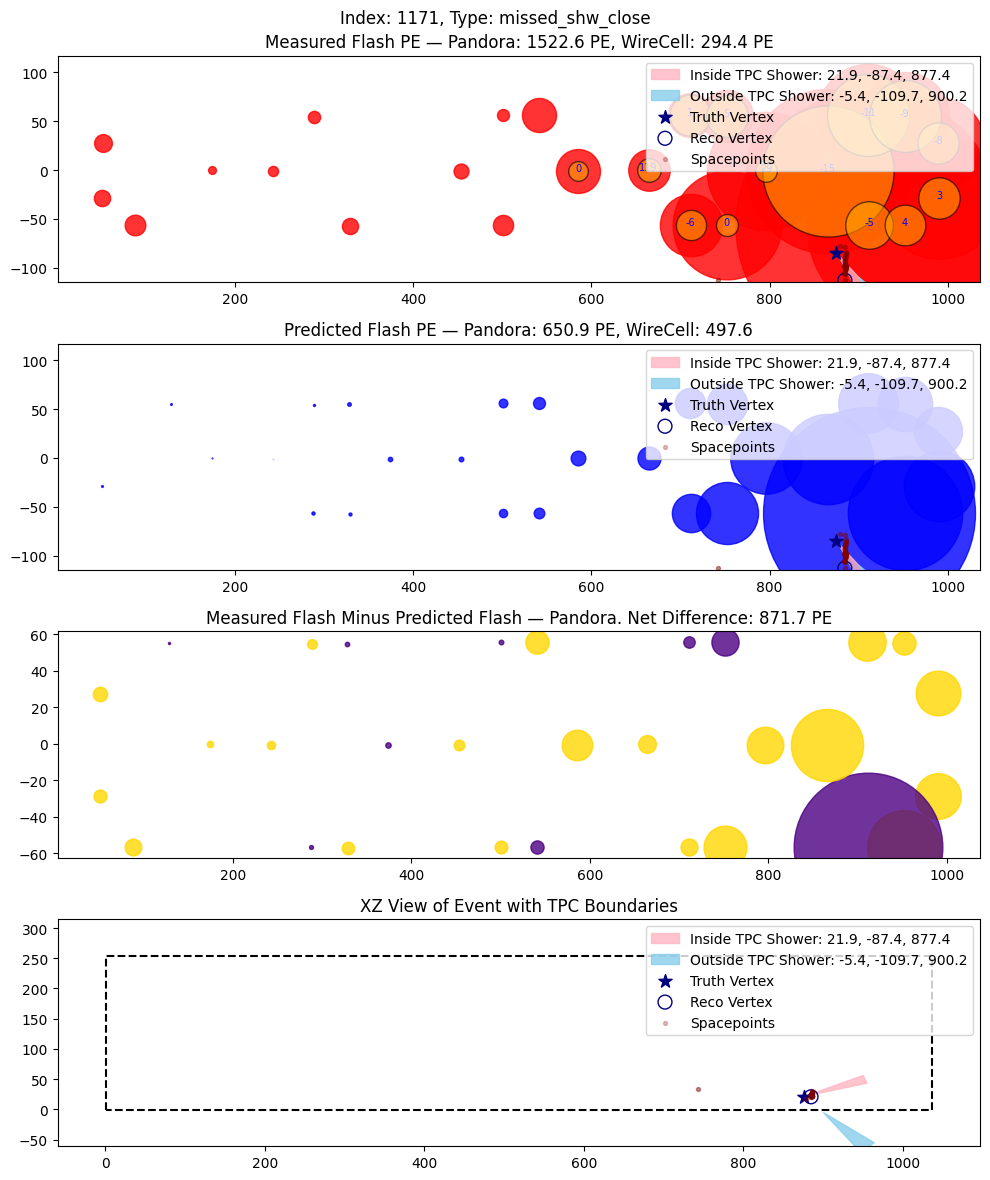

[(np.float32(4069.9587), np.int32(13), np.float32(8.257279), np.False_), (np.float32(4061.7095), np.int32(14), np.float32(13.47558), np.False_), (np.float32(4074.7478), np.int32(15), np.float32(7.225434), np.False_), (np.float32(4058.8938), np.int32(16), np.float32(46.625816), np.False_), (np.float32(4061.8596), np.int32(18), np.float32(13.63385), np.False_), (np.float32(4053.5918), np.int32(19), np.float32(87.724335), np.False_), (np.float32(4053.5447), np.int32(20), np.float32(81.05085), np.False_), (np.float32(4041.5872), np.int32(21), np.float32(309.1574), np.True_), (np.float32(4051.9268), np.int32(22), np.float32(74.47732), np.False_), (np.float32(4041.3853), np.int32(24), np.float32(301.04544), np.True_), (np.float32(4066.1868), np.int32(25), np.float32(6.515558), np.False_), (np.float32(4064.53), np.int32(27), np.float32(14.075008), np.False_), (np.float32(4069.9246), np.int32(29), np.float32(6.4957676), np.False_), (np.float32(4062.6633), np.int32(30), np.float32(4.3530884), n

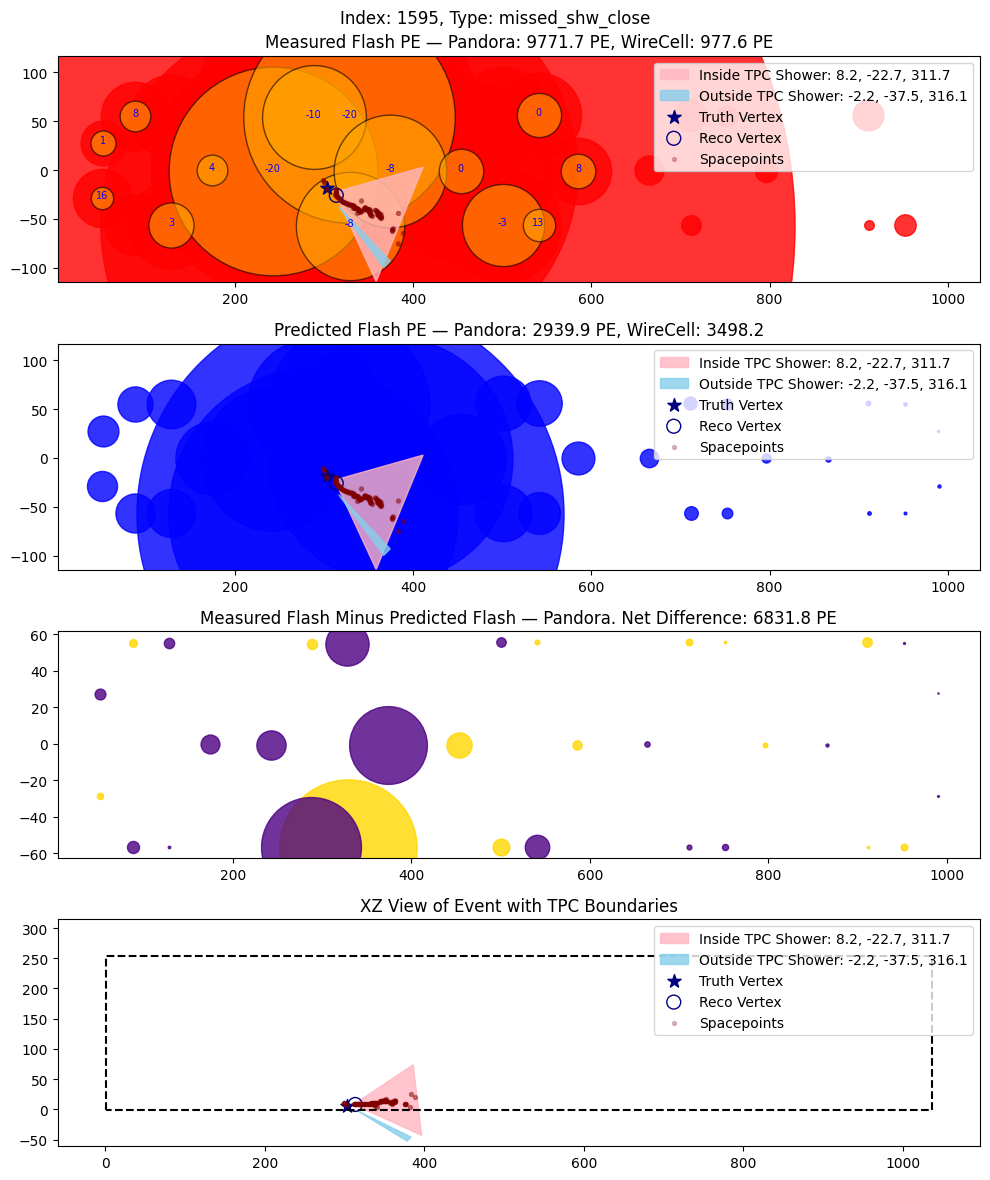

[(np.float32(3489.94), np.int32(7), np.float32(14.868072), np.False_), (np.float32(3485.6052), np.int32(8), np.float32(29.725508), np.False_), (np.float32(3493.5005), np.int32(9), np.float32(7.2991395), np.False_), (np.float32(3489.8198), np.int32(10), np.float32(30.807457), np.False_), (np.float32(3485.4104), np.int32(11), np.float32(5.199066), np.False_), (np.float32(3507.0618), np.int32(12), np.float32(6.691521), np.False_), (np.float32(3479.2786), np.int32(13), np.float32(78.914795), np.False_), (np.float32(3485.8616), np.int32(14), np.float32(24.364462), np.False_), (np.float32(3481.4897), np.int32(15), np.float32(41.11494), np.False_), (np.float32(3487.4832), np.int32(16), np.float32(7.32602), np.False_), (np.float32(3489.1743), np.int32(18), np.float32(8.242517), np.False_), (np.float32(3525.4426), np.int32(19), np.float32(3.9398382), np.False_), (np.float32(3500.1753), np.int32(21), np.float32(3.0056152), np.False_)]


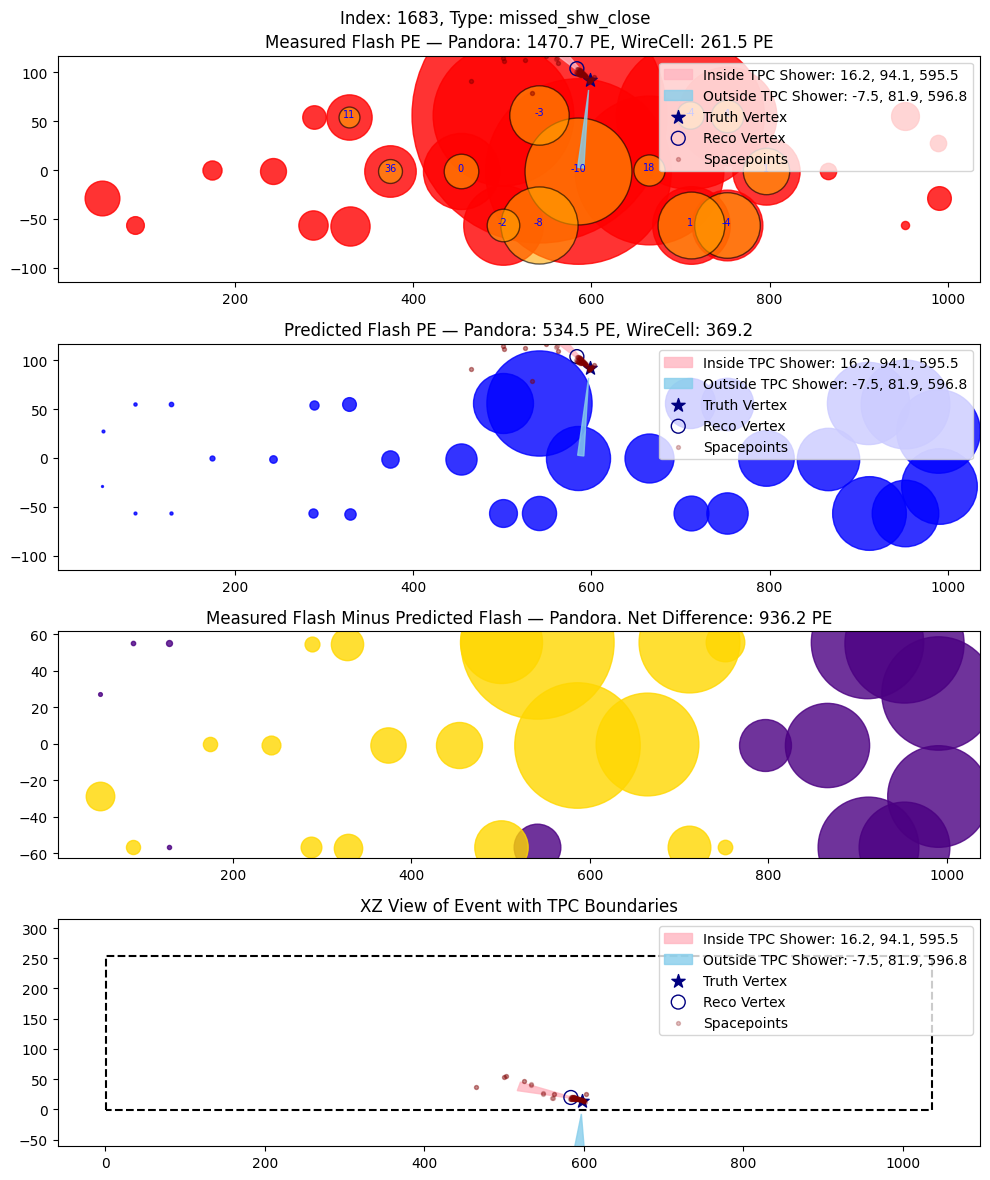

[(np.float32(4097.734), np.int32(10), np.float32(3.2632117), np.False_), (np.float32(4077.8064), np.int32(13), np.float32(7.1176763), np.False_), (np.float32(4073.9136), np.int32(14), np.float32(9.167474), np.False_), (np.float32(4065.5198), np.int32(15), np.float32(2.5297458), np.False_), (np.float32(4061.3225), np.int32(16), np.float32(24.697063), np.False_), (np.float32(4083.8137), np.int32(18), np.float32(11.683542), np.False_), (np.float32(4042.8347), np.int32(19), np.float32(2070.4832), np.True_), (np.float32(4049.1226), np.int32(20), np.float32(180.1409), np.True_), (np.float32(4057.7998), np.int32(21), np.float32(147.27992), np.True_), (np.float32(4058.2314), np.int32(22), np.float32(88.192566), np.False_), (np.float32(4049.3145), np.int32(23), np.float32(188.78778), np.True_), (np.float32(4049.1287), np.int32(24), np.float32(199.80421), np.True_), (np.float32(4072.0195), np.int32(25), np.float32(14.02723), np.False_), (np.float32(4072.4917), np.int32(26), np.float32(3.81498), 

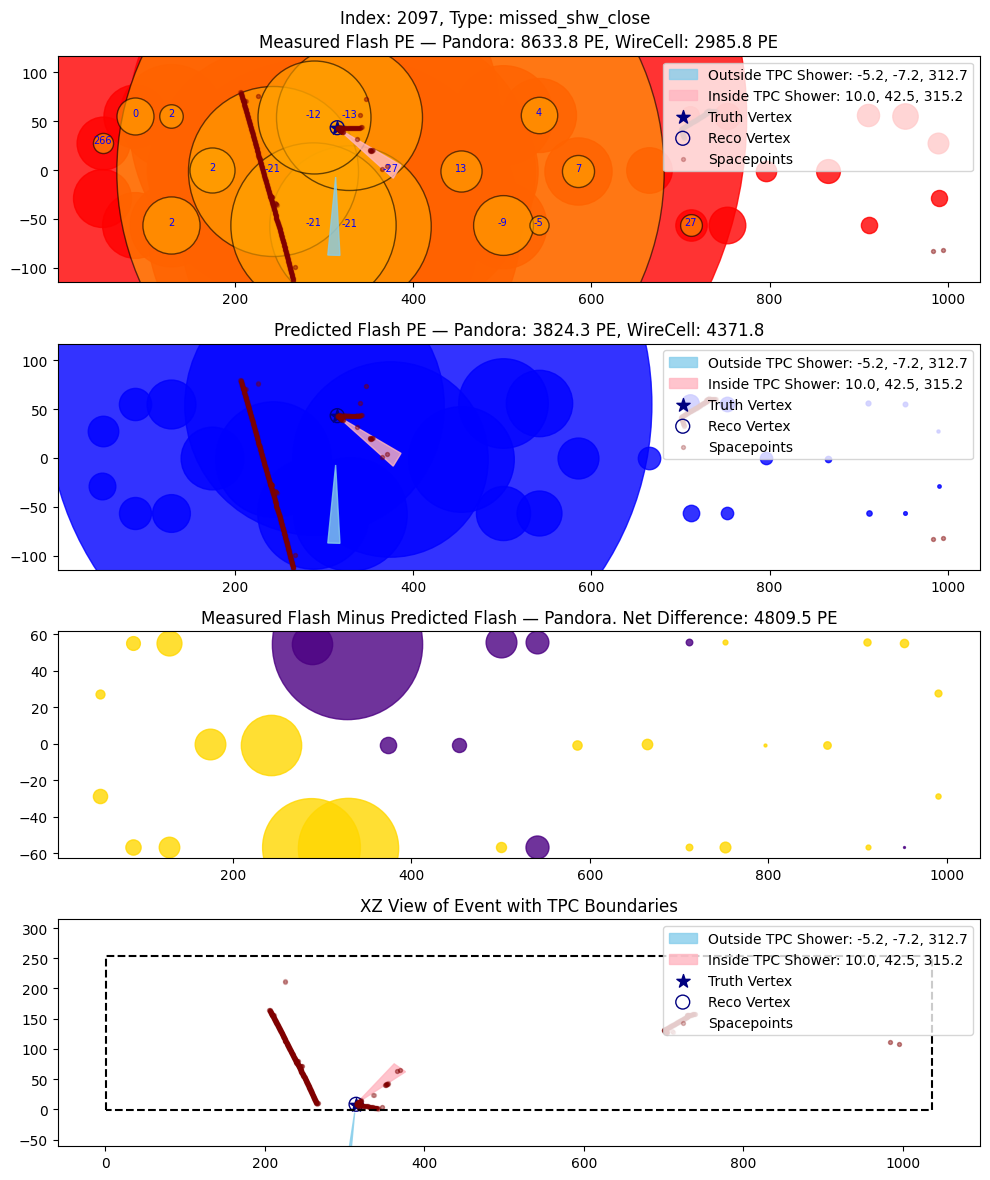

[(np.float32(3987.473), np.int32(0), np.float32(59.37797), np.False_), (np.float32(3989.23), np.int32(1), np.float32(48.955505), np.False_), (np.float32(3989.193), np.int32(2), np.float32(52.76149), np.False_), (np.float32(3989.9695), np.int32(3), np.float32(41.576782), np.False_), (np.float32(3989.4128), np.int32(4), np.float32(54.710556), np.False_), (np.float32(3989.4133), np.int32(5), np.float32(56.402573), np.False_), (np.float32(3990.262), np.int32(6), np.float32(50.61093), np.False_), (np.float32(4004.846), np.int32(7), np.float32(4.6481676), np.False_), (np.float32(4006.0085), np.int32(8), np.float32(4.2179728), np.False_), (np.float32(4005.2927), np.int32(9), np.float32(9.5045805), np.False_), (np.float32(4009.9417), np.int32(10), np.float32(2.9222507), np.False_), (np.float32(4013.9563), np.int32(11), np.float32(6.58841), np.False_), (np.float32(4012.1736), np.int32(12), np.float32(4.383582), np.False_)]


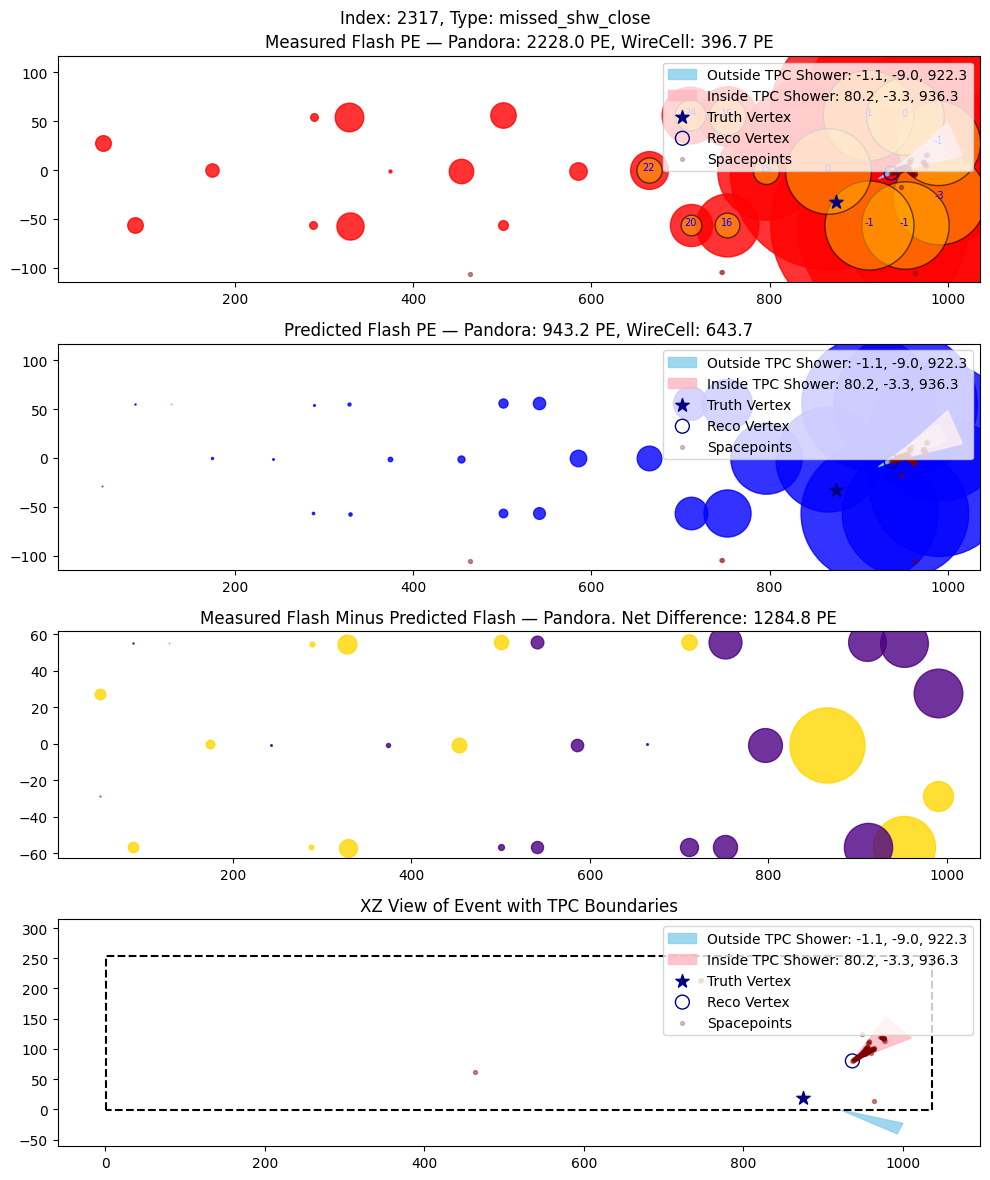

[(np.float32(3966.9348), np.int32(0), np.float32(65.54952), np.False_), (np.float32(3968.292), np.int32(1), np.float32(64.87004), np.False_), (np.float32(3966.0605), np.int32(2), np.float32(60.57385), np.False_), (np.float32(3954.9507), np.int32(3), np.float32(195.52808), np.True_), (np.float32(3955.1729), np.int32(4), np.float32(187.284), np.True_), (np.float32(3953.8108), np.int32(5), np.float32(570.70404), np.True_), (np.float32(3950.9443), np.int32(6), np.float32(329.1226), np.True_), (np.float32(3960.0408), np.int32(7), np.float32(155.63211), np.True_), (np.float32(3958.598), np.int32(8), np.float32(152.11935), np.True_), (np.float32(3957.246), np.int32(9), np.float32(262.38855), np.True_), (np.float32(3941.4316), np.int32(10), np.float32(776.737), np.True_), (np.float32(3940.506), np.int32(11), np.float32(528.56274), np.True_), (np.float32(3943.666), np.int32(12), np.float32(939.76416), np.True_), (np.float32(3964.3843), np.int32(13), np.float32(68.62738), np.False_), (np.float32

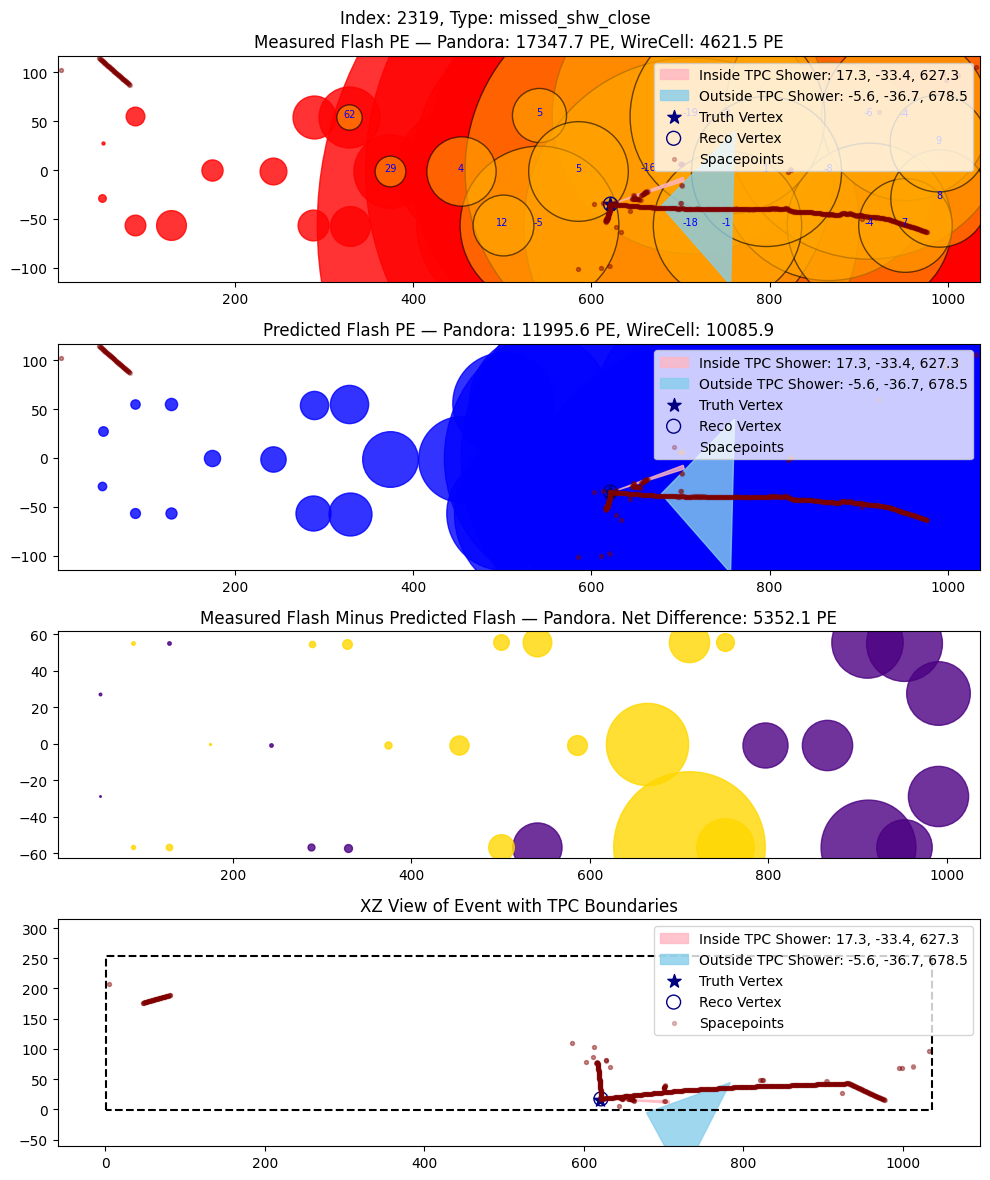

[(np.float32(3296.3728), np.int32(3), np.float32(4.1337237), np.False_), (np.float32(3301.8103), np.int32(6), np.float32(3.009363), np.False_), (np.float32(3271.9832), np.int32(7), np.float32(10.64734), np.False_), (np.float32(3258.781), np.int32(8), np.float32(11.752992), np.False_), (np.float32(3495.246), np.int32(9), np.float32(2.9230955), np.False_), (np.float32(3250.2632), np.int32(10), np.float32(87.45342), np.False_), (np.float32(3262.4536), np.int32(11), np.float32(17.183971), np.False_), (np.float32(3260.8535), np.int32(12), np.float32(37.184673), np.False_), (np.float32(3259.8074), np.int32(13), np.float32(28.051449), np.False_), (np.float32(3261.6658), np.int32(14), np.float32(24.391129), np.False_), (np.float32(3247.313), np.int32(15), np.float32(122.695366), np.True_), (np.float32(3260.266), np.int32(16), np.float32(9.364473), np.False_), (np.float32(3258.6375), np.int32(18), np.float32(19.094177), np.False_), (np.float32(3269.4941), np.int32(21), np.float32(3.2555063), np

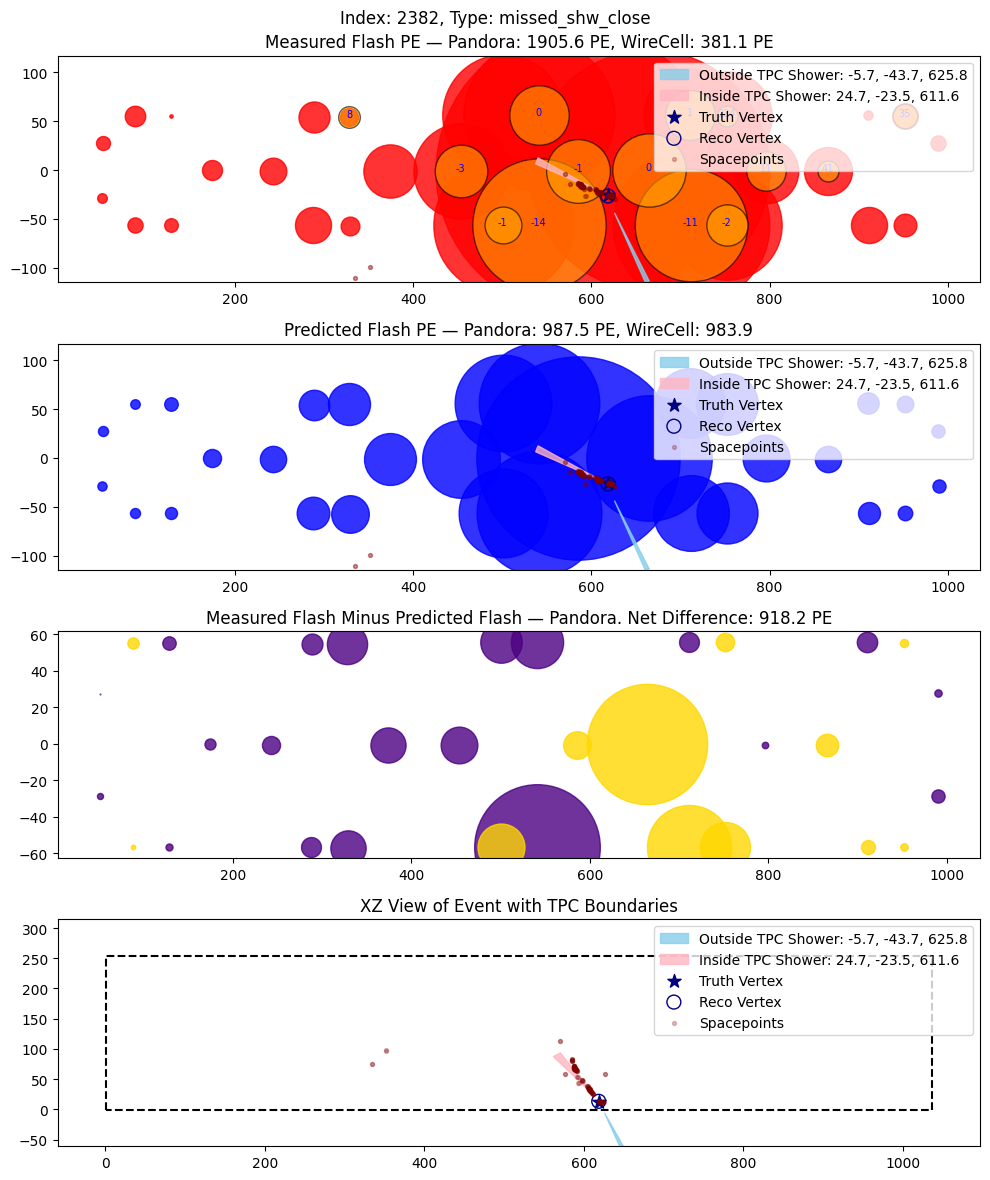

[(np.float32(4728.537), np.int32(13), np.float32(2.8102338), np.False_), (np.float32(4720.9565), np.int32(19), np.float32(14.961489), np.False_), (np.float32(4711.1797), np.int32(20), np.float32(31.93384), np.False_), (np.float32(4737.4443), np.int32(21), np.float32(5.4699726), np.False_), (np.float32(4719.0654), np.int32(22), np.float32(24.268341), np.False_), (np.float32(4744.626), np.int32(23), np.float32(5.2719097), np.False_), (np.float32(4724.723), np.int32(24), np.float32(8.292632), np.False_), (np.float32(4700.7617), np.int32(25), np.float32(250.47176), np.True_), (np.float32(4709.707), np.int32(26), np.float32(32.05098), np.False_), (np.float32(4712.298), np.int32(27), np.float32(50.255257), np.False_), (np.float32(4720.906), np.int32(29), np.float32(13.19668), np.False_), (np.float32(4714.1377), np.int32(30), np.float32(12.678196), np.False_), (np.float32(4702.929), np.int32(31), np.float32(71.64601), np.False_)]


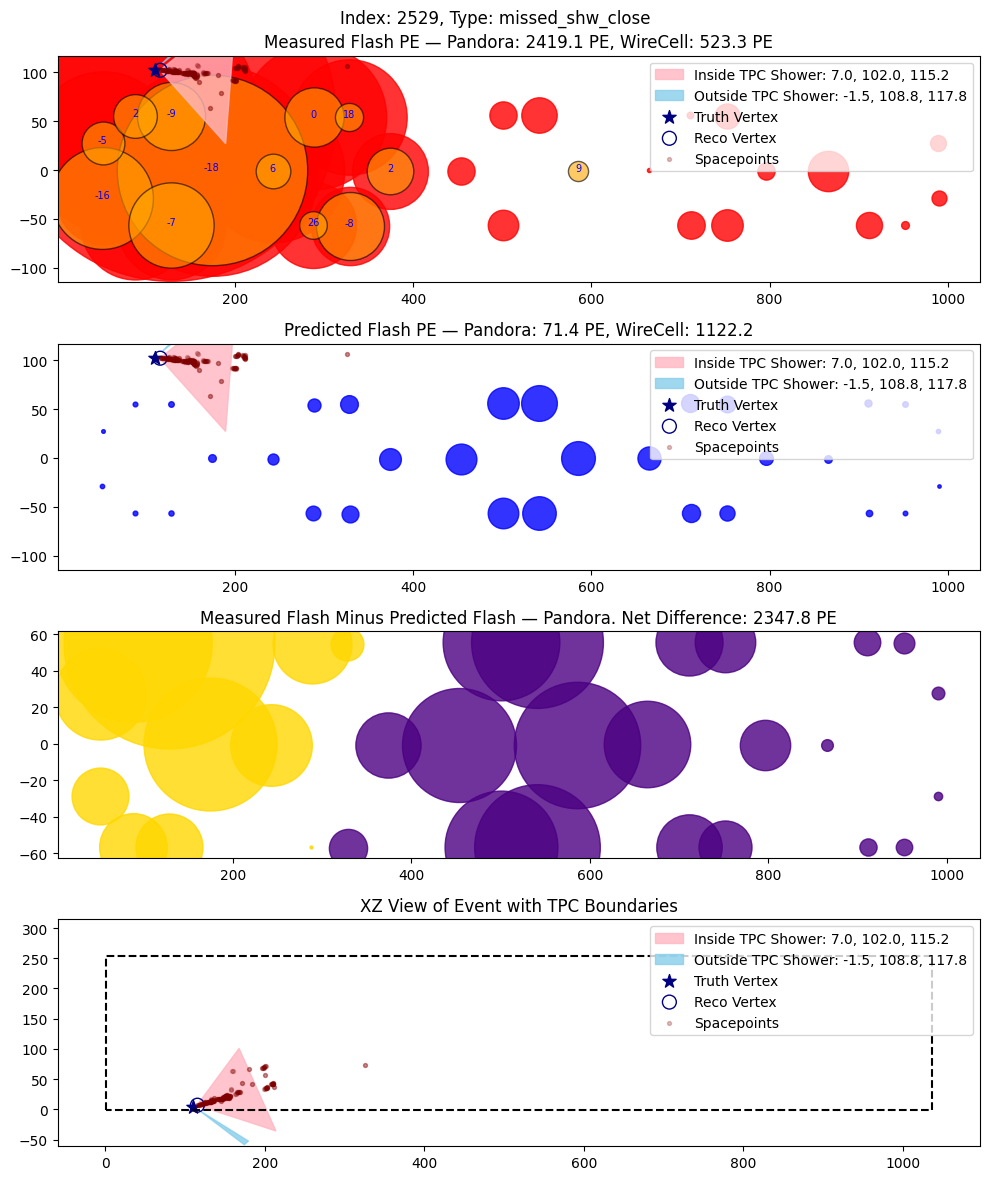

[(np.float32(4000.892), np.int32(13), np.float32(4.7540236), np.False_), (np.float32(4009.352), np.int32(16), np.float32(4.9740176), np.False_), (np.float32(3985.1292), np.int32(19), np.float32(15.261335), np.False_), (np.float32(3988.5872), np.int32(20), np.float32(32.93234), np.False_), (np.float32(4001.0088), np.int32(21), np.float32(7.94219), np.False_), (np.float32(3971.7107), np.int32(22), np.float32(187.82738), np.True_), (np.float32(4001.0754), np.int32(23), np.float32(14.737272), np.False_), (np.float32(3986.971), np.int32(24), np.float32(43.55092), np.False_), (np.float32(3980.4075), np.int32(25), np.float32(77.87339), np.False_), (np.float32(3985.8428), np.int32(26), np.float32(44.816135), np.False_), (np.float32(3963.545), np.int32(27), np.float32(1767.9297), np.True_), (np.float32(3978.2305), np.int32(29), np.float32(120.99777), np.True_), (np.float32(3984.6628), np.int32(30), np.float32(40.854862), np.False_), (np.float32(3982.595), np.int32(31), np.float32(52.35151), np.

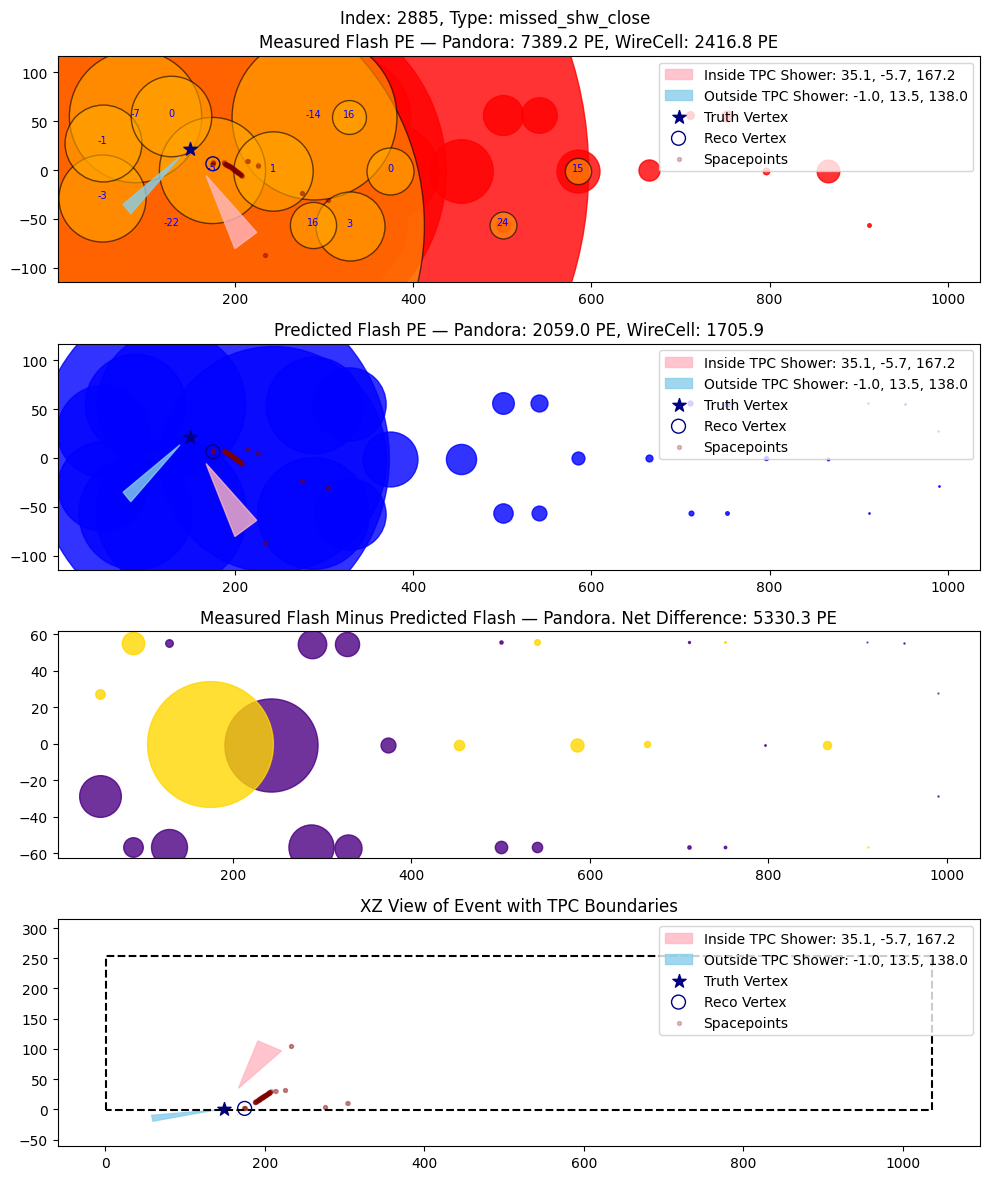

[(np.float32(3311.2888), np.int32(8), np.float32(3.493989), np.False_), (np.float32(3312.574), np.int32(10), np.float32(4.7365956), np.False_), (np.float32(3337.3755), np.int32(11), np.float32(4.1971726), np.False_), (np.float32(3300.1333), np.int32(13), np.float32(26.07579), np.False_), (np.float32(3298.8992), np.int32(14), np.float32(33.476997), np.False_), (np.float32(3307.973), np.int32(15), np.float32(21.446434), np.False_), (np.float32(3293.22), np.int32(16), np.float32(122.16162), np.True_), (np.float32(3292.7722), np.int32(18), np.float32(269.67282), np.True_), (np.float32(3318.8555), np.int32(19), np.float32(4.7395086), np.False_), (np.float32(3304.4731), np.int32(21), np.float32(20.31963), np.False_), (np.float32(3311.2795), np.int32(23), np.float32(10.4157715), np.False_)]


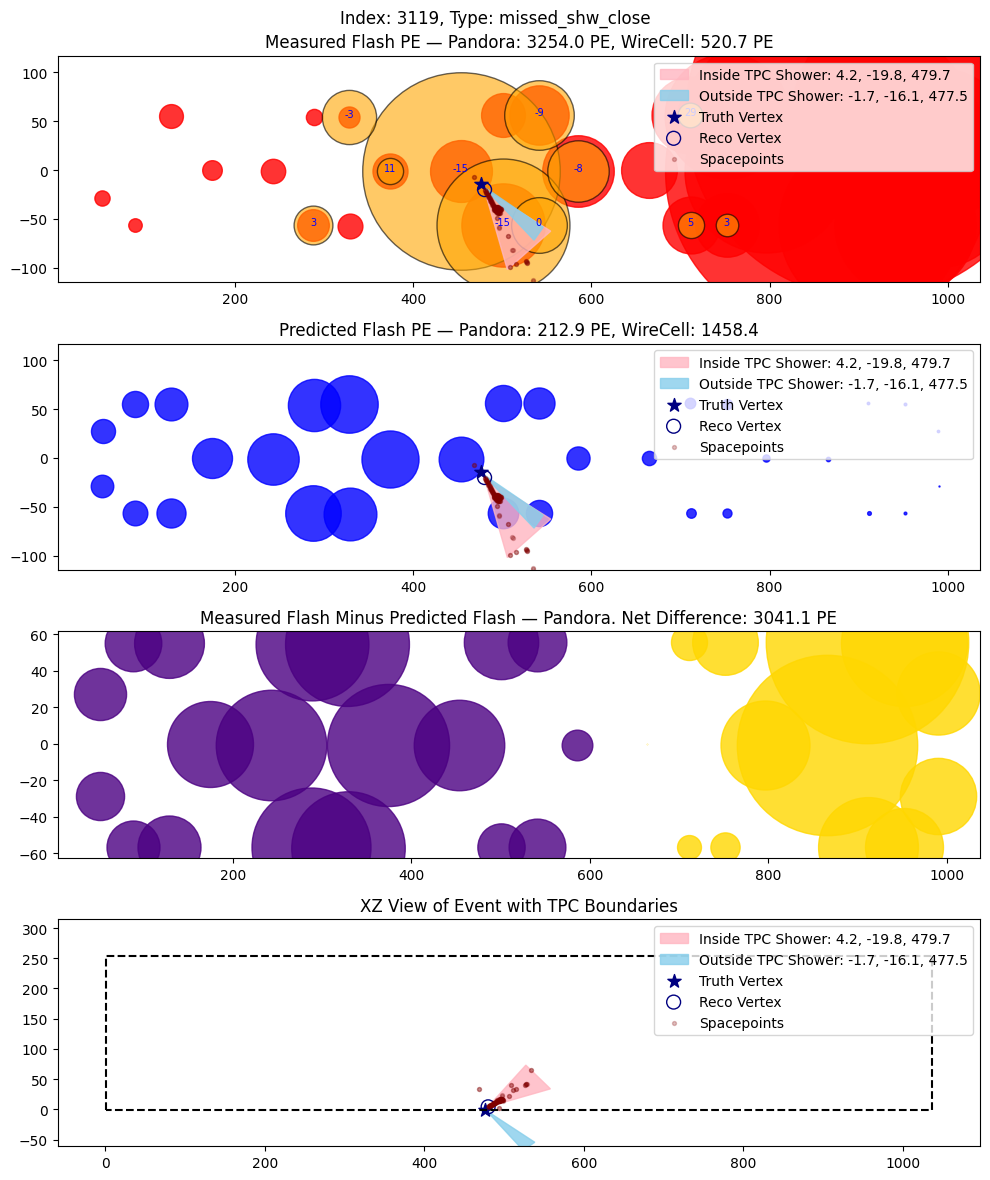

[(np.float32(4779.685), np.int32(20), np.float32(5.3813252), np.False_), (np.float32(4784.319), np.int32(22), np.float32(10.503854), np.False_), (np.float32(4796.77), np.int32(24), np.float32(3.2232199), np.False_), (np.float32(4767.1387), np.int32(25), np.float32(50.00729), np.False_), (np.float32(4764.888), np.int32(26), np.float32(49.308746), np.False_), (np.float32(4784.0645), np.int32(27), np.float32(16.372044), np.False_), (np.float32(4769.563), np.int32(29), np.float32(12.029991), np.False_), (np.float32(4773.0586), np.int32(30), np.float32(14.527937), np.False_), (np.float32(4765.8276), np.int32(31), np.float32(63.230026), np.False_)]


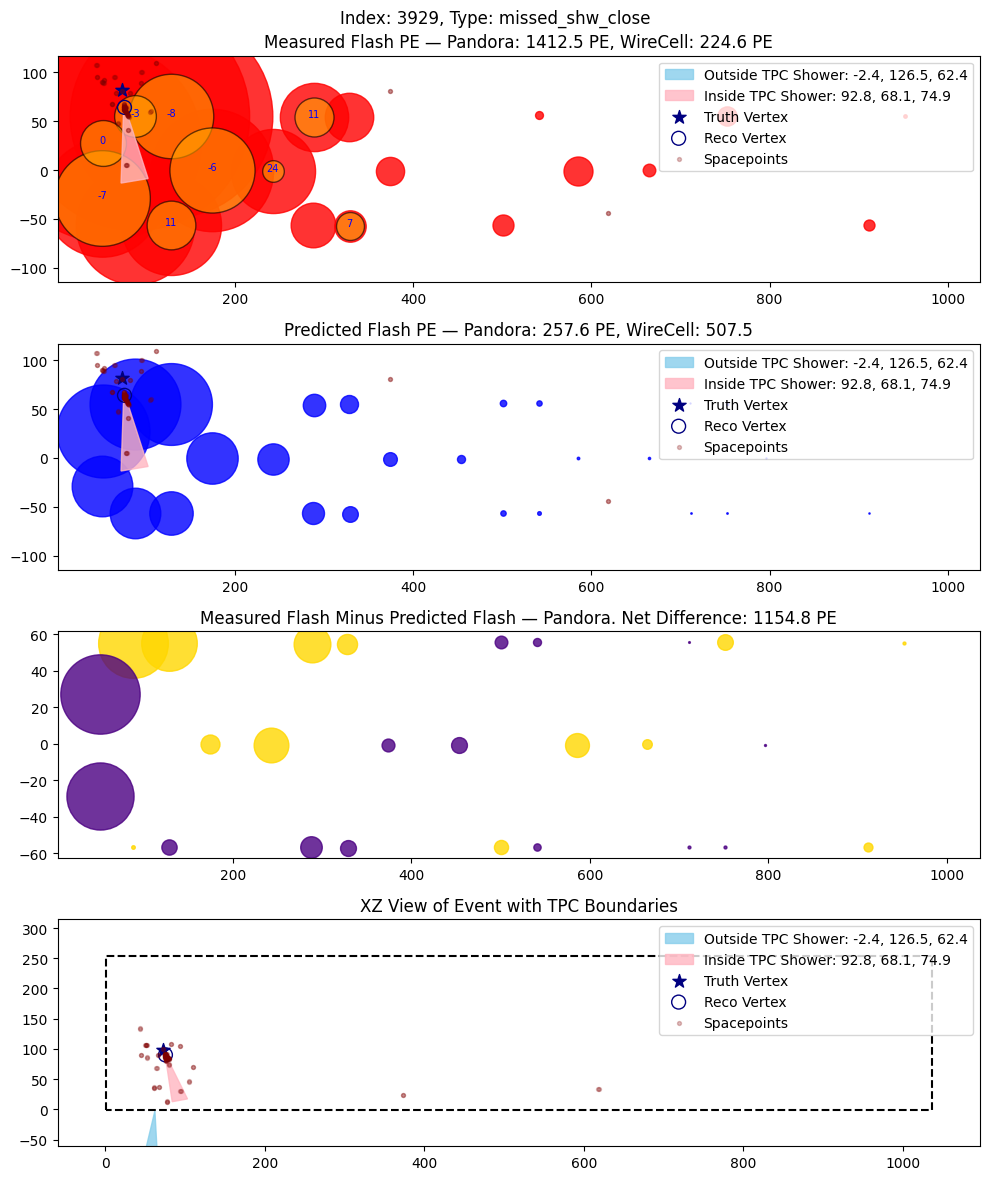

[(np.float32(3876.2913), np.int32(14), np.float32(3.6864197), np.False_), (np.float32(3868.1963), np.int32(16), np.float32(9.090224), np.False_), (np.float32(3873.7273), np.int32(18), np.float32(6.7435102), np.False_), (np.float32(3863.2886), np.int32(19), np.float32(61.65115), np.False_), (np.float32(3858.8164), np.int32(20), np.float32(91.51736), np.False_), (np.float32(3863.6711), np.int32(21), np.float32(47.171745), np.False_), (np.float32(3840.9587), np.int32(22), np.float32(2938.7266), np.True_), (np.float32(3852.3767), np.int32(23), np.float32(154.75894), np.True_), (np.float32(3854.605), np.int32(24), np.float32(340.2354), np.True_), (np.float32(3868.1538), np.int32(25), np.float32(16.296886), np.False_), (np.float32(3869.4724), np.int32(26), np.float32(8.464188), np.False_), (np.float32(3856.85), np.int32(27), np.float32(70.30621), np.False_), (np.float32(3866.0693), np.int32(29), np.float32(26.077879), np.False_), (np.float32(3877.653), np.int32(30), np.float32(9.702525), np.

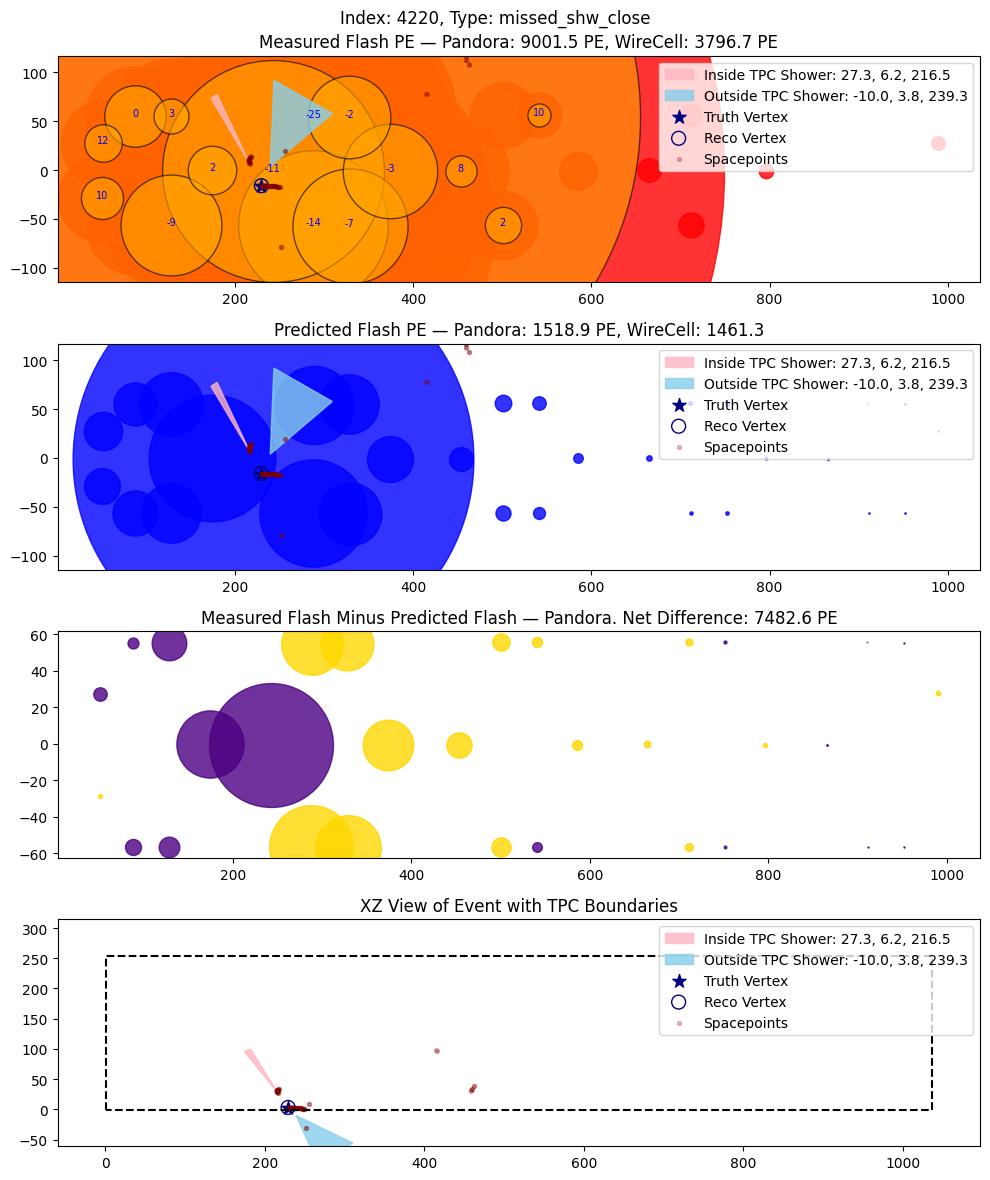

[(np.float32(3523.5073), np.int32(0), np.float32(8.393076), np.False_), (np.float32(3531.0068), np.int32(1), np.float32(12.799019), np.False_), (np.float32(4583.5225), np.int32(2), np.float32(14.687461), np.False_), (np.float32(3532.1235), np.int32(3), np.float32(14.968625), np.False_), (np.float32(3523.1816), np.int32(4), np.float32(38.77733), np.False_), (np.float32(3511.3823), np.int32(5), np.float32(110.38242), np.True_), (np.float32(3511.8452), np.int32(6), np.float32(87.986626), np.False_), (np.float32(3594.422), np.int32(7), np.float32(2.6008315), np.False_), (np.float32(3530.3542), np.int32(9), np.float32(3.5981195), np.False_)]


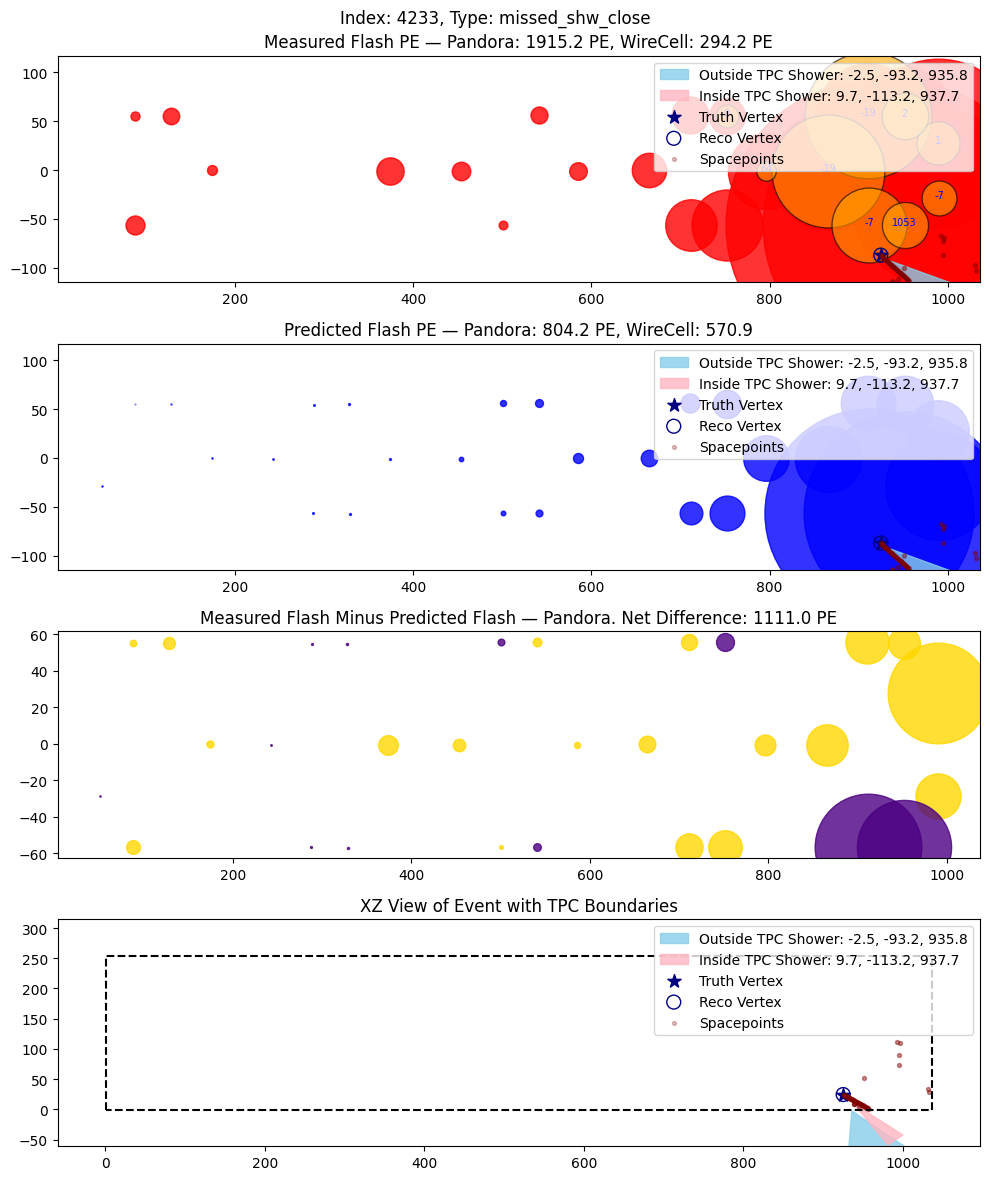

[(np.float32(3850.1948), np.int32(20), np.float32(3.29149), np.False_), (np.float32(3851.347), np.int32(22), np.float32(9.793735), np.False_), (np.float32(3867.7942), np.int32(23), np.float32(3.3030975), np.False_), (np.float32(3867.674), np.int32(24), np.float32(3.515686), np.False_), (np.float32(3838.675), np.int32(25), np.float32(35.66744), np.False_), (np.float32(3829.6553), np.int32(26), np.float32(126.30094), np.True_), (np.float32(3838.669), np.int32(27), np.float32(45.105938), np.False_), (np.float32(3833.8804), np.int32(29), np.float32(82.03133), np.False_), (np.float32(3825.8677), np.int32(30), np.float32(137.7004), np.True_), (np.float32(3834.1636), np.int32(31), np.float32(72.040146), np.False_)]


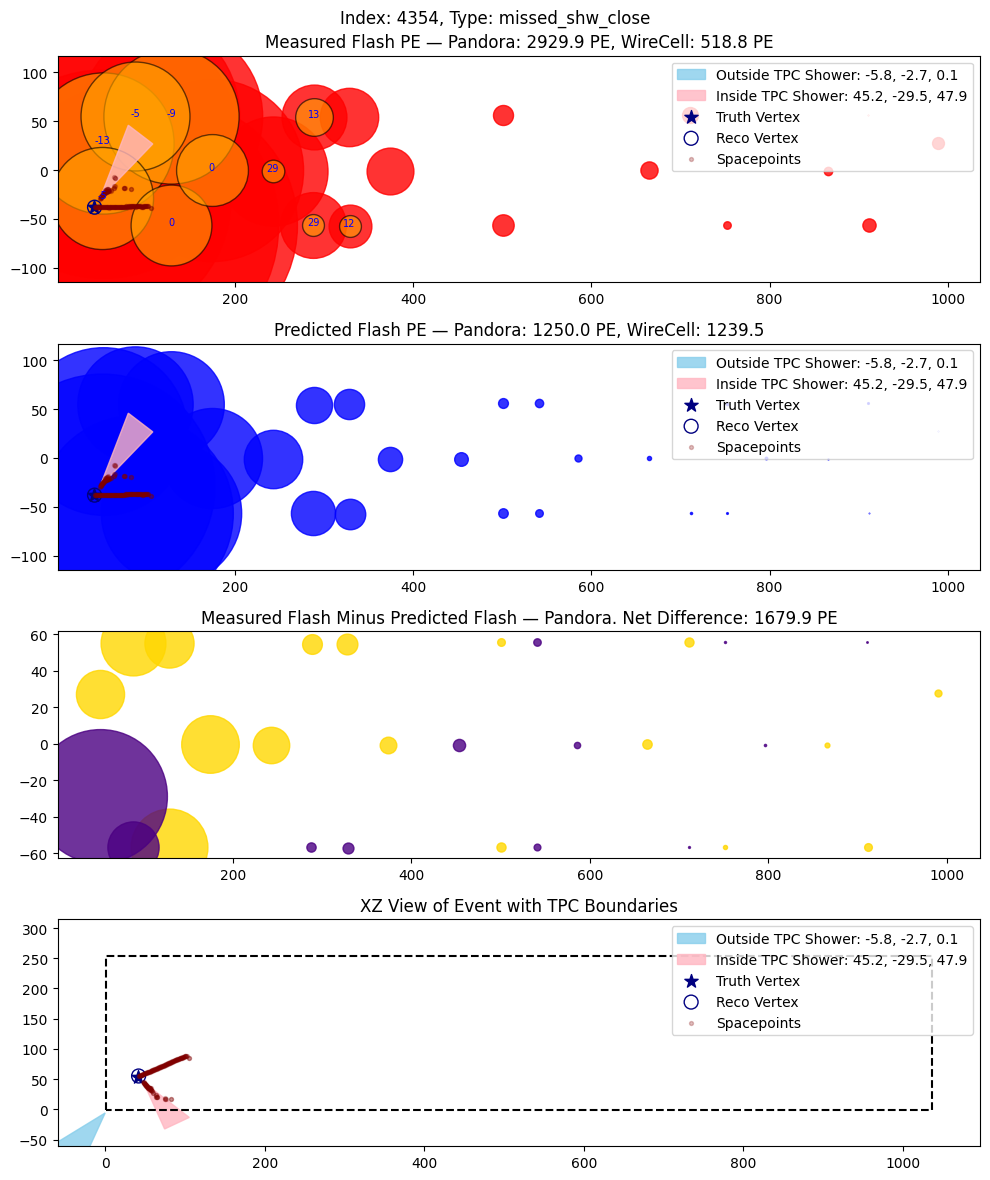

[(np.float32(3342.48), np.int32(7), np.float32(3.9456956), np.False_), (np.float32(3338.6558), np.int32(8), np.float32(4.806348), np.False_), (np.float32(3340.3655), np.int32(10), np.float32(8.846013), np.False_), (np.float32(3348.9136), np.int32(11), np.float32(2.5534997), np.False_), (np.float32(3342.72), np.int32(12), np.float32(5.649851), np.False_), (np.float32(3323.7175), np.int32(13), np.float32(69.35211), np.False_), (np.float32(3324.1335), np.int32(14), np.float32(103.90869), np.True_), (np.float32(3326.7278), np.int32(15), np.float32(49.822147), np.False_), (np.float32(3314.929), np.int32(16), np.float32(161.31026), np.True_), (np.float32(3314.7898), np.int32(18), np.float32(163.83505), np.True_), (np.float32(3344.585), np.int32(19), np.float32(7.747398), np.False_), (np.float32(3334.807), np.int32(20), np.float32(8.499785), np.False_), (np.float32(3324.4243), np.int32(21), np.float32(29.75057), np.False_), (np.float32(3341.043), np.int32(22), np.float32(3.2411916), np.False_

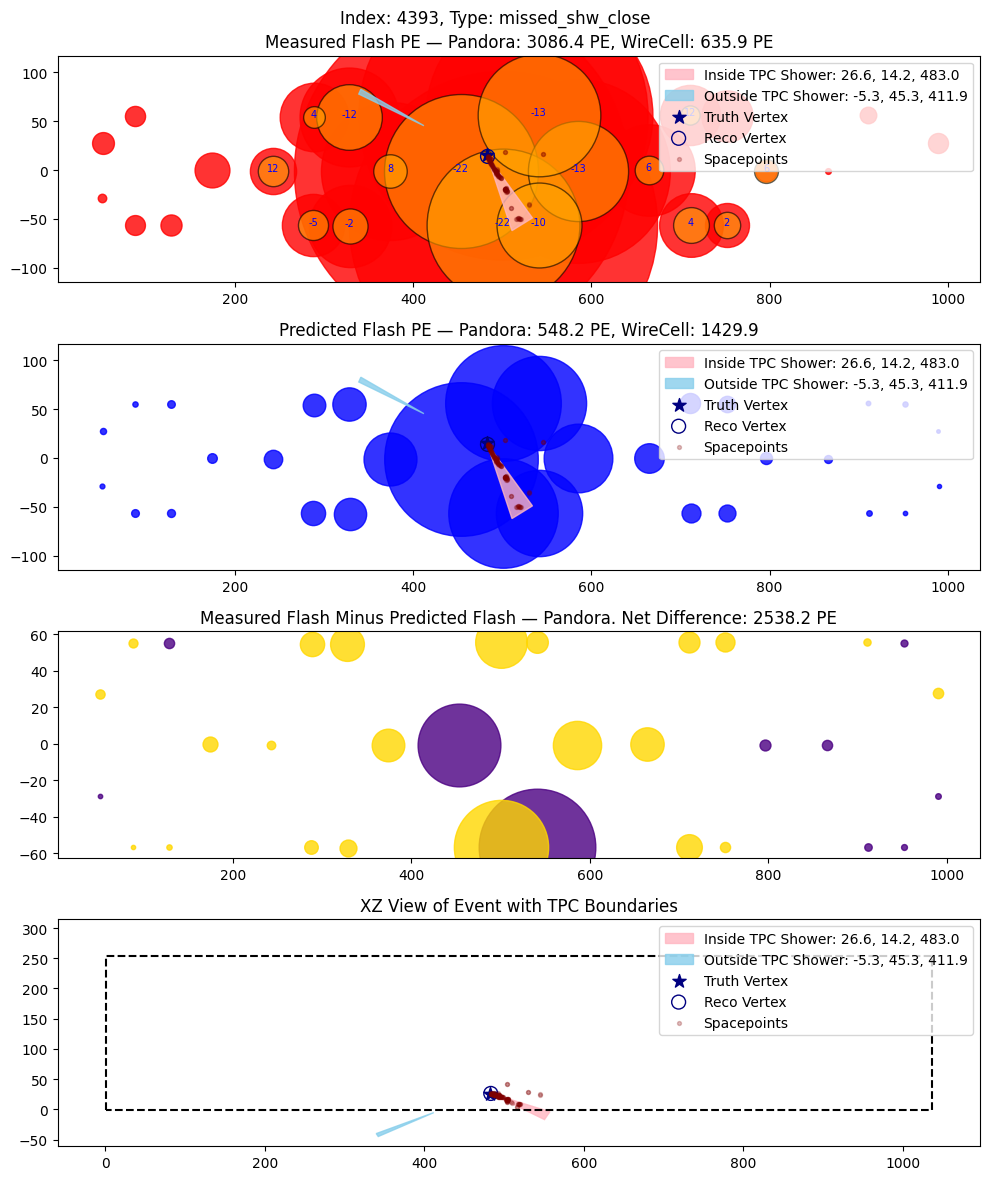

[(np.float32(3526.153), np.int32(13), np.float32(2.7566617), np.False_), (np.float32(3522.795), np.int32(14), np.float32(8.411274), np.False_), (np.float32(3523.6357), np.int32(15), np.float32(6.055825), np.False_), (np.float32(3521.7336), np.int32(16), np.float32(35.92796), np.False_), (np.float32(3523.2783), np.int32(18), np.float32(19.452278), np.False_), (np.float32(3516.948), np.int32(19), np.float32(27.316208), np.False_), (np.float32(3526.8704), np.int32(20), np.float32(13.861988), np.False_), (np.float32(3508.7017), np.int32(21), np.float32(260.22156), np.True_), (np.float32(3518.5334), np.int32(22), np.float32(19.32362), np.False_), (np.float32(3509.1716), np.int32(23), np.float32(95.95099), np.False_), (np.float32(3515.3757), np.int32(24), np.float32(38.130146), np.False_), (np.float32(3538.6917), np.int32(25), np.float32(2.5689561), np.False_), (np.float32(3528.2893), np.int32(27), np.float32(3.6270392), np.False_)]


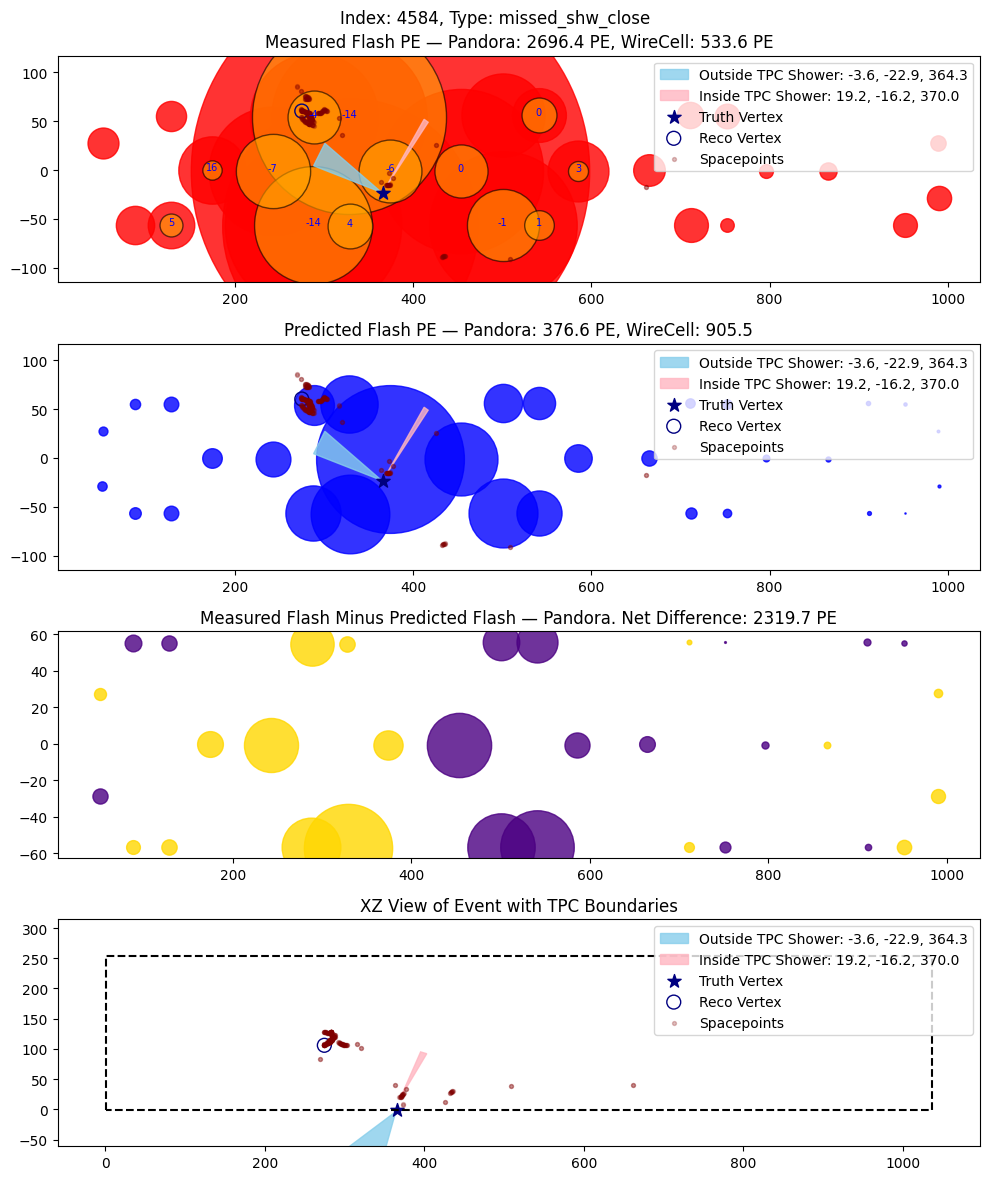

[(np.float32(4026.9492), np.int32(10), np.float32(4.6220856), np.False_), (np.float32(4127.2783), np.int32(12), np.float32(2.771519), np.False_), (np.float32(4017.2437), np.int32(13), np.float32(20.408466), np.False_), (np.float32(4012.3665), np.int32(14), np.float32(43.114395), np.False_), (np.float32(4019.7258), np.int32(15), np.float32(13.704087), np.False_), (np.float32(3999.879), np.int32(16), np.float32(81.727486), np.False_), (np.float32(4007.6177), np.int32(18), np.float32(21.24628), np.False_), (np.float32(4002.1013), np.int32(19), np.float32(53.58852), np.False_), (np.float32(4010.2065), np.int32(20), np.float32(22.171091), np.False_), (np.float32(3991.0842), np.int32(21), np.float32(266.07825), np.True_), (np.float32(4037.366), np.int32(22), np.float32(8.982395), np.False_), (np.float32(4006.0386), np.int32(23), np.float32(24.811508), np.False_), (np.float32(4015.3657), np.int32(24), np.float32(9.104507), np.False_)]


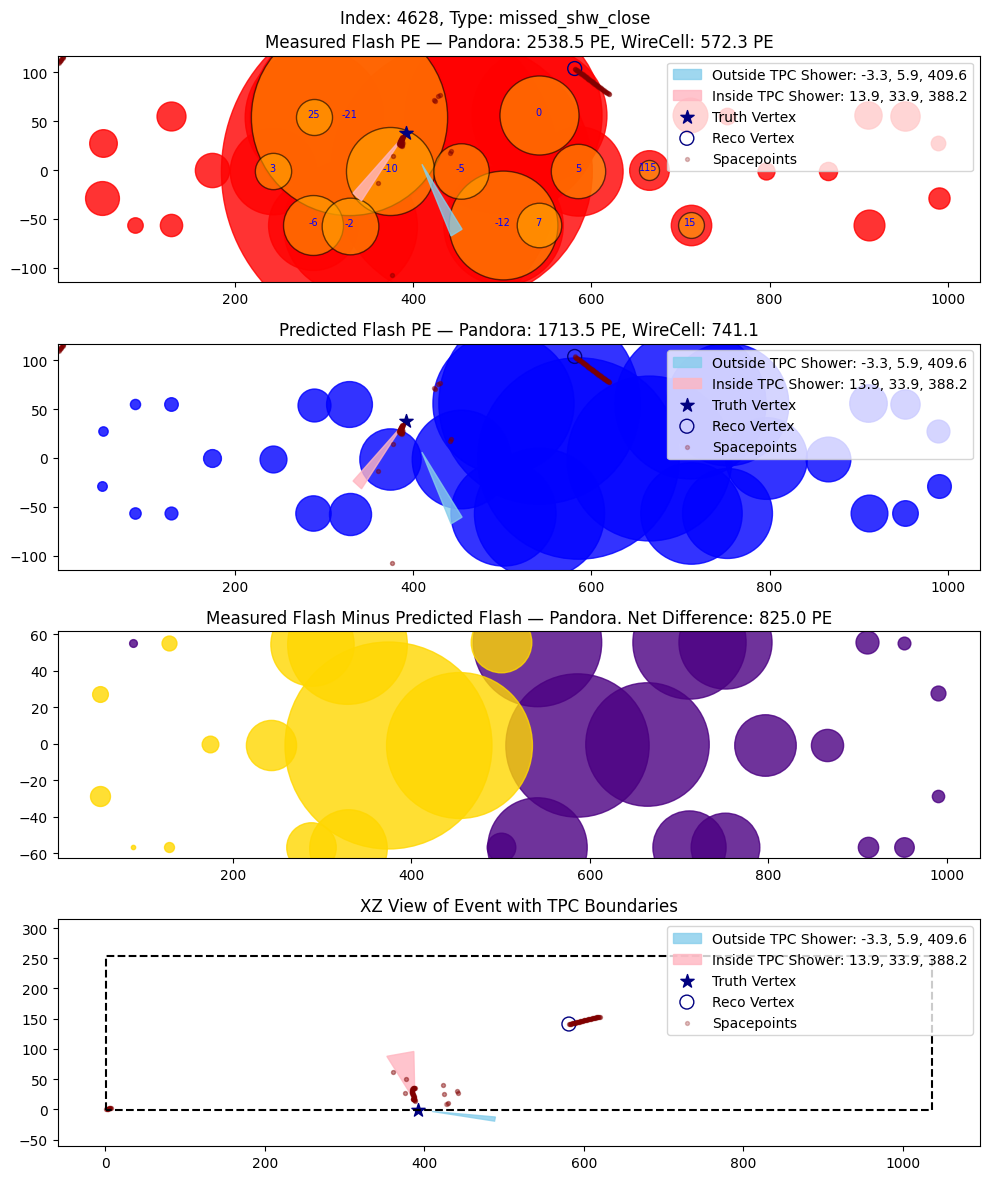

[(np.float32(4118.805), np.int32(0), np.float32(11.212757), np.False_), (np.float32(4112.567), np.int32(1), np.float32(27.59138), np.False_), (np.float32(4124.181), np.int32(2), np.float32(6.3764043), np.False_), (np.float32(4099.78), np.int32(3), np.float32(164.7499), np.True_), (np.float32(4113.3613), np.int32(4), np.float32(13.0622635), np.False_), (np.float32(4113.279), np.int32(5), np.float32(19.168545), np.False_), (np.float32(4108.3423), np.int32(6), np.float32(26.92767), np.False_), (np.float32(4100.545), np.int32(7), np.float32(158.14742), np.True_), (np.float32(4098.621), np.int32(8), np.float32(124.76584), np.True_), (np.float32(4095.7698), np.int32(9), np.float32(801.8712), np.True_), (np.float32(4099.132), np.int32(10), np.float32(80.70987), np.False_), (np.float32(4089.132), np.int32(11), np.float32(282.23987), np.True_), (np.float32(4095.6196), np.int32(12), np.float32(177.79922), np.True_), (np.float32(4118.2305), np.int32(13), np.float32(11.548919), np.False_), (np.flo

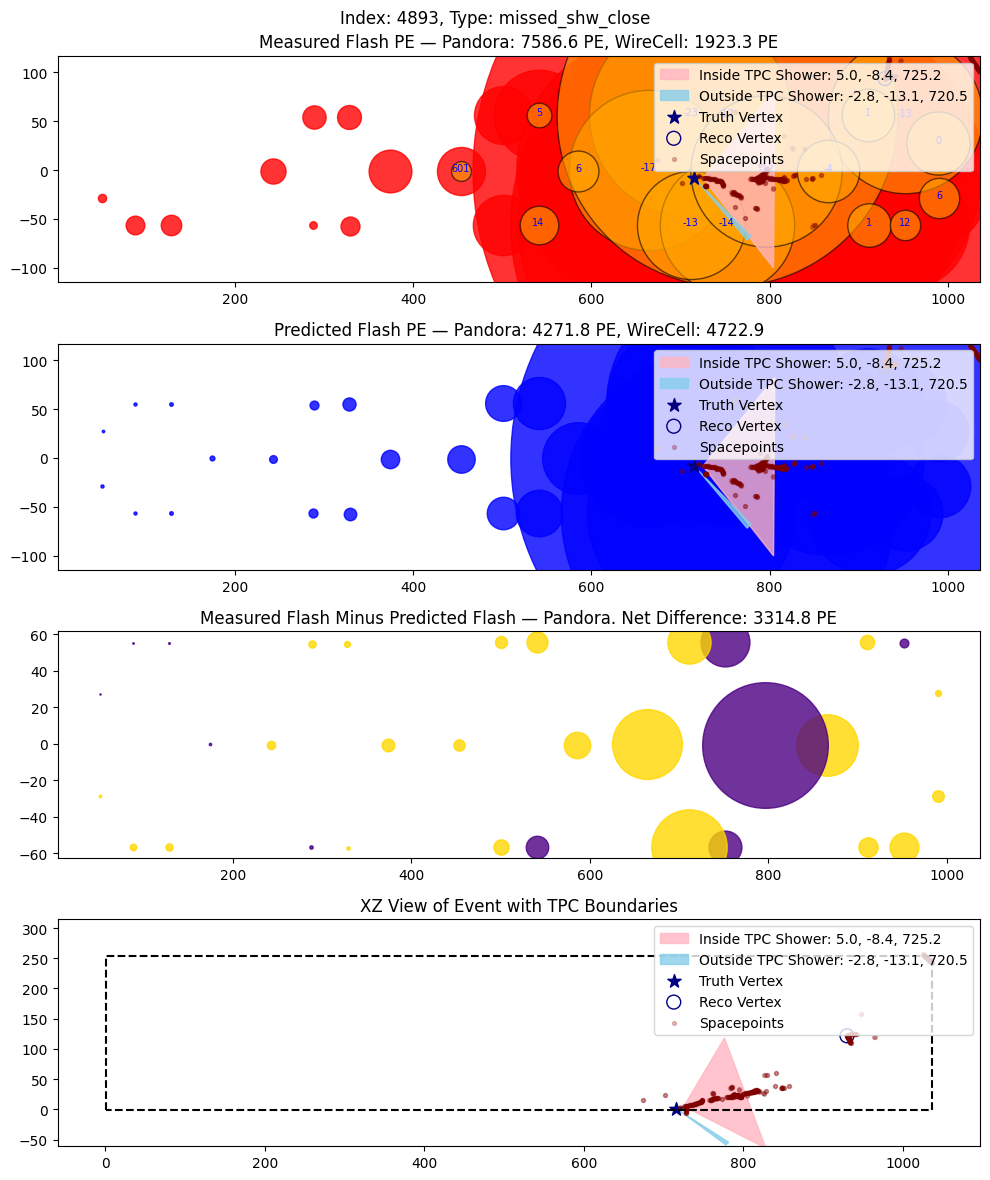

[(np.float32(3811.4587), np.int32(7), np.float32(3.025929), np.False_), (np.float32(3781.1086), np.int32(10), np.float32(5.7868767), np.False_), (np.float32(4360.88), np.int32(11), np.float32(2.7604163), np.False_), (np.float32(3756.0103), np.int32(13), np.float32(234.9739), np.True_), (np.float32(3761.2256), np.int32(14), np.float32(292.2251), np.True_), (np.float32(3781.7832), np.int32(15), np.float32(19.410168), np.False_), (np.float32(3765.3818), np.int32(16), np.float32(54.674763), np.False_), (np.float32(3771.0042), np.int32(18), np.float32(13.034813), np.False_), (np.float32(3762.4338), np.int32(19), np.float32(61.146523), np.False_), (np.float32(3773.123), np.int32(20), np.float32(20.898514), np.False_), (np.float32(3762.3557), np.int32(21), np.float32(82.48344), np.False_), (np.float32(3772.8523), np.int32(22), np.float32(15.493693), np.False_), (np.float32(3778.6726), np.int32(23), np.float32(13.391674), np.False_), (np.float32(3775.4956), np.int32(24), np.float32(16.196436),

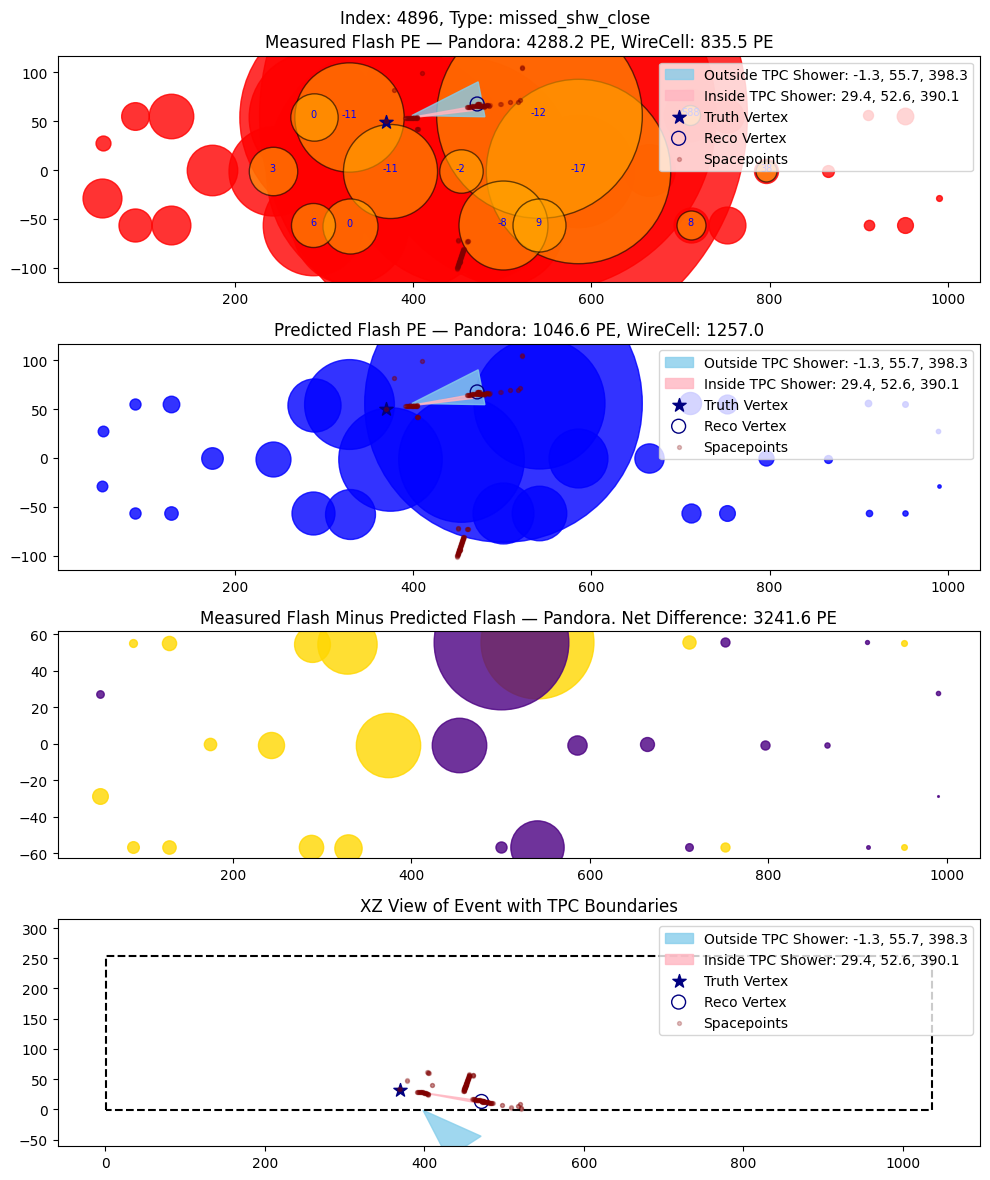

[(np.float32(4445.9033), np.int32(0), np.float32(4.419247), np.False_), (np.float32(4464.8267), np.int32(1), np.float32(5.3404555), np.False_), (np.float32(4441.735), np.int32(2), np.float32(2.747191), np.False_), (np.float32(4438.7285), np.int32(3), np.float32(11.459299), np.False_), (np.float32(4444.027), np.int32(4), np.float32(5.1680865), np.False_), (np.float32(4439.4834), np.int32(5), np.float32(10.546549), np.False_), (np.float32(4438.8203), np.int32(6), np.float32(25.633127), np.False_), (np.float32(4452.882), np.int32(7), np.float32(7.3537803), np.False_), (np.float32(4818.4893), np.int32(8), np.float32(4.066851), np.False_), (np.float32(4444.467), np.int32(9), np.float32(18.59642), np.False_), (np.float32(4446.7495), np.int32(10), np.float32(4.630657), np.False_), (np.float32(4433.5957), np.int32(11), np.float32(28.32108), np.False_), (np.float32(4445.314), np.int32(12), np.float32(6.872833), np.False_)]


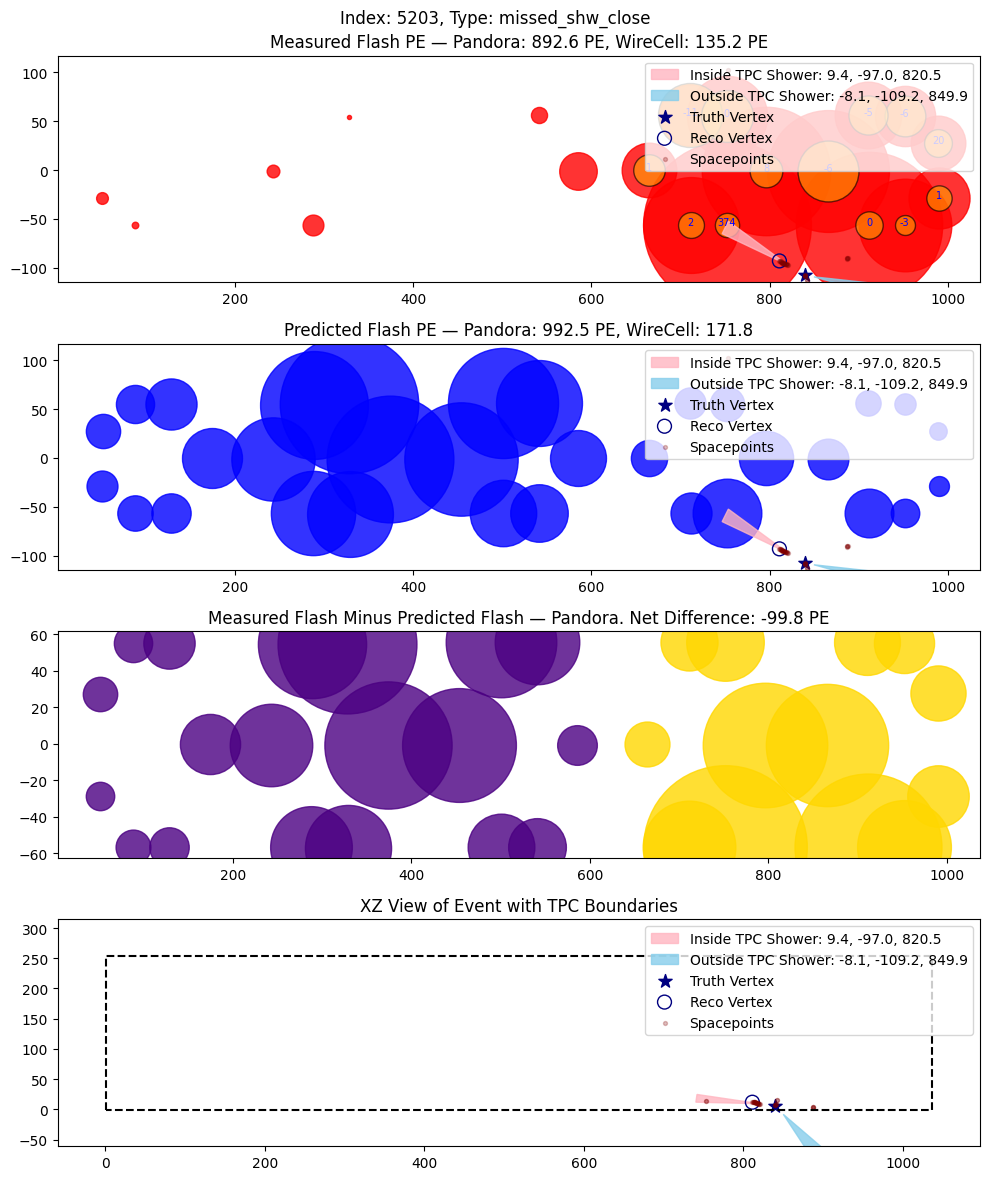

[(np.float32(4383.911), np.int32(10), np.float32(4.2606673), np.False_), (np.float32(4368.901), np.int32(13), np.float32(9.598736), np.False_), (np.float32(4375.985), np.int32(14), np.float32(30.763447), np.False_), (np.float32(4383.5107), np.int32(15), np.float32(7.794814), np.False_), (np.float32(4366.0664), np.int32(16), np.float32(71.99081), np.False_), (np.float32(4368.96), np.int32(18), np.float32(37.12301), np.False_), (np.float32(4365.025), np.int32(19), np.float32(59.577614), np.False_), (np.float32(4368.5317), np.int32(20), np.float32(25.554268), np.False_), (np.float32(4353.5107), np.int32(21), np.float32(345.49826), np.True_), (np.float32(4372.245), np.int32(22), np.float32(8.920253), np.False_), (np.float32(4367.363), np.int32(23), np.float32(43.985996), np.False_), (np.float32(4374.8228), np.int32(24), np.float32(21.122314), np.False_), (np.float32(4376.4863), np.int32(27), np.float32(5.4152503), np.False_), (np.float32(4378.398), np.int32(29), np.float32(4.920677), np.Fa

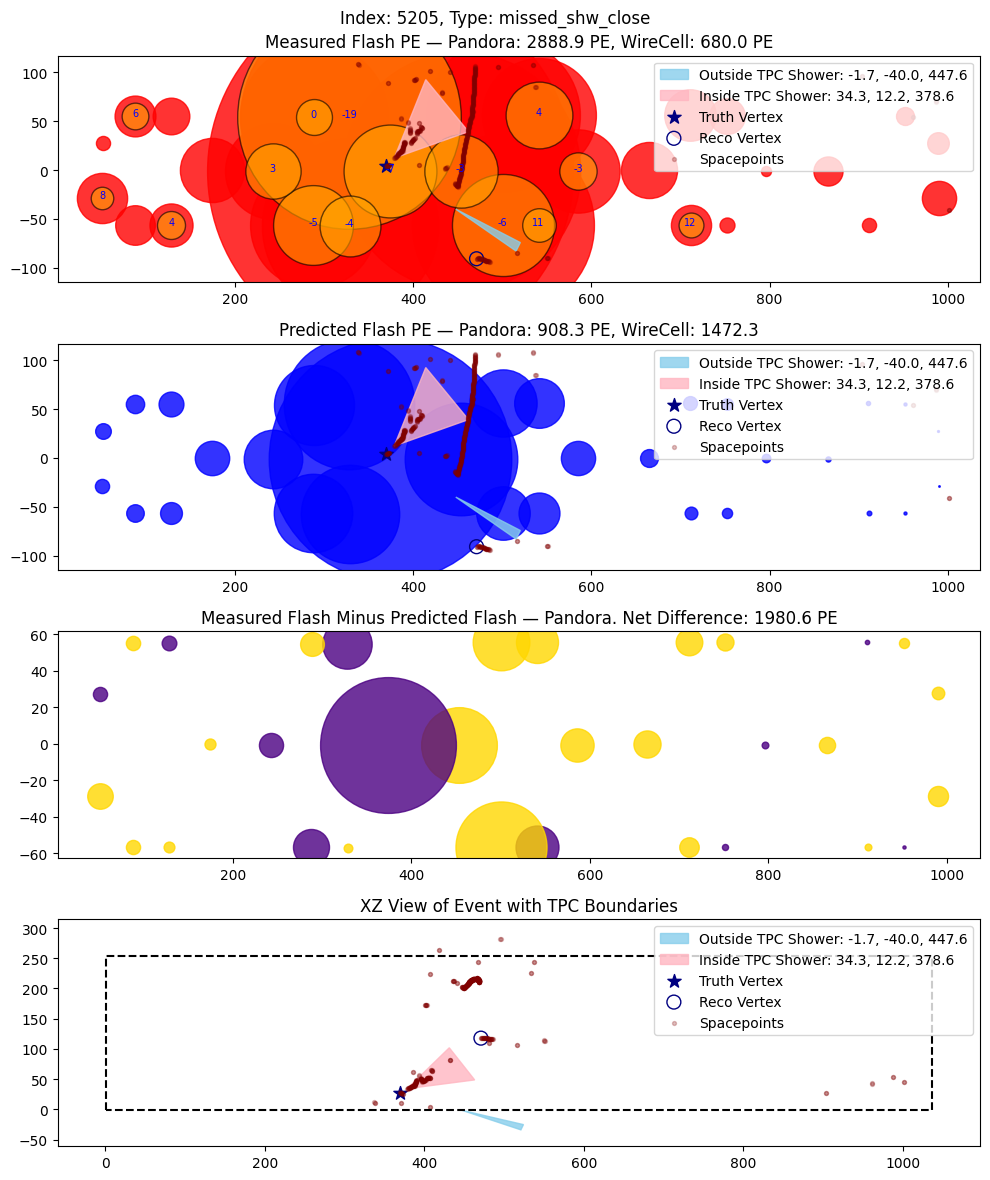

[(np.float32(3754.6724), np.int32(0), np.float32(235.3779), np.True_), (np.float32(3752.6108), np.int32(1), np.float32(181.03091), np.True_), (np.float32(3741.3655), np.int32(2), np.float32(960.089), np.True_), (np.float32(3754.535), np.int32(3), np.float32(256.2806), np.True_), (np.float32(3746.103), np.int32(4), np.float32(3305.5757), np.True_), (np.float32(3744.3533), np.int32(5), np.float32(2084.6125), np.True_), (np.float32(3743.6838), np.int32(6), np.float32(1217.1111), np.True_), (np.float32(3770.0095), np.int32(7), np.float32(20.391624), np.False_), (np.float32(3779.981), np.int32(8), np.float32(8.947943), np.False_), (np.float32(3760.6113), np.int32(9), np.float32(50.4371), np.False_), (np.float32(3901.7625), np.int32(10), np.float32(3.7811818), np.False_), (np.float32(3767.4912), np.int32(11), np.float32(24.38604), np.False_), (np.float32(3771.5652), np.int32(12), np.float32(9.25854), np.False_), (np.float32(3792.5535), np.int32(15), np.float32(3.4012911), np.False_)]


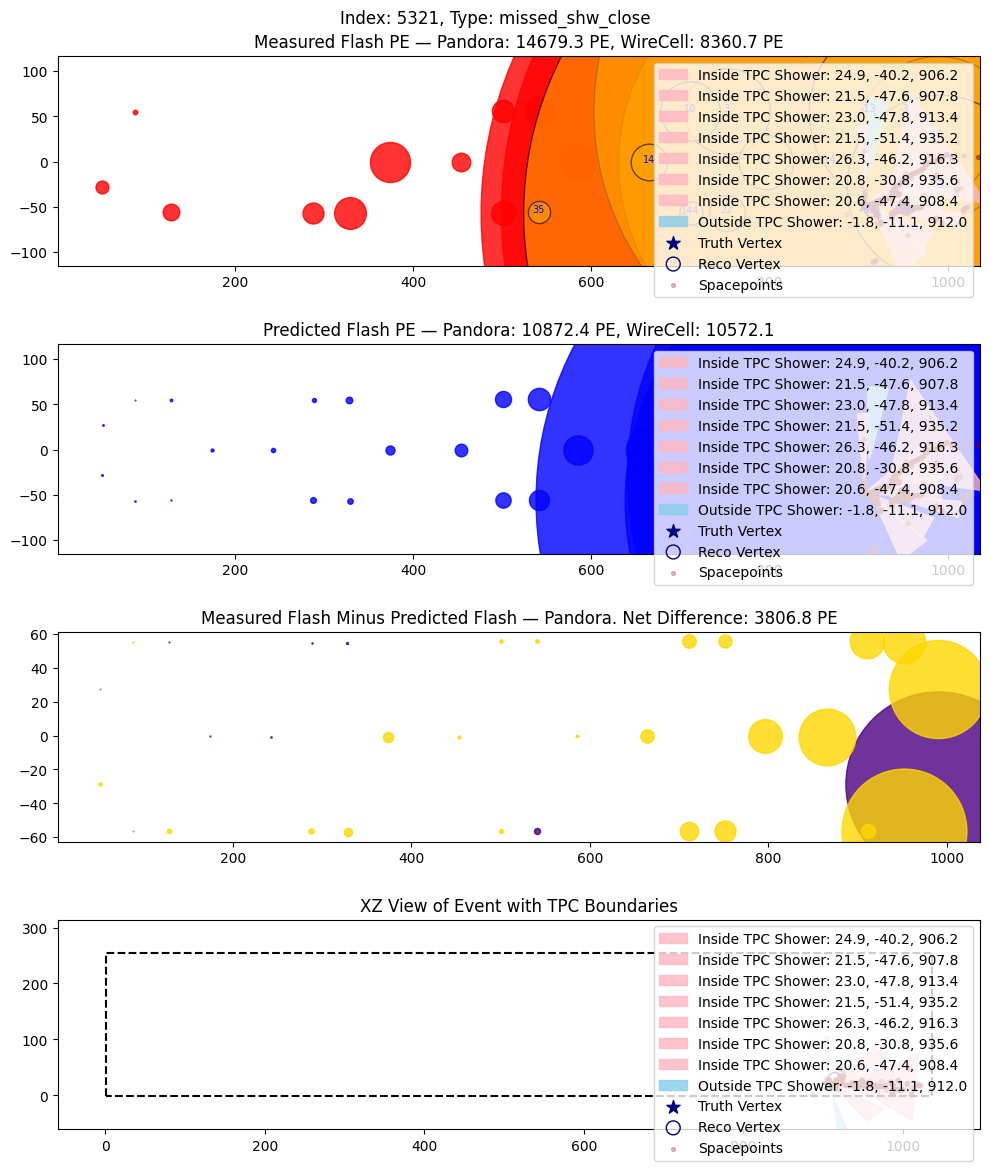

[(np.float32(4234.3394), np.int32(0), np.float32(5.991978), np.False_), (np.float32(4240.9), np.int32(1), np.float32(6.9037204), np.False_), (np.float32(4238.015), np.int32(2), np.float32(14.8561), np.False_), (np.float32(4239.9546), np.int32(3), np.float32(15.805627), np.False_), (np.float32(4232.2144), np.int32(4), np.float32(57.560635), np.False_), (np.float32(4228.9478), np.int32(5), np.float32(155.76283), np.True_), (np.float32(4218.3022), np.int32(6), np.float32(597.7749), np.True_), (np.float32(4246.539), np.int32(9), np.float32(7.0922413), np.False_), (np.float32(4248.783), np.int32(11), np.float32(3.429911), np.False_)]


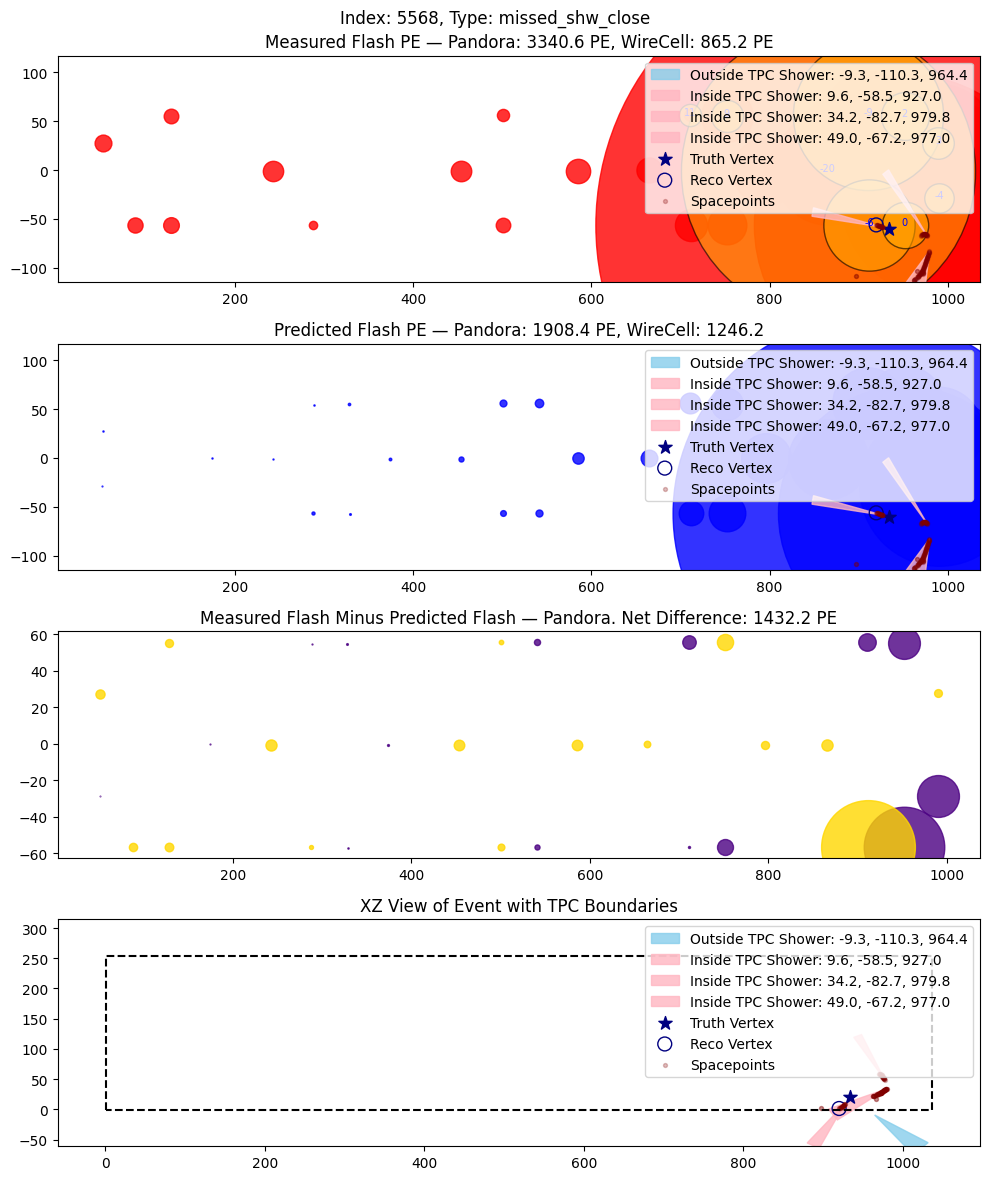

[(np.float32(3378.1501), np.int32(19), np.float32(8.40019), np.False_), (np.float32(3374.28), np.int32(20), np.float32(9.144193), np.False_), (np.float32(3383.5225), np.int32(21), np.float32(3.5964897), np.False_), (np.float32(3373.245), np.int32(22), np.float32(27.1421), np.False_), (np.float32(3411.5483), np.int32(23), np.float32(4.0925336), np.False_), (np.float32(3380.8782), np.int32(24), np.float32(13.594421), np.False_), (np.float32(3359.9807), np.int32(25), np.float32(475.9622), np.True_), (np.float32(3369.294), np.int32(26), np.float32(46.08424), np.False_), (np.float32(3371.0525), np.int32(27), np.float32(77.061424), np.False_), (np.float32(3369.4102), np.int32(29), np.float32(32.272366), np.False_), (np.float32(3374.9265), np.int32(30), np.float32(30.67313), np.False_), (np.float32(3364.084), np.int32(31), np.float32(225.36981), np.True_)]


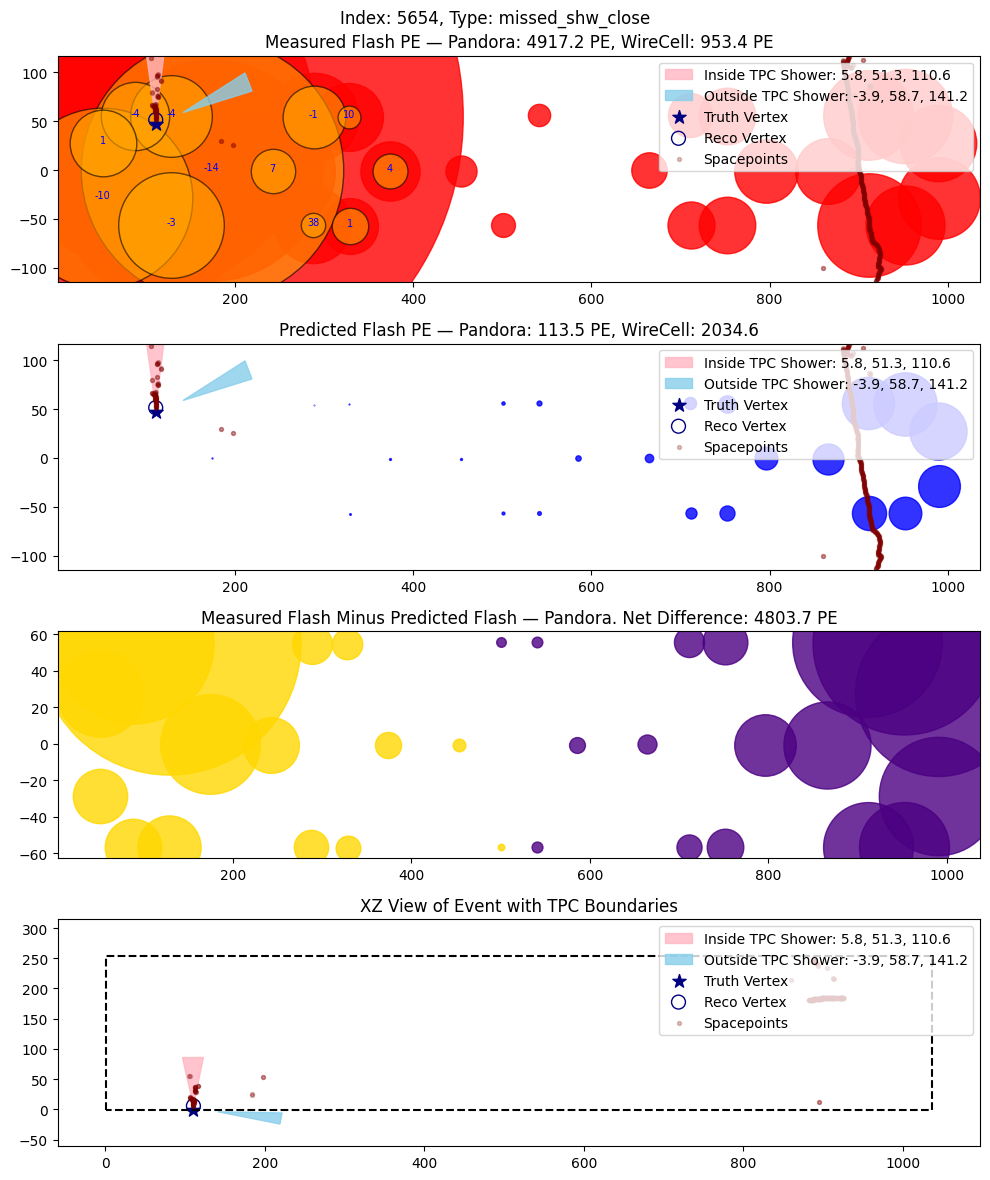

In [201]:
missed_shower_df = all_df.query('one_outside_tpc and one_inside_tpc')
missed_shower_indices = missed_shower_df.index.tolist()

# indices of close to pmts missed shower
close_to_missed_pmt_df = all_df.query("missed_shw_close_to_pmt and pi0_flag")
close_to_missed_pmt_indices = close_to_missed_pmt_df.index.tolist()
#print(len(close_to_missed_pmt_df))

# indices of high energy second showers
high_energy_second_shower_df = all_df.query('missed_photon_e > 0.05')
high_energy_second_shower_indices = high_energy_second_shower_df.index.tolist()
#print(len(high_energy_second_shower_indices))

# both
high_e_close_df = all_df.query('missed_shw_close_to_pmt and missed_photon_e > 0.05')
high_e_close_indices = high_e_close_df.index.tolist()
#print(len(high_e_close_df))

missed_shw_far_from_inside_df = all_df.query('missed_shw_distance > 30')
missed_shower_indices = missed_shw_far_from_inside_df.index.tolist()
#print(len(missed_shower_indices))

for event_id in close_to_missed_pmt_indices[:30]:
    make_event_display(event_id, "missed_shw_close")

#for event_id in high_energy_second_shower_indices[:30]:
#    make_event_display(event_id, "high_e_shw")

# do 100 missed shower events
#for event_id in missed_shower_indices[:100]:
#    make_event_display(event_id, "missed_shw")

all_df['missed_shw_distance'] = missed_shw_distance

missed_shw_far_from_inside_df = all_df.query('missed_shw_distance > 100')
missed_shower_far_indices = missed_shw_far_from_inside_df.index.tolist()

#for event_id in missed_shower_far_indices:
#    make_event_display(event_id, "missed_shw_far")


    

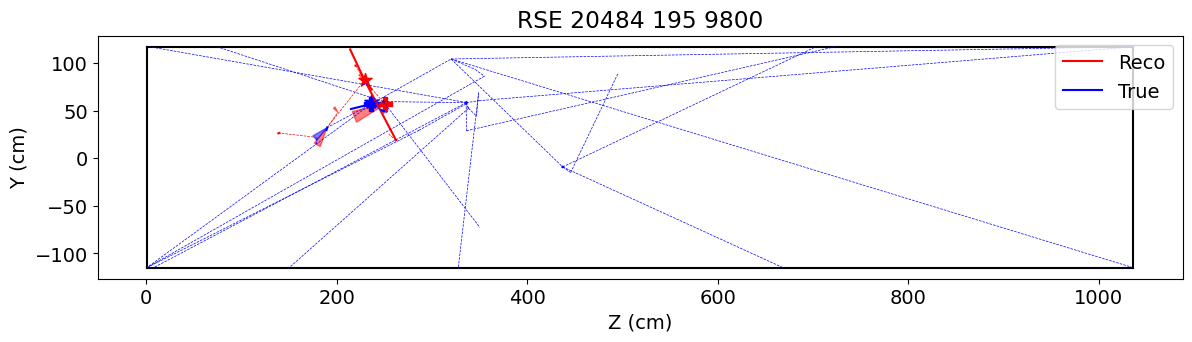

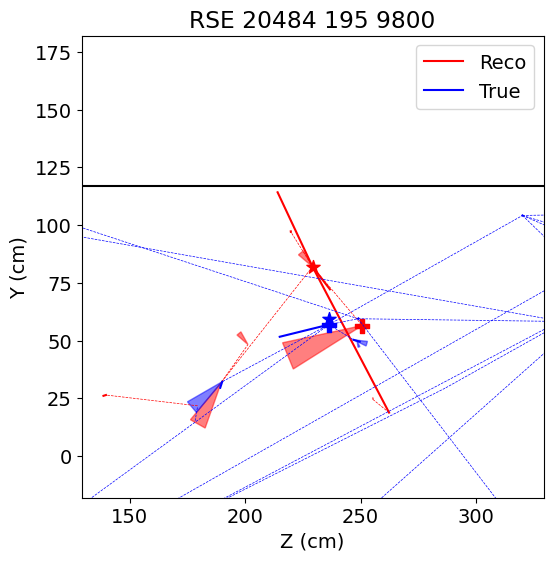

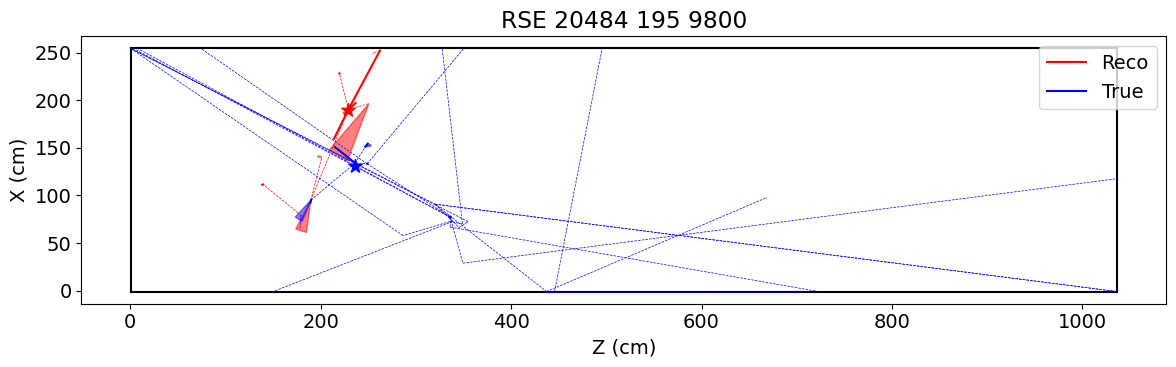

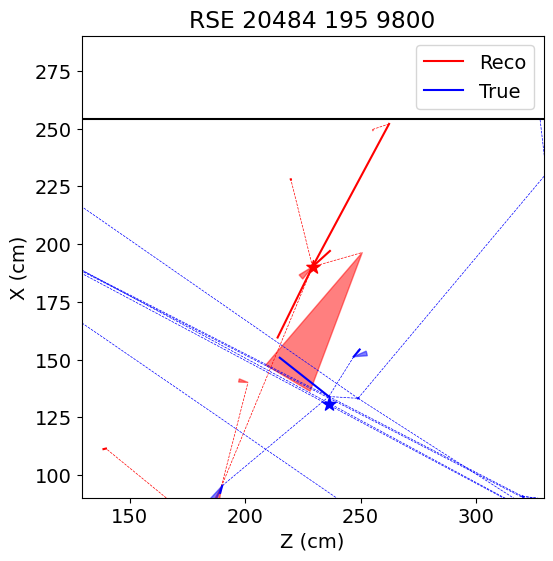

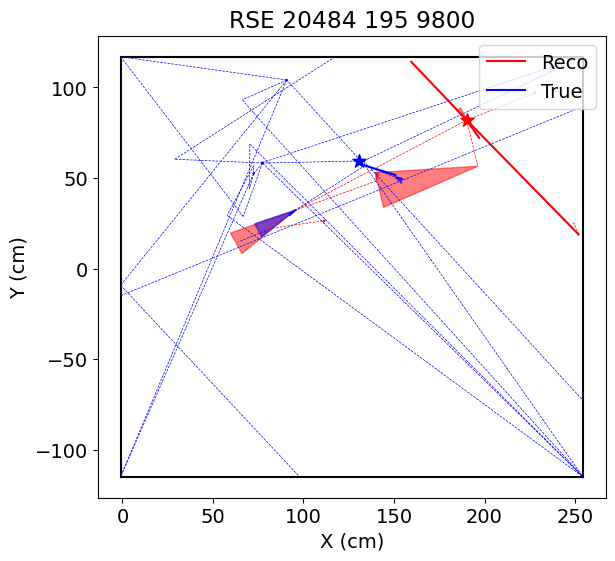

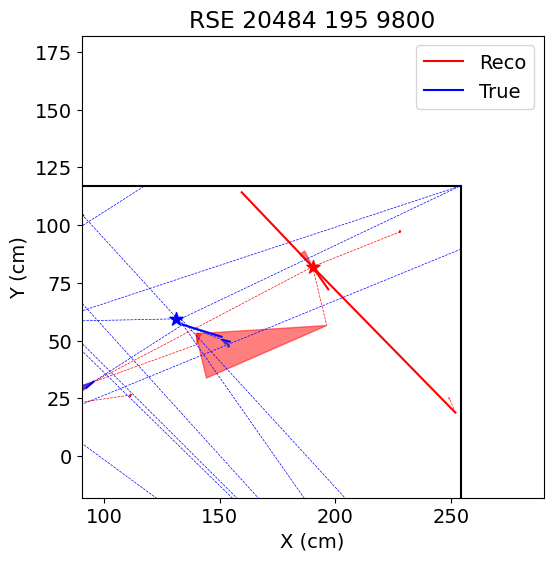

In [202]:
# full event displays

def show_simplified_event_display(df, event_idx, view="zy", index=0, zoomed=False):

    event_df = df.iloc[event_idx]
    
    run = event_df["run"]
    subrun = event_df["subrun"]
    event = event_df["event"]

    reco_ids = event_df["reco_id"]
    reco_pdgs = event_df["reco_pdg"]
    reco_start_XYZTs = event_df["reco_startXYZT"]
    reco_end_XYZTs = event_df["reco_endXYZT"]

    truth_ids = event_df["truth_id"]
    truth_pdgs = event_df["truth_pdg"]
    truth_start_XYZTs = event_df["truth_startXYZT"]
    truth_end_XYZTs = event_df["truth_endXYZT"]
    truth_mother = event_df["truth_mother"]

    tpc_min_x, tpc_max_x = -1., 254.3
    tpc_min_y, tpc_max_y = -115., 117.
    tpc_min_z, tpc_max_z = 0.6, 1036.4

    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(14, 6))

    if view == "zy":
        plt.plot([tpc_min_z, tpc_max_z], [tpc_min_y, tpc_min_y], c="k")
        plt.plot([tpc_min_z, tpc_max_z], [tpc_max_y, tpc_max_y], c="k")
        plt.plot([tpc_min_z, tpc_min_z], [tpc_min_y, tpc_max_y], c="k")
        plt.plot([tpc_max_z, tpc_max_z], [tpc_min_y, tpc_max_y], c="k")
    elif view == "zx":
        plt.plot([tpc_min_z, tpc_max_z], [tpc_min_x, tpc_min_x], c="k")
        plt.plot([tpc_min_z, tpc_max_z], [tpc_max_x, tpc_max_x], c="k")
        plt.plot([tpc_min_z, tpc_min_z], [tpc_min_x, tpc_max_x], c="k")
        plt.plot([tpc_max_z, tpc_max_z], [tpc_min_x, tpc_max_x], c="k")
    elif view == "xy":
        plt.plot([tpc_min_x, tpc_max_x], [tpc_min_y, tpc_min_y], c="k")
        plt.plot([tpc_min_x, tpc_max_x], [tpc_max_y, tpc_max_y], c="k")
        plt.plot([tpc_min_x, tpc_min_x], [tpc_min_y, tpc_max_y], c="k")
        plt.plot([tpc_max_x, tpc_max_x], [tpc_min_y, tpc_max_y], c="k")

    plt.plot([], [], c="r", label="Reco")
    plt.plot([], [], c="b", label="True")

    for j in range(len(reco_pdgs)):
        start = np.array(reco_start_XYZTs[j])
        end = np.array(reco_end_XYZTs[j])
        if view == "zy":
            start, end = start[[2, 1]], end[[2, 1]]
        elif view == "zx":
            start, end = start[[2, 0]], end[[2, 0]]
        elif view == "xy":
            start, end = start[[0, 1]], end[[0, 1]]

        pdg = reco_pdgs[j]
        charge = Particle.from_pdgid(pdg).charge if pdg in Particle.all() else None
        if charge == 0:
            plt.plot([start[0], end[0]], [start[1], end[1]], c="r", linestyle="--", lw=0.5)
        elif pdg == 11:
            direction = end - start
            length = np.linalg.norm(direction)
            if length == 0:
                continue
            unit = direction / length
            perp = np.array([-unit[1], unit[0]])
            angle_rad = np.radians(10)
            side_len = length * np.tan(angle_rad)
            side1 = end - side_len * perp
            side2 = end + side_len * perp
            triangle = np.array([start, side1, end, side2])
            plt.fill(triangle[:, 0], triangle[:, 1], color="r", alpha=0.5)
        else:
            plt.plot([start[0], end[0]], [start[1], end[1]], c="r")

    for j in range(len(truth_pdgs)):
        start = np.clip(truth_start_XYZTs[j], [tpc_min_x, tpc_min_y, tpc_min_z, -np.inf], [tpc_max_x, tpc_max_y, tpc_max_z, np.inf])
        end = np.clip(truth_end_XYZTs[j], [tpc_min_x, tpc_min_y, tpc_min_z, -np.inf], [tpc_max_x, tpc_max_y, tpc_max_z, np.inf])
        if view == "zy":
            start, end = start[[2, 1]], end[[2, 1]]
        elif view == "zx":
            start, end = start[[2, 0]], end[[2, 0]]
        elif view == "xy":
            start, end = start[[0, 1]], end[[0, 1]]

        pdg = truth_pdgs[j]
        if Particle.from_pdgid(pdg).charge == 0:
            plt.plot([start[0], end[0]], [start[1], end[1]], c="b", linestyle="--", lw=0.5)
        elif pdg == 11:
            direction = end - start
            length = np.linalg.norm(direction)
            if length == 0:
                continue
            unit = direction / length
            perp = np.array([-unit[1], unit[0]])
            angle_rad = np.radians(10)
            side_len = length * np.tan(angle_rad)
            side1 = end - side_len * perp
            side2 = end + side_len * perp
            triangle = np.array([start, side1, end, side2])
            plt.fill(triangle[:, 0], triangle[:, 1], color="b", alpha=0.5)
        else:
            plt.plot([start[0], end[0]], [start[1], end[1]], c="b")

    # Plotting vertices
    if view == "zy":
        plt.scatter(event_df["reco_nuvtxZ"], event_df["reco_nuvtxY"], color="r", marker="*", s=100)
        plt.scatter(event_df["truth_vtxZ"], event_df["truth_vtxY"], color="b", marker="*", s=100)
        plt.scatter(event_df["reco_showervtxZ"], event_df["reco_showervtxY"], color="r", marker="P", s=100)
        plt.scatter(event_df["truth_corr_showervtxZ"], event_df["truth_corr_showervtxY"], color="b", marker="P", s=100)
    elif view == "zx":
        plt.scatter(event_df["reco_nuvtxZ"], event_df["reco_nuvtxX"], color="r", marker="*", s=100)
        plt.scatter(event_df["truth_vtxZ"], event_df["truth_vtxX"], color="b", marker="*", s=100)
    elif view == "xy":
        plt.scatter(event_df["reco_nuvtxX"], event_df["reco_nuvtxY"], color="r", marker="*", s=100)
        plt.scatter(event_df["truth_vtxX"], event_df["truth_vtxY"], color="b", marker="*", s=100)
        
    plt.title(f"RSE {run} {subrun} {event}")
    plt.legend(loc="upper right")

    if view == "zy":
        plt.xlabel("Z (cm)")
        plt.ylabel("Y (cm)")
    elif view == "zx":
        plt.xlabel("Z (cm)")
        plt.ylabel("X (cm)")
    elif view == "xy":
        plt.xlabel("X (cm)")
        plt.ylabel("Y (cm)")

    if zoomed:
        if view == "zy":
            center_z = event_df["reco_nuvtxZ"]
            center_y = event_df["reco_nuvtxY"]
            plt.xlim(center_z - 100, center_z + 100)
            plt.ylim(center_y - 100, center_y + 100)
        elif view == "zx":
            center_z = event_df["reco_nuvtxZ"]
            center_x = event_df["reco_nuvtxX"]
            plt.xlim(center_z - 100, center_z + 100)
            plt.ylim(center_x - 100, center_x + 100)
        elif view == "xy":
            center_x = event_df["reco_nuvtxX"]
            center_y = event_df["reco_nuvtxY"]
            plt.xlim(center_x - 100, center_x + 100)
            plt.ylim(center_y - 100, center_y + 100)

    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

def go(i):
    show_simplified_event_display(wc_df, i, view="zy", index=i, zoomed=False)
    show_simplified_event_display(wc_df, i, view="zy", index=i, zoomed=True)
    show_simplified_event_display(all_df, i, view="zx", index=i, zoomed=False)
    show_simplified_event_display(all_df, i, view="zx", index=i, zoomed=True)

    show_simplified_event_display(all_df, i, view="xy", index=i, zoomed=False)
    show_simplified_event_display(all_df, i, view="xy", index=i, zoomed=True)

go(12345)

## Spacepoints exploration

In [203]:
print(f['wcpselection']['T_spacepoints'].keys())

rechargeblob_y = f["wcpselection"]["T_spacepoints"]["Trecchargeblob_spacepoints_y"].arrays(library="np")["Trecchargeblob_spacepoints_y"]
rechargeblob_z = f["wcpselection"]["T_spacepoints"]["Trecchargeblob_spacepoints_z"].arrays(library="np")["Trecchargeblob_spacepoints_z"]

rechargeblob_q = f["wcpselection"]["T_spacepoints"]["Trecchargeblob_spacepoints_q"].arrays(library="np")["Trecchargeblob_spacepoints_q"]
#rechargeblob_z = f["wcpselection"]["T_spacepoints"]["Trec_spacepoints_z"].arrays(library="np")["Trec_spacepoints_z"]

i = 10243

print(rechargeblob_z[i].shape)
print(rechargeblob_zs[i].shape)
print(rechargeblob_q[i].shape)

plt.figure(figsize=(8, 6))
plt.scatter(rechargeblob_zs[i], rechargeblob_ys[i], s=10, alpha=0.7)

plt.xlabel('rechargeblob_z')
plt.ylabel('rechargeblob_y')
plt.title('Scatter Plot of rechargeblob_y vs rechargeblob_z')
plt.grid(True)
plt.tight_layout()
plt.show()




['Trec_spacepoints_x', 'Trec_spacepoints_y', 'Trec_spacepoints_z', 'Trec_spacepoints_q', 'Trec_spacepoints_cluster_id', 'Trec_spacepoints_real_cluster_id', 'Trec_spacepoints_sub_cluster_id', 'Treccharge_spacepoints_x', 'Treccharge_spacepoints_y', 'Treccharge_spacepoints_z', 'Treccharge_spacepoints_q', 'Treccharge_spacepoints_cluster_id', 'Treccharge_spacepoints_real_cluster_id', 'Treccharge_spacepoints_sub_cluster_id', 'Trecchargeblob_spacepoints_x', 'Trecchargeblob_spacepoints_y', 'Trecchargeblob_spacepoints_z', 'Trecchargeblob_spacepoints_q', 'Trecchargeblob_spacepoints_cluster_id', 'Trecchargeblob_spacepoints_real_cluster_id', 'Trecchargeblob_spacepoints_sub_cluster_id']
(186,)


NameError: name 'rechargeblob_zs' is not defined

mother of mother: [111]
mother of mother: [111]


/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_64574/1079049869.py:81: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if mother2_pdg == 111:


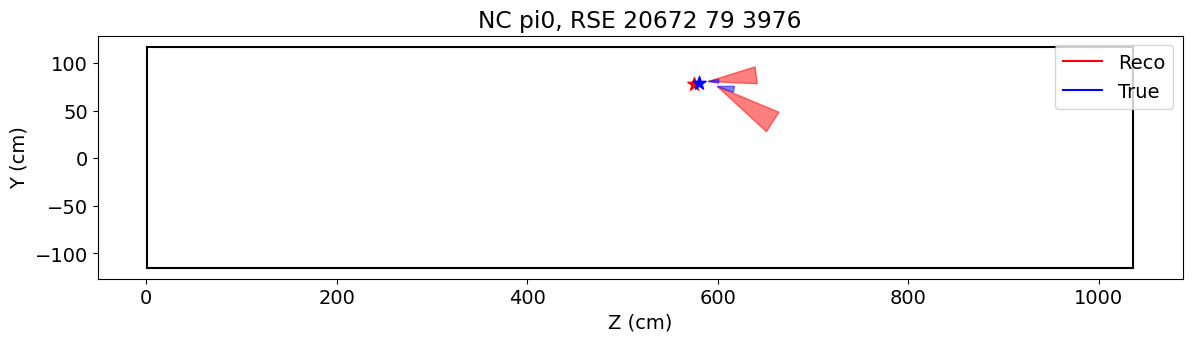

mother of mother: [111]
mother of mother: [111]


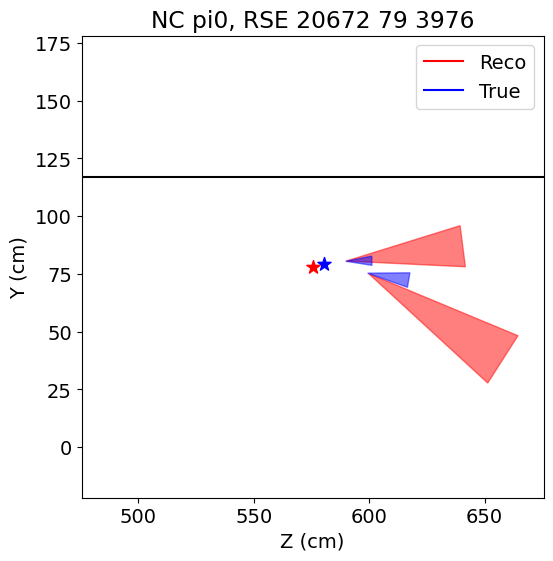

mother of mother: [111]
mother of mother: [111]


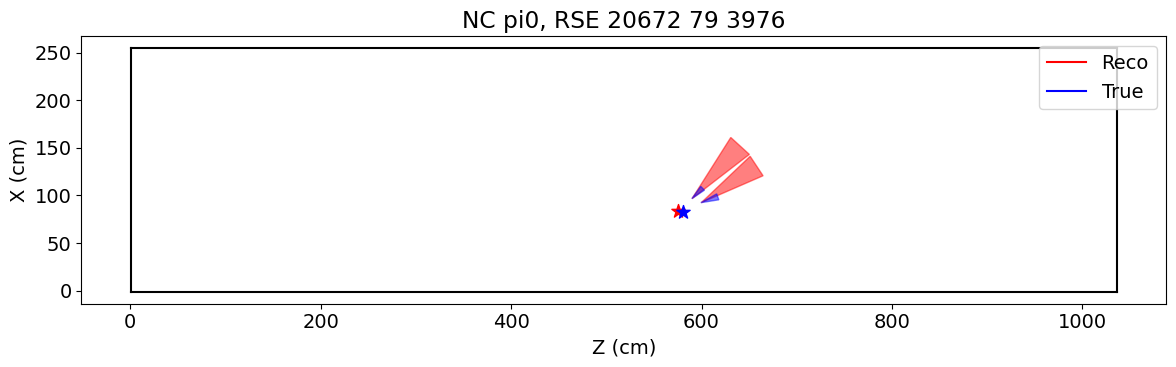

mother of mother: [111]
mother of mother: [111]


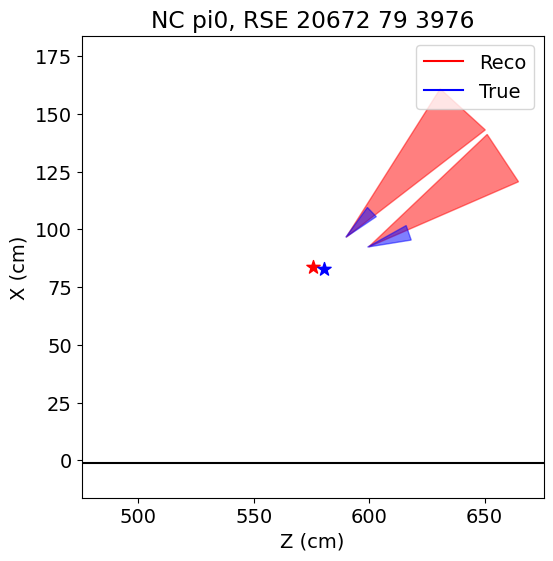

mother of mother: [111]
mother of mother: [111]


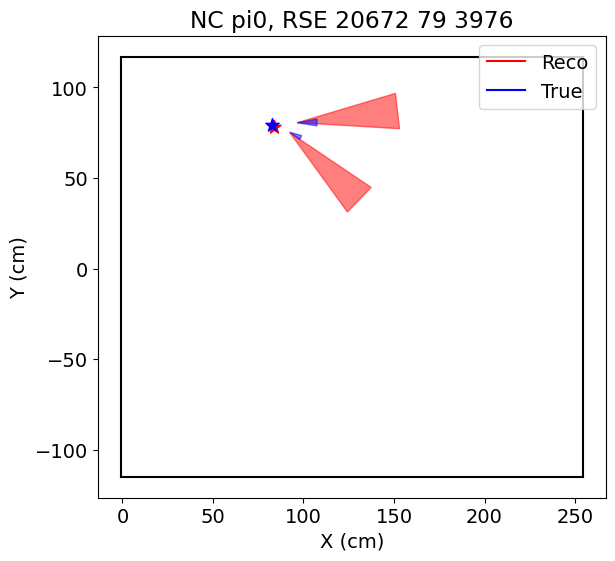

mother of mother: [111]
mother of mother: [111]


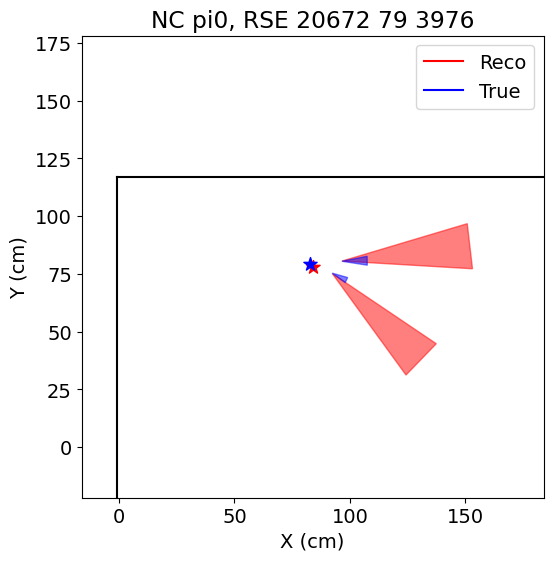

In [ ]:
# much simpler event displays

from particle import Particle

def show_simplified_event_display(df, event_idx, view="zy", index=0, zoomed=False):

    event_df = df.iloc[event_idx]
    
    run = event_df["run"]
    subrun = event_df["subrun"]
    event = event_df["event"]
    
    reco_pdg = event_df["reco_pdg"]  # truth particle pdg codes
    reco_mother = event_df["reco_mother"]  # truth particle mother pdg codes

    reco_ids = event_df["reco_id"]
    reco_pdgs = event_df["reco_pdg"]
    reco_start_XYZTs = event_df["reco_startXYZT"]
    reco_end_XYZTs = event_df["reco_endXYZT"]

    truth_ids = event_df["truth_id"]
    truth_pdgs = event_df["truth_pdg"]
    truth_start_XYZTs = event_df["truth_startXYZT"]
    truth_end_XYZTs = event_df["truth_endXYZT"]
    truth_mother = event_df["truth_mother"]

    tpc_min_x = -1.
    tpc_max_x = 254.3
    tpc_min_y = -115.
    tpc_max_y = 117.
    tpc_min_z = 0.6
    tpc_max_z = 1036.4

    plt.rcParams.update({'font.size': 14})

    plt.figure(figsize=(14, 6))
    if view == "zy":
        plt.plot([tpc_min_z, tpc_max_z], [tpc_min_y, tpc_min_y], c="k")
        plt.plot([tpc_min_z, tpc_max_z], [tpc_max_y, tpc_max_y], c="k")
        plt.plot([tpc_min_z, tpc_min_z], [tpc_min_y, tpc_max_y], c="k")
        plt.plot([tpc_max_z, tpc_max_z], [tpc_min_y, tpc_max_y], c="k")
    elif view =="zx":
        plt.plot([tpc_min_z, tpc_max_z], [tpc_min_x, tpc_min_x], c="k")
        plt.plot([tpc_min_z, tpc_max_z], [tpc_max_x, tpc_max_x], c="k")
        plt.plot([tpc_min_z, tpc_min_z], [tpc_min_x, tpc_max_x], c="k")
        plt.plot([tpc_max_z, tpc_max_z], [tpc_min_x, tpc_max_x], c="k")
    elif view == "xy":
        plt.plot([tpc_min_x, tpc_max_x], [tpc_min_y, tpc_min_y], c="k")
        plt.plot([tpc_min_x, tpc_max_x], [tpc_max_y, tpc_max_y], c="k")
        plt.plot([tpc_min_x, tpc_min_x], [tpc_min_y, tpc_max_y], c="k")
        plt.plot([tpc_max_x, tpc_max_x], [tpc_min_y, tpc_max_y], c="k")
    plt.plot([], [], c="r", label="Reco")
    plt.plot([], [], c="b", label="True")
    for j in range(len(reco_pdgs)):
        start_x, start_y, start_z, start_t = reco_start_XYZTs[j]
        end_x, end_y, end_z, end_t = reco_end_XYZTs[j]
        if view == "zy":
            start = np.array([start_z, start_y])
            end = np.array([end_z, end_y])
        elif view == "zx":
            start = np.array([start_z, start_x])
            end = np.array([end_z, end_x])
        elif view == "xy":
            start = np.array([start_x, start_y])
            end = np.array([end_x, end_y])
        pdg = reco_pdgs[j]
        mother_index = np.where(reco_ids == reco_mother[j])[0]
        if mother_index.size == 0:
            continue  # Skip if no mother found
        mother2_index = np.where(reco_ids == reco_mother[mother_index])[0]
        mother2_pdg = reco_pdg[mother2_index]
        if mother2_pdg == 111:
        #elif pdg == 11: # shower, plot cone
        #elif pdg == 22:
        #elif pdg == -11:
            print(f'mother of mother: {mother2_pdg}')
            direction = end - start
            length = np.linalg.norm(direction)
            unit_direction = direction / length
            perp = np.array([-unit_direction[1], unit_direction[0]])
            angle_rad = np.radians(20 / 2)
            side_length = length * np.tan(angle_rad)
            side1 = end - side_length * perp
            side2 = end + side_length * perp
            triangle = np.array([start, side1, end, side2])
            plt.fill(triangle[:, 0], triangle[:, 1], color="r", alpha=0.5)
        #else: # track, plot line
            #plt.plot([start[0], end[0]], [start[1], end[1]], c="r")

    for j in range(len(truth_pdgs)):
        start_x, start_y, start_z, start_t = truth_start_XYZTs[j]
        end_x, end_y, end_z, end_t = truth_end_XYZTs[j]
        start_x = np.clip(start_x, tpc_min_x, tpc_max_x)
        start_y = np.clip(start_y, tpc_min_y, tpc_max_y)
        start_z = np.clip(start_z, tpc_min_z, tpc_max_z)
        end_x = np.clip(end_x, tpc_min_x, tpc_max_x)
        end_y = np.clip(end_y, tpc_min_y, tpc_max_y)
        end_z = np.clip(end_z, tpc_min_z, tpc_max_z)
        if view == "zy":
            start = np.array([start_z, start_y])
            end = np.array([end_z, end_y])
        elif view == "zx":
            start = np.array([start_z, start_x])
            end = np.array([end_z, end_x])
        elif view == "xy":
            start = np.array([start_x, start_y])
            end = np.array([end_x, end_y])
        pdg = truth_pdgs[j]
        if pdg == 11: # shower, plot cone
        #elif pdg == 22:
        #elif pdg == -11:
            mother_index = np.where(truth_ids == truth_mother[j])[0]
            #print(mother_index)
            if mother_index.size == 0:
                continue  # Skip if no mother found
            mother2_index = np.where(truth_ids == truth_mother[mother_index])[0]
            if mother2_index.size == 0:
                continue
            if mother2_index.size > 0:
                mother2_pdg = truth_pdgs[mother2_index]
            if np.any(mother2_pdg == 111):
                direction = end - start
                length = np.linalg.norm(direction)
                unit_direction = direction / length
                perp = np.array([-unit_direction[1], unit_direction[0]])
                angle_rad = np.radians(20 / 2)
                side_length = length * np.tan(angle_rad)
                side1 = end - side_length * perp
                side2 = end + side_length * perp
                triangle = np.array([start, side1, end, side2])
                #print(truth_mother[index][j])
                pdg_index = np.where(truth_ids == truth_mother[j])
                mother_of_mother = np.where(truth_ids == truth_mother[pdg_index])
                #print(pdg_index)
                #print(truth_pdg[index][pdg_index])
                #print(f'mother of mother: {truth_pdg[index][mother_of_mother]}')
                plt.fill(triangle[:, 0], triangle[:, 1], color="b", alpha=0.5)
        #else: # track, plot line
            #plt.plot([start[0], end[0]], [start[1], end[1]], c="b")

    if view == "zy":
        plt.scatter(event_df["reco_nuvtxZ"], event_df["reco_nuvtxY"], color="r", marker="*", s=100)
        #plt.scatter(160, 55, color="r", marker="*", s=200)
        plt.scatter(event_df["truth_vtxZ"], event_df["truth_vtxY"], color="b", marker="*", s=100)# shower vertex location
        #plt.scatter(one_event_df["reco_showervtxZ"].to_numpy()[index], one_event_df["reco_showervtxY"].to_numpy()[index], color="r", marker="P", s=100)
        #plt.scatter(one_event_df["truth_corr_showervtxZ"].to_numpy()[index], one_event_df["truth_corr_showervtxY"].to_numpy()[index], color="b", marker="P", s=100)
  
    elif view == "zx":
        plt.scatter(event_df["reco_nuvtxZ"], event_df["reco_nuvtxX"], color="r", marker="*", s=100)
        plt.scatter(event_df["truth_vtxZ"], event_df["truth_vtxX"], color="b", marker="*", s=100)
    elif view == "xy":
        plt.scatter(event_df["reco_nuvtxX"], event_df["reco_nuvtxY"], color="r", marker="*", s=100)
        plt.scatter(event_df["truth_vtxX"], event_df["truth_vtxY"], color="b", marker="*", s=100)
    plt.title(f"NC pi0, RSE {run} {subrun} {event}")
    plt.legend(loc="upper right")
    if view == "zy":
        plt.xlabel("Z (cm)")
        plt.ylabel("Y (cm)")
    elif view == "zx":
        plt.xlabel("Z (cm)")
        plt.ylabel("X (cm)")
    elif view == "xy":
        plt.xlabel("X (cm)")
        plt.ylabel("Y (cm)")
    if zoomed and view == "zy":
        plt.xlim(event_df["reco_nuvtxZ"]-100, event_df["reco_nuvtxZ"]+100)
        plt.ylim(event_df["reco_nuvtxY"]-100, event_df["reco_nuvtxY"]+100)
    elif zoomed and view == "zx":
        plt.xlim(event_df["reco_nuvtxZ"]-100, event_df["reco_nuvtxZ"]+100)
        plt.ylim(event_df["reco_nuvtxX"]-100, event_df["reco_nuvtxX"]+100)
    elif zoomed and view == "xy":
        plt.xlim(event_df["reco_nuvtxX"]-100, event_df["reco_nuvtxX"]+100)
        plt.ylim(event_df["reco_nuvtxY"]-100, event_df["reco_nuvtxY"]+100)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

def go(i):
    show_simplified_event_display(pi0_df, i,  view="zy", index=i, zoomed=False)
    show_simplified_event_display(pi0_df, i, view="zy", index=i, zoomed=True)
    show_simplified_event_display(pi0_df, i,  view="zx", index=i, zoomed=False)
    show_simplified_event_display(pi0_df, i, view="zx", index=i, zoomed=True)

    show_simplified_event_display(pi0_df, i, view="xy", index=i, zoomed=False)
    show_simplified_event_display(pi0_df, i, view="xy", index=i, zoomed=True)

go(20)

# BDT variables histograms

(2013, 138)
(25451, 138)


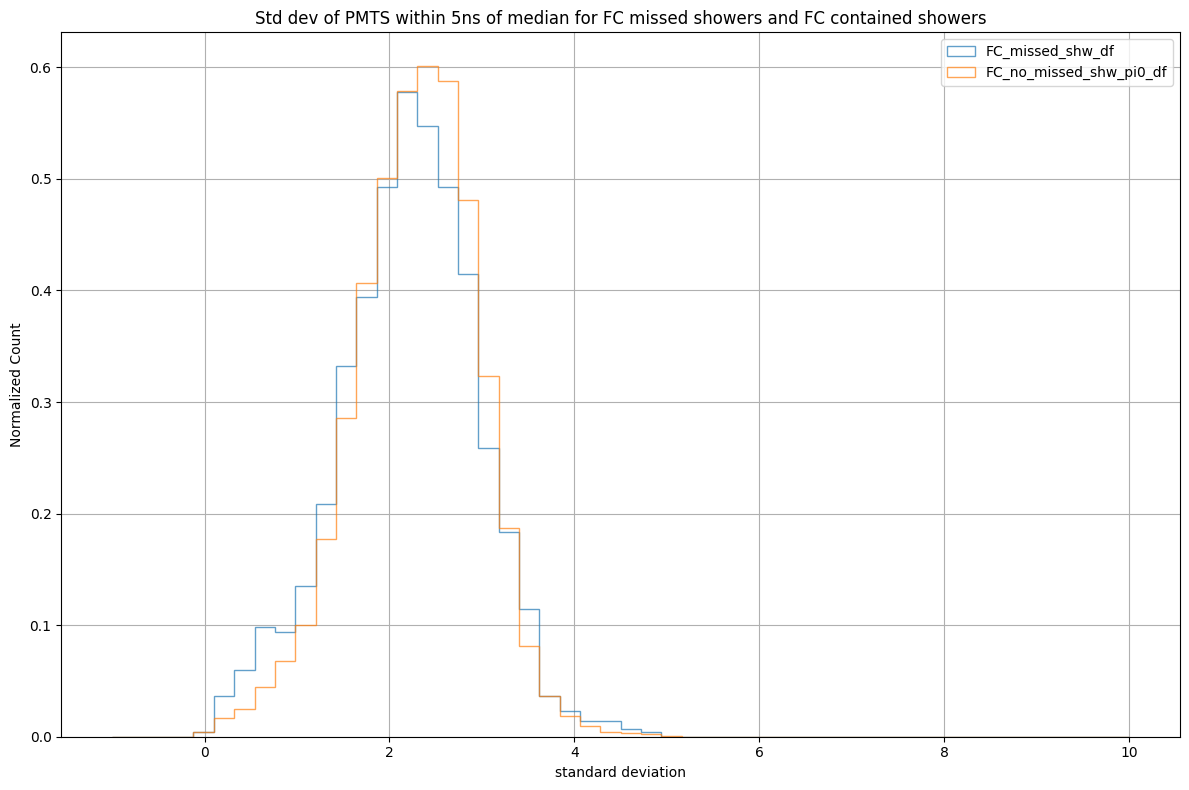

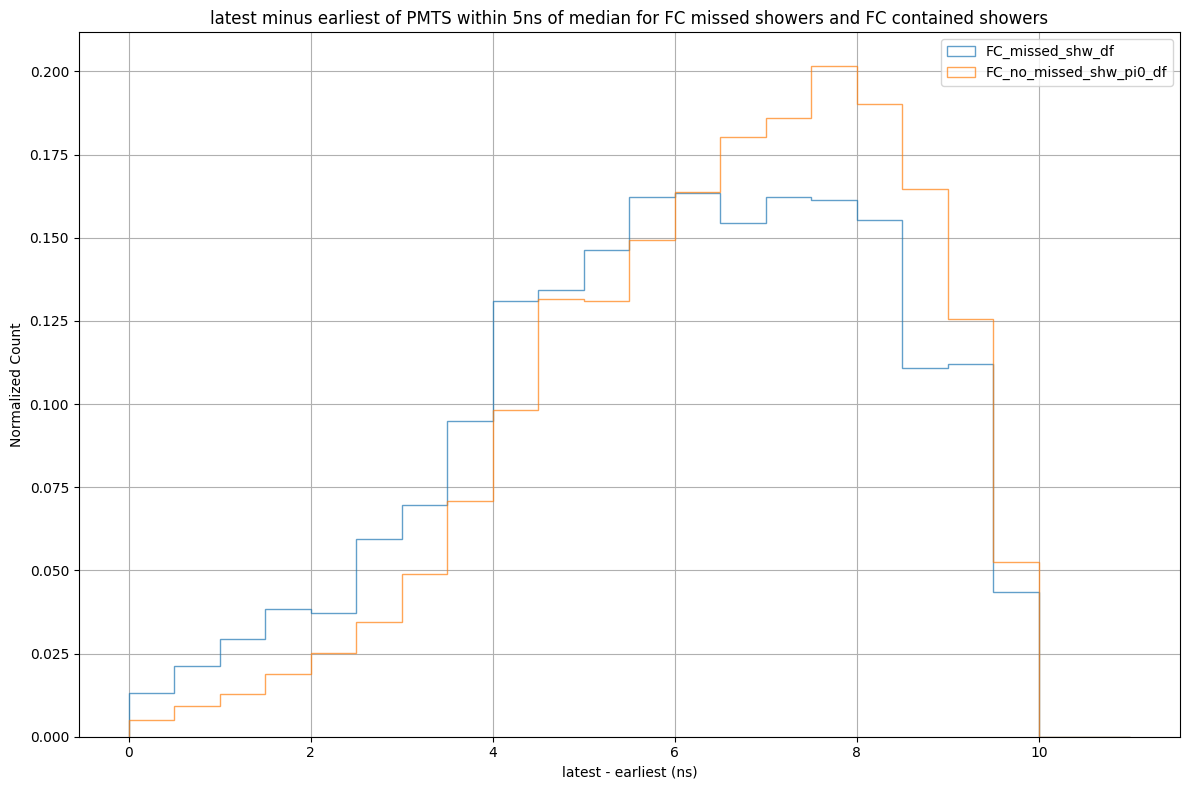

In [ ]:
# ns timing 1d histograms

print(all_df.query("FC_missedshw and pi0_flag").shape)
print(all_df.query("no_missed_shw_pi0 and match_isFC").shape)

FC_missed_shw_df = all_df.query("FC_missedshw")
FC_no_missed_shw_pi0_df = all_df.query('no_missed_shw_pi0 and match_isFC')

#print(no_missed_shw_pi0_df.shape)

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df['pmts_within_ns_std_dev'], bins=50, alpha=0.7, range=(-1, 10), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df["pmts_within_ns_std_dev"], bins=50, range=(-1, 10), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('standard deviation')
plt.ylabel('Normalized Count')
plt.title('Std dev of PMTS within 5ns of median for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df['pmt_latest_minus_earliest'], bins=22, alpha=0.7, range=(0, 11), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df["pmt_latest_minus_earliest"], bins=22, range=(0, 11), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('latest - earliest (ns)')
plt.ylabel('Normalized Count')
plt.title('latest minus earliest of PMTS within 5ns of median for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

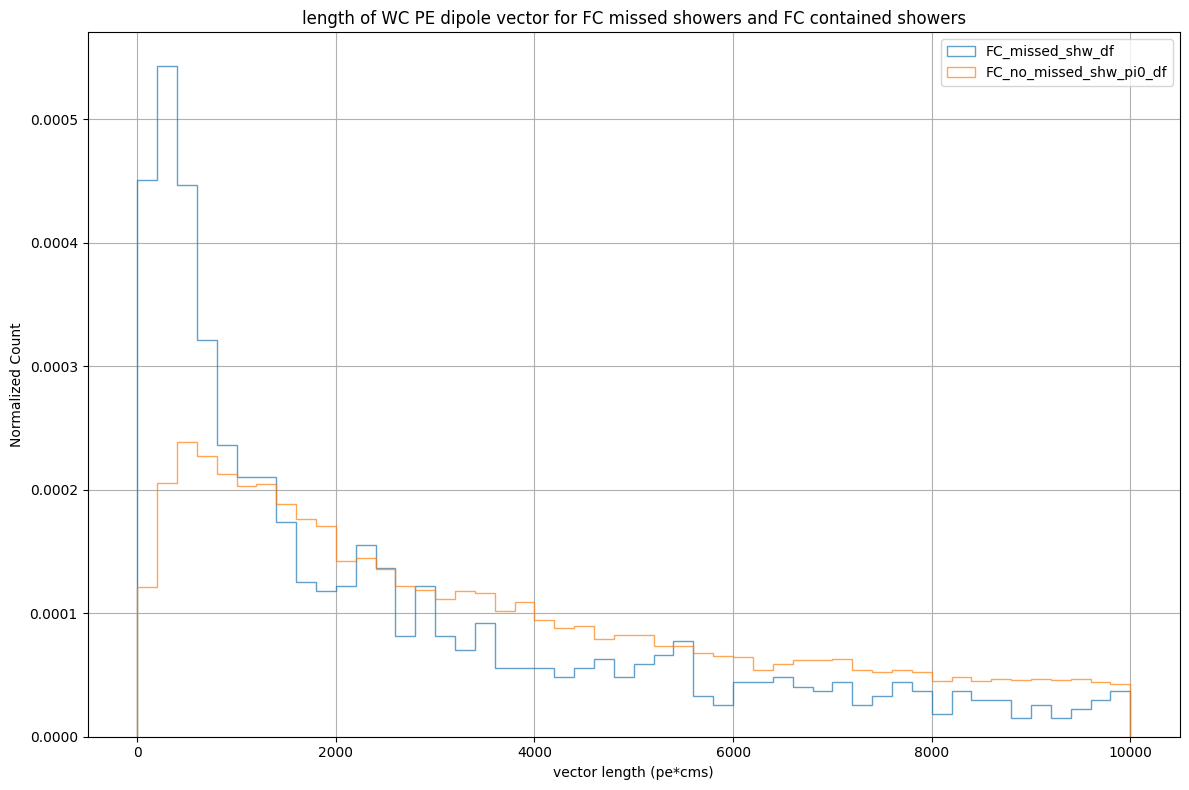

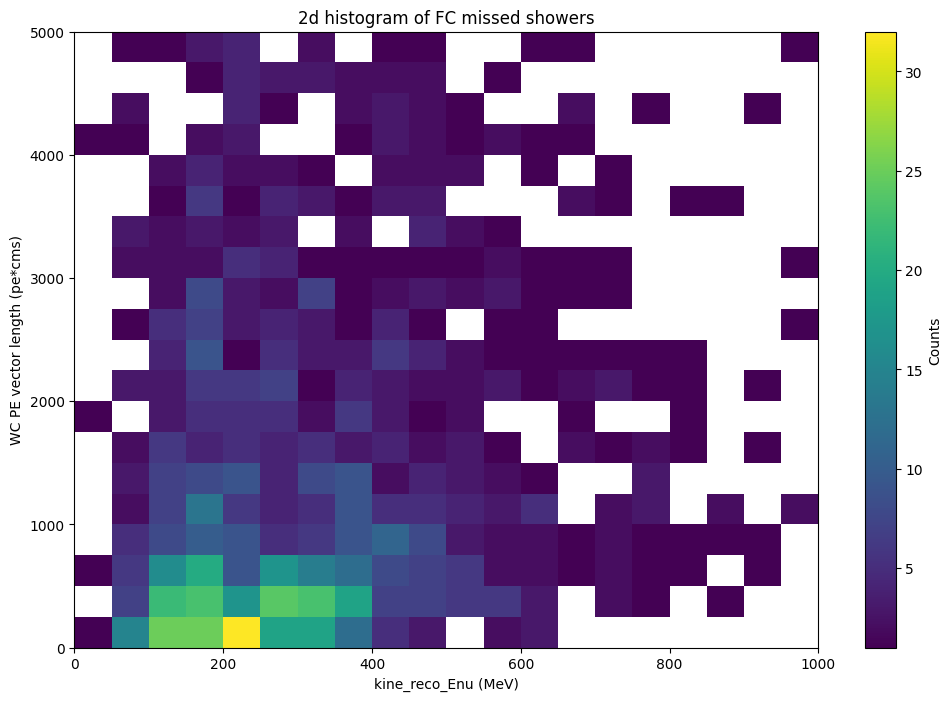

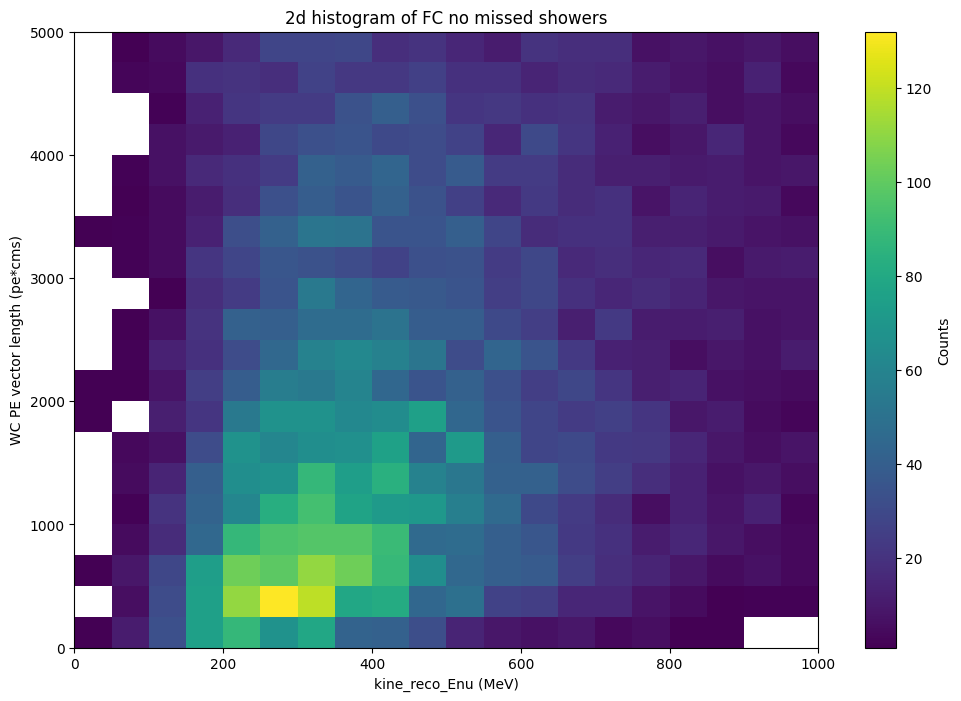

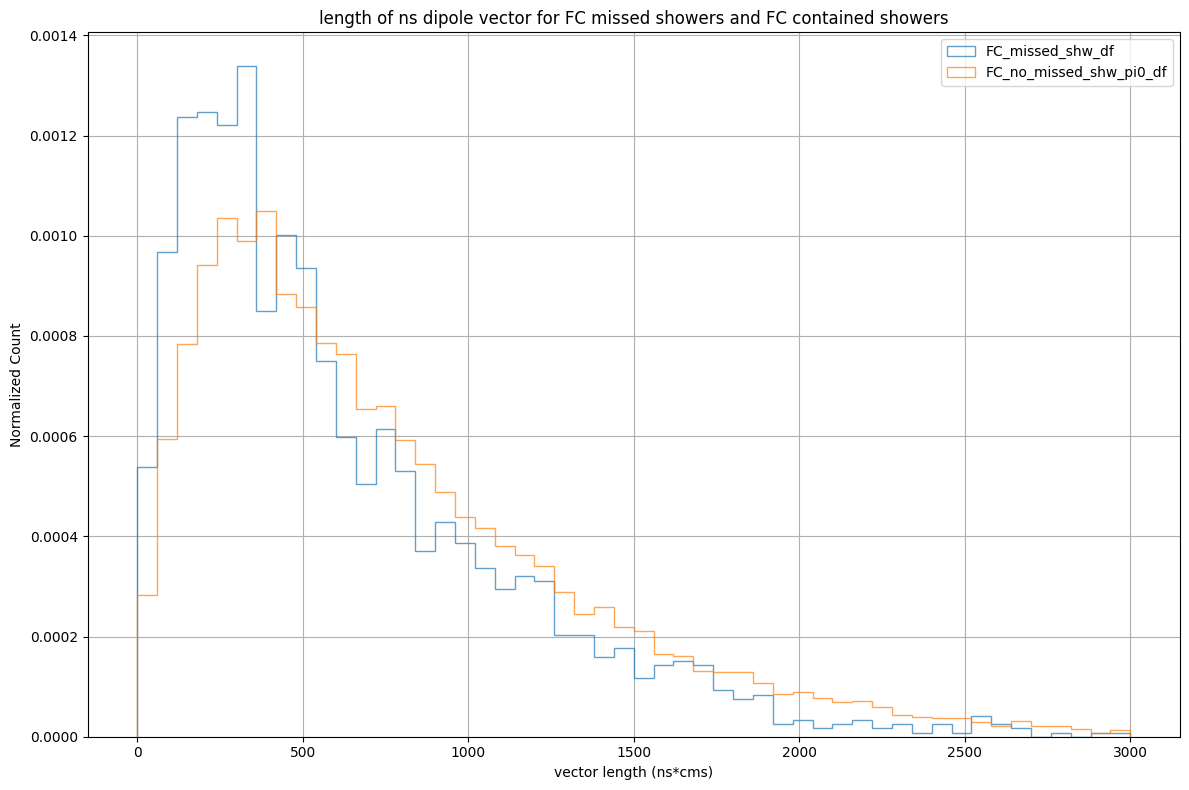

In [ ]:
# WC vector histograms

FC_missed_shw_df_pmt = all_df.query("FC_missedshw and pmt_ns_vector_length > 0")
FC_no_missed_shw_pi0_df_pmt = all_df.query('no_missed_shw_pi0 and match_isFC and pmt_ns_vector_length > 0')
pmt_df = all_df.query('pmt_ns_vector_length > 0 and pi0_flag')

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['wc_pmt_pe_vector_length'], bins=50, alpha=0.7, range=(0, 10000), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["wc_pmt_pe_vector_length"], bins=50, range=(0, 10000), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('vector length (pe*cms)')
plt.ylabel('Normalized Count')
plt.title('length of WC PE dipole vector for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# redo above FC_missed_shw_df as a 2d histogram with kine_reco_Enu
plt.figure(figsize=(12, 8))
plt.hist2d(FC_missed_shw_df_pmt['kine_reco_Enu'], FC_missed_shw_df_pmt['wc_pmt_pe_vector_length'], bins=(20, 20), range=((0, 1000), (0, 5000)), cmap='viridis', cmin=1)
plt.colorbar(label='Counts')
plt.xlabel('kine_reco_Enu (MeV)')
plt.ylabel('WC PE vector length (pe*cms)') 

plt.title('2d histogram of FC missed showers')
plt.show()

plt.figure(figsize=(12, 8))
plt.hist2d(FC_no_missed_shw_pi0_df_pmt['kine_reco_Enu'], FC_no_missed_shw_pi0_df_pmt['wc_pmt_pe_vector_length'], bins=(20, 20), range=((0, 1000), (0, 5000)), cmap='viridis', cmin=1)
plt.colorbar(label='Counts')
plt.xlabel('kine_reco_Enu (MeV)')
plt.ylabel('WC PE vector length (pe*cms)') 

plt.title('2d histogram of FC no missed showers')
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['pmt_ns_vector_length'], bins=50, alpha=0.7, range=(0, 3000), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["pmt_ns_vector_length"], bins=50, range=(0, 3000), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('vector length (ns*cms)')
plt.ylabel('Normalized Count')
plt.title('length of ns dipole vector for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

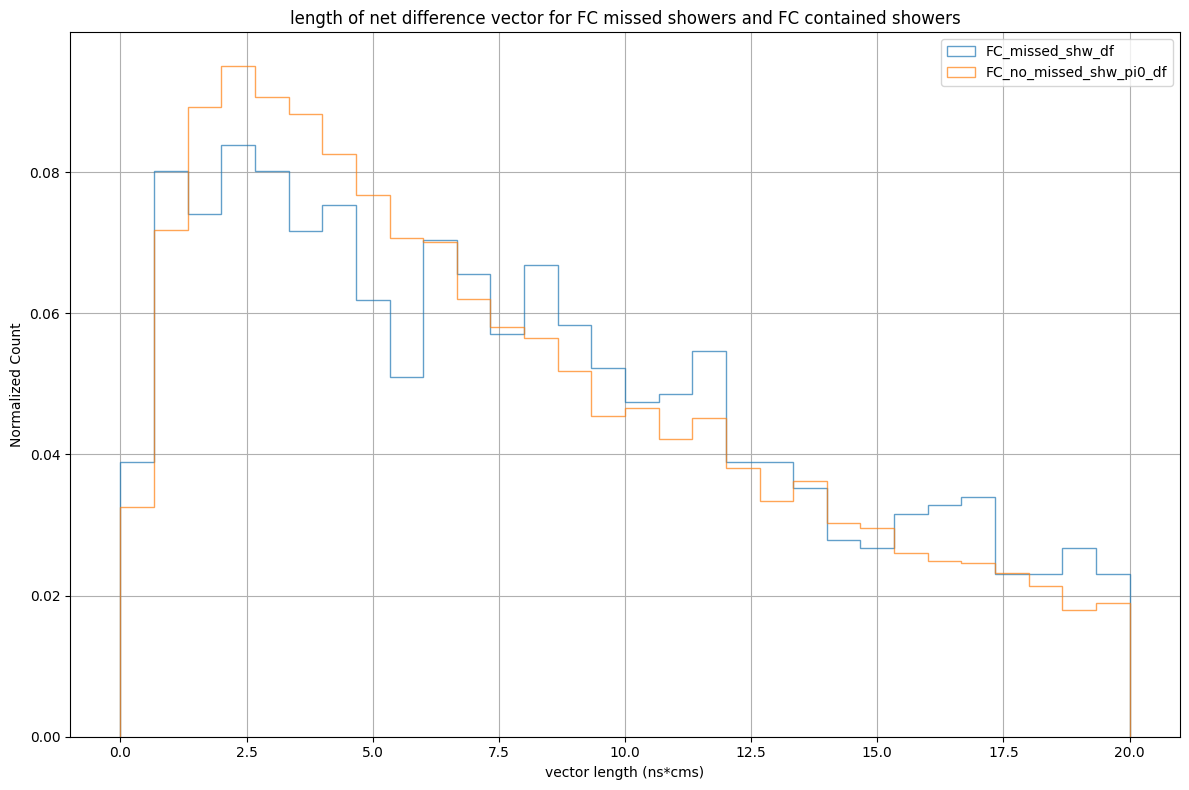

In [ ]:
# net difference vector 1d hist

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['net_diff_vector_length'], bins=30, alpha=0.7, range=(0, 20), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["net_diff_vector_length"], bins=30, range=(0, 20), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('vector length (ns*cms)')
plt.ylabel('Normalized Count')
plt.title('length of net difference vector for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

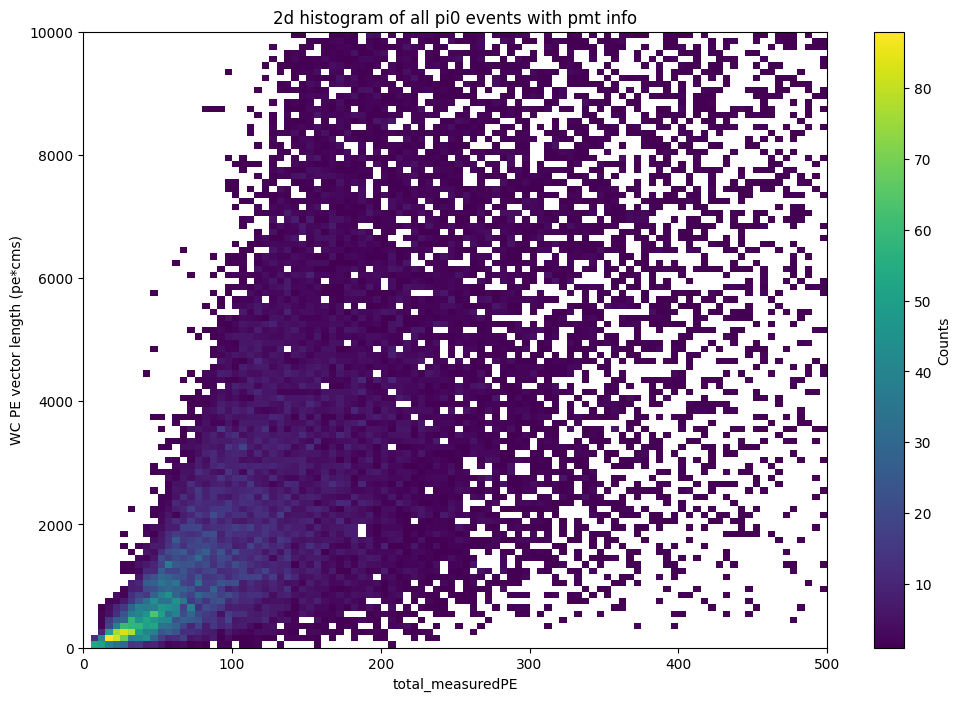

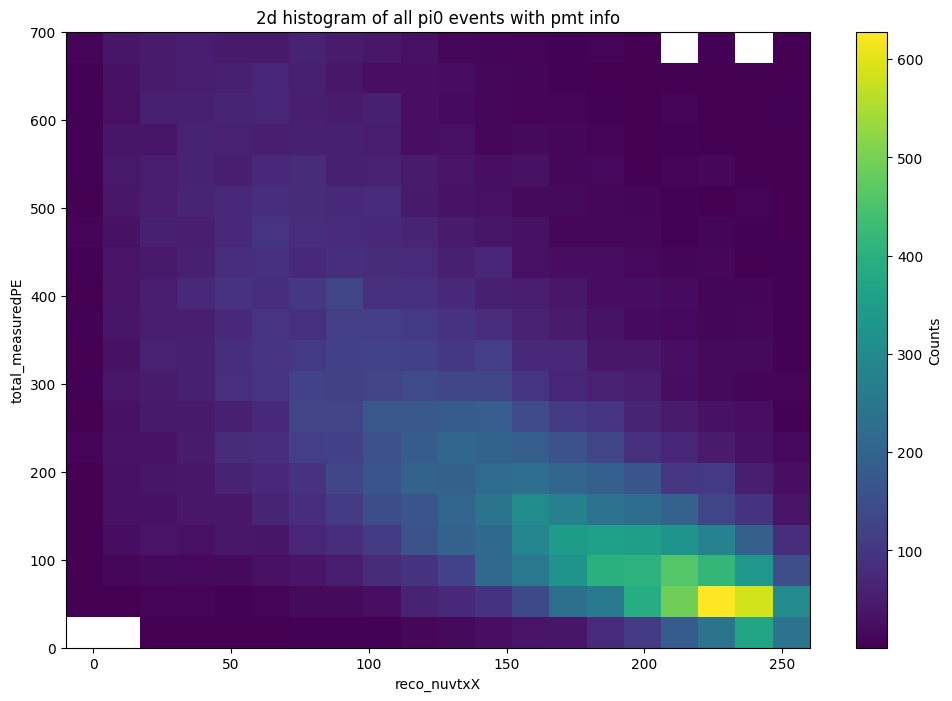

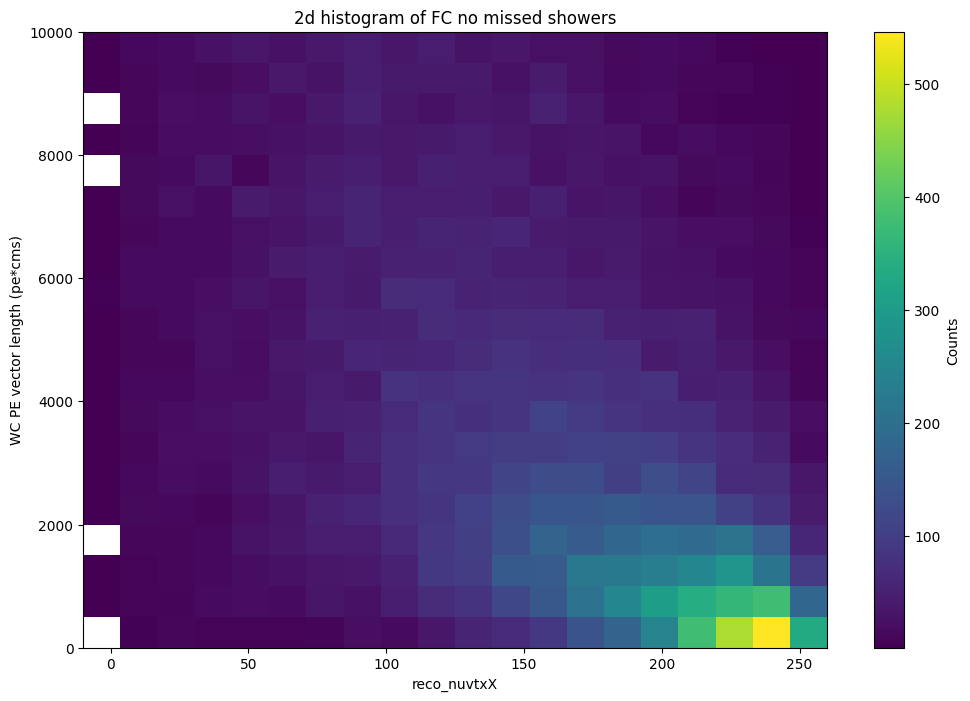

In [ ]:
# reco vertex x histograms

import matplotlib.colors as colors

plt.figure(figsize=(12, 8))
plt.hist2d(pmt_df['total_measuredPE'], pmt_df['wc_pmt_pe_vector_length'], bins=(100, 100), range=((0, 500), (0, 10000)), cmap='viridis', cmin=1)
plt.colorbar(label='Counts')
plt.xlabel('total_measuredPE')
plt.ylabel('WC PE vector length (pe*cms)') 

plt.title('2d histogram of all pi0 events with pmt info')
plt.show()

plt.figure(figsize=(12, 8))
plt.hist2d(pmt_df['reco_nuvtxX'], pmt_df['total_measuredPE'], bins=(20, 20), range=((-10, 260), (0, 700)), cmap='viridis', cmin=1)
plt.colorbar(label='Counts')
plt.xlabel('reco_nuvtxX')
plt.ylabel('total_measuredPE') 

plt.title('2d histogram of all pi0 events with pmt info')
plt.show()



plt.figure(figsize=(12, 8))
plt.hist2d(pmt_df['reco_nuvtxX'], pmt_df['pmt_pe_3dvector_length'], bins=(20, 20), range=((-10, 260), (0, 10000)), cmap='viridis', cmin=1)
plt.colorbar(label='Counts')
plt.xlabel('reco_nuvtxX')
plt.ylabel('WC PE vector length (pe*cms)') 

plt.title('2d histogram of FC no missed showers')
plt.show()